# 11 - Feature Selection, Error Case Review, and Ablation Study

## Objective

Notebook này dùng để chuẩn bị bộ feature đáng tin cậy trước khi tuning model chính hiện tại: **LightGBM train trực tiếp trên `target_price`**. Trọng tâm không phải tìm metric đẹp ngay, mà là xác định:

| Area | Key Question |
|---|---|
| Error case review | Các prediction bất thường là lỗi dữ liệu, thiếu feature, hay model chưa học được pattern? |
| Feature audit | Có leakage, cột nhiễu, cột trùng lặp, high-missing hoặc high-cardinality không? |
| Primary baseline | Đánh giá `LightGBM + target_price` trên cùng split để mọi ablation so sánh công bằng. |
| Baseline clean retraining | Sau khi loại cột xấu, baseline có ổn hơn không? |
| Feature importance | Feature nào ảnh hưởng nhiều đến global error và segment error? |
| Group ablation | Nhóm CPU/RAM/GPU/Storage/Screen/Brand/Text có đóng góp thật không? |
| Segment-aware strategy | Có cần sample weighting hoặc xử lý riêng Low/Premium không? |

> Notebook này nên chạy sau `10_model_diagnostics_and_error_analysis.ipynb` và trước notebook tuning.


## 1. Imports and Configuration

In [1]:
from __future__ import annotations

import json
import pickle
import re
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.inspection import permutation_importance

CURRENT_DIR = Path.cwd().resolve()

# Expected case: running notebook from notebooks/modeling/
if CURRENT_DIR.name == "modeling" and CURRENT_DIR.parent.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent.parent

# Case: running from notebooks/
elif CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent

# Case: running from project root
elif (CURRENT_DIR / "src").exists():
    PROJECT_ROOT = CURRENT_DIR

# Fallback: search upward for src/
else:
    PROJECT_ROOT = None

    for path in [CURRENT_DIR] + list(CURRENT_DIR.parents):
        if (path / "src").exists():
            PROJECT_ROOT = path
            break

    if PROJECT_ROOT is None:
        raise FileNotFoundError(
            "Could not find project root containing src/ folder. "
            f"Current directory: {CURRENT_DIR}"
        )

SRC_DIR = PROJECT_ROOT / "src"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("CURRENT_DIR:", CURRENT_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_DIR exists:", SRC_DIR.exists())

# Optional but recommended: make src a package
if SRC_DIR.exists():
    init_file = SRC_DIR / "__init__.py"
    init_file.touch(exist_ok=True)
    print("__init__.py exists:", init_file.exists())

try:
    from src.models.light_gbm import (
        build_lightgbm_model as build_lgbm_model,
        make_train_test_data,
        train_lightgbm_model as train_lgbm_model,
        inverse_prediction_to_price,
        compute_regression_metrics,
        compute_segment_metrics,
        build_prediction_frame,
        plot_true_vs_predicted,
        run_lightgbm_experiment as run_lgbm_experiment,
    )

    print("Imported LightGBM utilities from src.models.light_gbm successfully.")

except ModuleNotFoundError as e:
    print("\nFailed to import from src.models.light_gbm.")
    print("Available .py files in src/:")

    if SRC_DIR.exists():
        for p in sorted(SRC_DIR.glob("*.py")):
            print("-", p.name)

    raise e

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

try:
    import joblib
    HAS_JOBLIB = True
except ImportError:
    HAS_JOBLIB = False

# ------------------------------------------------------------
# 4. Display and warning config
# ------------------------------------------------------------

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42

PRICE_SEGMENT_ORDER = ["Low", "Mid", "High", "Premium"]

TARGET_PRICE_COL = "target_price"
TARGET_LOG_PRICE_COL = "log_target_price"
SEGMENT_COL = "price_segment"

TARGET_COLUMNS = [TARGET_PRICE_COL, TARGET_LOG_PRICE_COL]

# Main training target: raw price
PRIMARY_TARGET = TARGET_PRICE_COL
PRIMARY_MODEL_NAME = "LightGBM"

TARGET_CONFIGS = [
    {
        "name": TARGET_PRICE_COL,
        "primary_use": "Raw-price regression; predictions are already on price scale.",
        "inverse_transform": None,
    }
]

DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

DATA_PATH = DATA_DIR / "processed" / "laptop_processed_numeric.csv"

print("\nConfig ready.")
print("PRIMARY_TARGET:", PRIMARY_TARGET)
print("DATA_PATH:", DATA_PATH)
print("DATA_PATH exists:", DATA_PATH.exists())
print("HAS_JOBLIB:", HAS_JOBLIB)


CURRENT_DIR: Y:\Python\Laptop-Price-Prediction\notebooks\modeling
PROJECT_ROOT: Y:\Python\Laptop-Price-Prediction
SRC_DIR exists: True
__init__.py exists: True
Imported LightGBM utilities from src.models.light_gbm successfully.

Config ready.
PRIMARY_TARGET: target_price
DATA_PATH: Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_numeric.csv
DATA_PATH exists: True
HAS_JOBLIB: True


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    """Find project root by looking for data/ and artifacts/ folders.
    Works whether this notebook is run from project root or notebooks/... subfolder.
    """
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for p in candidates:
        if (p / "data").exists() and (p / "artifacts").exists():
            return p
    # fallback used by previous notebook when cwd is notebooks/<subfolder>
    if len(start.parents) >= 2:
        return start.parents[1]
    return start

PROJECT_ROOT = find_project_root()

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "laptop_processed_numeric.csv"
RAW_DATA_CANDIDATES = [
    PROJECT_ROOT / "data" / "processed" / "laptop_processed.csv",
    PROJECT_ROOT / "data" / "processed" / "laptop_cleaned.csv",
    PROJECT_ROOT / "data" / "raw" / "chotot_laptop_data.csv",
]

ARTIFACT_DIR     = PROJECT_ROOT / "artifacts" / "modeling_numeric"
METRICS_DIR      = ARTIFACT_DIR / "metrics"
PREDICTIONS_DIR  = ARTIFACT_DIR / "predictions"
DIAGNOSTICS_DIR  = ARTIFACT_DIR / "model_diagnostics"
FEATURE_SEL_DIR  = ARTIFACT_DIR / "feature_selection"
MODEL_DIRS       = [ARTIFACT_DIR / "models", ARTIFACT_DIR / "trained_models", ARTIFACT_DIR]

FEATURE_SEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT   : {PROJECT_ROOT}")
print(f"DATA_PATH      : {DATA_PATH}")
print(f"ARTIFACT_DIR   : {ARTIFACT_DIR}")
print(f"FEATURE_SEL_DIR: {FEATURE_SEL_DIR}")

# ── Report artifact mirroring ─────────────────────────────────────────────────
# Keep the original artifact paths for downstream notebooks, and mirror every
# generated table/figure into reports/tables and reports/figures for the report.
NOTEBOOK_SLUG = "11_feature_selection_and_ablation"
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_FIGURES_DIR = REPORT_DIR / "figures" / NOTEBOOK_SLUG
REPORT_TABLES_DIR = REPORT_DIR / "tables" / NOTEBOOK_SLUG
for directory in [REPORT_FIGURES_DIR, REPORT_TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


def _report_relative_path(path):
    path = Path(path)
    try:
        path = path.resolve()
    except OSError:
        path = path.absolute()
    for base in [PROJECT_ROOT / "artifacts", PROJECT_ROOT / "reports", PROJECT_ROOT]:
        try:
            return path.relative_to(base.resolve())
        except ValueError:
            continue
    return Path(path.name)


def _mirror_report_artifact(path, destination_root):
    if path is None or destination_root is None or not isinstance(path, (str, Path)):
        return
    src = Path(path)
    if not src.exists() or not src.is_file():
        return
    rel = _report_relative_path(src)
    dst = destination_root / rel
    try:
        if src.resolve() == dst.resolve():
            return
    except OSError:
        pass
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)


import shutil
from matplotlib.figure import Figure

if not hasattr(pd.DataFrame, "_reports_original_to_csv"):
    pd.DataFrame._reports_original_to_csv = pd.DataFrame.to_csv
if not hasattr(pd.Series, "_reports_original_to_csv"):
    pd.Series._reports_original_to_csv = pd.Series.to_csv
if not hasattr(pd.DataFrame, "_reports_original_to_excel"):
    pd.DataFrame._reports_original_to_excel = pd.DataFrame.to_excel
if not hasattr(Figure, "_reports_original_savefig"):
    Figure._reports_original_savefig = Figure.savefig


def _to_csv_with_report_mirror(self, path_or_buf=None, *args, **kwargs):
    result = pd.DataFrame._reports_original_to_csv(self, path_or_buf, *args, **kwargs)
    _mirror_report_artifact(path_or_buf, globals().get("REPORT_TABLES_DIR"))
    return result


def _series_to_csv_with_report_mirror(self, path_or_buf=None, *args, **kwargs):
    result = pd.Series._reports_original_to_csv(self, path_or_buf, *args, **kwargs)
    _mirror_report_artifact(path_or_buf, globals().get("REPORT_TABLES_DIR"))
    return result


def _to_excel_with_report_mirror(self, excel_writer, *args, **kwargs):
    result = pd.DataFrame._reports_original_to_excel(self, excel_writer, *args, **kwargs)
    _mirror_report_artifact(excel_writer, globals().get("REPORT_TABLES_DIR"))
    return result


def _savefig_with_report_mirror(self, fname, *args, **kwargs):
    result = Figure._reports_original_savefig(self, fname, *args, **kwargs)
    _mirror_report_artifact(fname, globals().get("REPORT_FIGURES_DIR"))
    return result


_to_csv_with_report_mirror._reports_mirror_patch = True
_series_to_csv_with_report_mirror._reports_mirror_patch = True
_to_excel_with_report_mirror._reports_mirror_patch = True
_savefig_with_report_mirror._reports_mirror_patch = True
pd.DataFrame.to_csv = _to_csv_with_report_mirror
pd.Series.to_csv = _series_to_csv_with_report_mirror
pd.DataFrame.to_excel = _to_excel_with_report_mirror
Figure.savefig = _savefig_with_report_mirror

print(f"Report figures mirrored to: {REPORT_FIGURES_DIR}")
print(f"Report tables mirrored to : {REPORT_TABLES_DIR}")


PROJECT_ROOT   : Y:\Python\Laptop-Price-Prediction
DATA_PATH      : Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_numeric.csv
ARTIFACT_DIR   : Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric
FEATURE_SEL_DIR: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\feature_selection
Report figures mirrored to: Y:\Python\Laptop-Price-Prediction\reports\figures\11_feature_selection_and_ablation
Report tables mirrored to : Y:\Python\Laptop-Price-Prediction\reports\tables\11_feature_selection_and_ablation


## 2. Utility Functions

In [3]:
def read_first_existing_csv(candidates, required_any_columns=None, label="CSV"):
    """Read the first existing CSV candidate. Optionally require at least one matching column."""
    for p in candidates:
        p = Path(p)
        if not p.exists():
            continue
        try:
            df = pd.read_csv(p)
            if required_any_columns is not None:
                has_any = any(c in df.columns for c in required_any_columns)
                if not has_any:
                    continue
            print(f"Loaded {label}: {p.name}  shape={df.shape}")
            return df, p
        except Exception as e:
            print(f"Skip {p}: {e}")
    return None, None


def load_pickle_or_joblib(path: Path):
    """Load .pkl/.pickle/.joblib files if available."""
    path = Path(path)
    if not path.exists():
        return None
    if HAS_JOBLIB and path.suffix.lower() in [".joblib", ".pkl", ".pickle"]:
        try:
            return joblib.load(path)
        except Exception:
            pass
    with open(path, "rb") as f:
        return pickle.load(f)


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip().lower().replace(" ", "_").replace("-", "_") for c in df.columns]
    return df


def assign_price_segment_by_quantile(y, q25=None, q50=None, q75=None):
    y = pd.Series(y).astype(float)
    if q25 is None or q50 is None or q75 is None:
        q25, q50, q75 = np.quantile(y.dropna(), [0.25, 0.50, 0.75])
    seg = pd.cut(
        y,
        bins=[-np.inf, q25, q50, q75, np.inf],
        labels=PRICE_SEGMENT_ORDER,
        include_lowest=True,
    )
    return pd.Categorical(seg, categories=PRICE_SEGMENT_ORDER, ordered=True), (q25, q50, q75)


def compute_error_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    residual = actual - predicted
    ape = np.abs(residual) / (actual + 1e-9)
    return {
        "n": len(actual),
        "mae": mean_absolute_error(actual, predicted),
        "rmse": root_mean_squared_error(actual, predicted),
        "mape": mean_absolute_percentage_error(actual, predicted),
        "median_absolute_error": median_absolute_error(actual, predicted),
        "mean_residual": residual.mean(),
        "median_residual": np.median(residual),
        "underprediction_rate": (residual > 0).mean(),
        "overprediction_rate": (residual < 0).mean(),
        "severe_error_rate": (ape > 0.50).mean(),
        "extreme_error_rate": (ape > 1.00).mean(),
        "r2": r2_score(actual, predicted),
    }

def target_prediction_to_price(pred_target, target_name: str):
    """Convert model output back to original price scale for business metrics."""
    pred_target = np.asarray(pred_target, dtype=float)
    if target_name == "log_target_price":
        return np.expm1(pred_target)
    if target_name == "target_price":
        return pred_target
    raise ValueError(f"Unknown target_name={target_name}")


def get_target_config(target_name: str) -> dict:
    for cfg in TARGET_CONFIGS:
        if cfg["name"] == target_name:
            return cfg
    raise ValueError(f"Unknown target_name={target_name}")


def evaluate_price_scale_by_segment(actual_price, pred_price, segment, target_name=None, model_name=None):
    """Return global + segment metrics on original price scale."""
    rows = []
    base = compute_error_metrics(actual_price, pred_price)
    base.update({"scope": "global", "segment": "All"})
    rows.append(base)

    segment = pd.Series(segment).astype(str).reset_index(drop=True)
    actual_price = pd.Series(actual_price).reset_index(drop=True)
    pred_price = pd.Series(pred_price).reset_index(drop=True)

    for seg in PRICE_SEGMENT_ORDER:
        mask = segment.eq(seg)
        if mask.sum() == 0:
            continue
        m = compute_error_metrics(actual_price[mask], pred_price[mask])
        m.update({"scope": "segment", "segment": seg})
        rows.append(m)

    out = pd.DataFrame(rows)
    if target_name is not None:
        out.insert(0, "target", target_name)
    if model_name is not None:
        out.insert(0, "model", model_name)
    return out


## 3. Discover Available Artifacts

Cell này chỉ liệt kê các file đang có để tránh load nhầm artifact.

In [4]:
print("=== Processed data ===")
for p in [DATA_PATH, *RAW_DATA_CANDIDATES]:
    print(f"{p.exists()}  {p}")

print("\n=== Metrics files ===")
for f in sorted(METRICS_DIR.glob("*.csv")):
    print(" ", f.name)

print("\n=== Prediction files ===")
for f in sorted(PREDICTIONS_DIR.glob("*.csv")):
    print(" ", f.name)

print("\n=== Diagnostic files ===")
for f in sorted(DIAGNOSTICS_DIR.glob("*.csv")):
    print(" ", f.name)

print("\n=== Possible model files ===")
for d in MODEL_DIRS:
    if d.exists():
        for f in sorted(list(d.glob("*.pkl")) + list(d.glob("*.pickle")) + list(d.glob("*.joblib"))):
            print(" ", f.relative_to(PROJECT_ROOT))


=== Processed data ===
True  Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_numeric.csv
False  Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed.csv
False  Y:\Python\Laptop-Price-Prediction\data\processed\laptop_cleaned.csv
True  Y:\Python\Laptop-Price-Prediction\data\raw\chotot_laptop_data.csv

=== Metrics files ===
  log_scale_model_metrics.csv
  model_metrics.csv

=== Prediction files ===
  test_predictions.csv

=== Diagnostic files ===
  CatBoost_log_vs_raw_compression.csv
  correction_experiment_CatBoost.csv
  correction_experiment_LightGBM.csv
  diagnostic_errors_long.csv
  diagnostic_model_error_summary.csv
  final_diagnostic_summary.csv
  heteroscedasticity_binned_error_summary.csv
  heteroscedasticity_correlation_tests.csv
  LightGBM_log_vs_raw_compression.csv
  lightgbm_target_price_numeric_error_cases.csv
  lightgbm_target_price_numeric_final_diagnostic_summary.csv
  lightgbm_target_price_numeric_top_absolute_error.csv
  lightgbm_target_pri

## 4. Load Processed Data, Metrics, Predictions, and Diagnostics

In [5]:
# Load processed numeric dataset
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Processed numeric dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f"Loaded processed numeric data: {df.shape}")
display(df.head())

# Tự sinh log_target_price nếu chưa có trong data
if "log_target_price" not in df.columns and "target_price" in df.columns:
    df["log_target_price"] = np.log1p(df["target_price"])
    print("[INFO] log_target_price derived from target_price via np.log1p")

missing_targets = [c for c in TARGET_COLUMNS if c not in df.columns]
if missing_targets:
    raise ValueError(f"Missing target columns in processed data: {missing_targets}")

feature_cols_all = [c for c in df.columns if c not in TARGET_COLUMNS]
numeric_feature_cols = df[feature_cols_all].select_dtypes(include=[np.number]).columns.tolist()

print(f"All feature columns    : {len(feature_cols_all)}")
print(f"Numeric feature columns: {len(numeric_feature_cols)}")

Loaded processed numeric data: (7296, 88)


,ram_gb,storage_gb,screen_size_inch,brand_is_rare,model_is_rare,ram_missing,storage_missing,screen_missing,target_price,log_target_price,no_info_brand,no_info_model,no_info_cpu_brand,no_info_cpu_tier,no_info_gpu,storage_ssd,storage_hdd,no_info_storage,condition_score,warranty_encoded,cpu_tier_encoded,brand_ASUS,brand_Acer,brand_Apple,brand_Dell,brand_Gigabyte,brand_HP,brand_LG,brand_Lenovo,brand_MSI,brand_Microsoft,brand_Other,brand_Sony,brand_Toshiba,model_Aspire,model_Elitebook,model_Elitebook 800,model_Gaming Thin GF,model_IdeaPad,model_Inspiron,model_Latitude,model_Latitude 14 7000,model_Latitude E Series,model_Legion,model_Legion 5,model_MacBook Air,model_MacBook Air M1,model_MacBook Air M2,model_MacBook Pro,model_MacBook Pro M1,model_MacBook Pro M2,model_Macbook air m4,model_Nitro 5,model_Other,model_Pavilion 15,model_Precision,model_ProBook,model_ROG Strix,model_TUF Gaming,model_TUF Gaming F15,model_ThinkPad,model_ThinkPad X1 Carbon,model_Vivobook 15,model_Vostro,model_X Series,model_XPS 13,cpu_brand_AMD,cpu_brand_Apple,cpu_brand_Intel,cpu_brand_Microsoft SQ,cpu_brand_Other,cpu_brand_Qualcomm,cpu_family_ord_filled,cpu_family_group_AMD Ryzen,cpu_family_group_Apple Silicon,cpu_family_group_Intel Core Ultra,cpu_family_group_Intel Core i,cpu_family_group_Intel Low End,cpu_intel_generation_ord,cpu_amd_generation_ord,cpu_apple_core_spec,cpu_qualcomm_snapdragon_spec,cpu_suffix_power_ord_filled,gpu_tier_ord_filled,gpu_type_Apple SoC,gpu_type_Dedicated,gpu_type_Integrated,gpu_type_Missing_Info
0,16.0000,256.0000,13.9500,0,0,0,0,0,9.9900,2.3970,0,0,0,0,0,1,0,0,2,1,6,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,8.0000,127.0000,15.9500,0,0,0,0,0,4.5000,1.7047,0,1,0,0,0,1,0,0,2,1,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,8.0000,512.0000,11.9500,0,0,0,0,0,3.5000,1.5041,0,1,0,0,0,1,0,0,2,1,6,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,32.0000,512.0000,13.9500,0,0,0,0,0,37.5000,3.6507,0,1,0,1,0,1,0,0,2,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,16.0000,256.0000,13.9500,0,0,0,0,0,7.9900,2.1961,0,1,1,1,0,1,0,0,2,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


All feature columns    : 86
Numeric feature columns: 86


In [6]:
# Optional: load raw/cleaned data for manual inspection of error cases
raw_df, raw_data_path = read_first_existing_csv(RAW_DATA_CANDIDATES, label="raw/cleaned data")
if raw_df is not None:
    print(f"Raw/cleaned data path: {raw_data_path}")
    display(raw_df.head())
else:
    print("No raw/cleaned data found. Error case review will use numeric features only.")

Loaded raw/cleaned data: chotot_laptop_data.csv  shape=(5866, 15)
Raw/cleaned data path: Y:\Python\Laptop-Price-Prediction\data\raw\chotot_laptop_data.csv


,url,price,title,Hãng,Dòng máy,Tình trạng,Chính sách bảo hành,Kích cỡ màn hình,Bộ vi xử lý,RAM,Card màn hình,Ổ cứng,Xuất xứ,Loại ổ cứng,Thông tin sử dụng
0,https://www.chotot.com/mua-ban-quan-tan-binh-t...,9.990.000 đ,Laptop 2in1 Dell 7420 I7 1185G7/16G/256G,Dell,Latitude,Đã sử dụng (chưa sửa chữa),>12 tháng,13 - 14.9 inch,Intel Core i7,16 GB,Onboard,256 GB,Mỹ,SSD,In trên bao bì
1,https://www.chotot.com/mua-ban-thanh-pho-thu-d...,4.500.000 đ,Acer Aspire A315-58 i3-1115G4,Acer,Aspire A3,Đã sử dụng (chưa sửa chữa),Bảo hành hãng,15 - 16.9 inch,Intel Core i3,8 GB,Onboard,< 128 GB,Đang cập nhật,SSD,In trên bao bì
2,https://www.chotot.com/mua-ban-quan-ha-dong-ha...,3.500.000 đ,Thanh lý Laptop HP Elite x2 1012G1 cảm ứng 2in1,HP,Elite X2,Đã sử dụng (chưa sửa chữa),Bảo hành hãng,11 - 12.9 inch,Intel Core i7,8 GB,Onboard,512 GB,Đang cập nhật,SSD,In trên bao bì
3,https://www.chotot.com/mua-ban-quan-7-tp-ho-ch...,37.500.000 đ,Dell Pro Rugged RB14250 Ultra 7-165U 32GB 512GB,Dell,Pro Rugged 14,Đã sử dụng (chưa sửa chữa),>12 tháng,13 - 14.9 inch,Intel Core Ultra,32 GB,Onboard,512 GB,Mỹ,SSD,In trên bao bì
4,https://www.chotot.com/mua-ban-quan-12-tp-ho-c...,7.990.000 đ,HP Spectre x360 13-ae015dx i7 cảm ứng gập 360 độ,HP,Spectre,Đã sử dụng (chưa sửa chữa),3 tháng,13 - 14.9 inch,NaN,16 GB,Onboard,256 GB,Đang cập nhật,SSD,In trên bao bì


In [7]:
# Load metrics from previous modeling notebook
metrics_candidates = [
    METRICS_DIR / "model_metrics.csv",
    METRICS_DIR / "metrics_df.csv",
    METRICS_DIR / "all_metrics.csv",
]
metrics_df, metrics_path = read_first_existing_csv(metrics_candidates, label="metrics")

if metrics_df is not None:
    metrics_df = normalize_columns(metrics_df)
    metrics_df.rename(columns={"median_ae": "median_absolute_error", "train_time_sec": "training_time_seconds"}, inplace=True)
    if "mape" in metrics_df.columns and metrics_df["mape"].max() > 10:
        metrics_df["mape"] = metrics_df["mape"] / 100.0
    display(metrics_df.head(10))
else:
    print("No metrics file found. This notebook can still run feature audit, but baseline comparison will be limited.")

Loaded metrics: model_metrics.csv  shape=(16, 12)


,model_name,model_type,target_used,evaluation_scale,mae,rmse,r2,mape,median_absolute_error,max_error,training_time_seconds,predict_time_sec
0,LightGBM,gradient_boosting,target_price,target_price,3.2246,5.3365,0.8930,0.2734,1.8200,33.8460,7.8789,0.0494
1,CatBoost,gradient_boosting,target_price,target_price,3.3104,5.4136,0.8898,0.2912,1.9472,40.7371,1.8703,0.0083
2,LightGBM,gradient_boosting,log_target_price,target_price,3.2178,5.5069,0.8860,0.2517,1.7537,43.1585,4.8509,0.0157
3,Random Forest,tree_ensemble,target_price,target_price,3.3197,5.5824,0.8829,0.2903,1.8316,45.1167,5.2050,0.5750
4,CatBoost,gradient_boosting,log_target_price,target_price,3.3062,5.7275,0.8767,0.2544,1.7231,40.0861,1.5690,0.0069
5,Random Forest,tree_ensemble,log_target_price,target_price,3.3611,5.7696,0.8749,0.2704,1.8100,49.2344,4.5790,0.6577
6,Extra Trees,tree_ensemble,target_price,target_price,3.4130,5.8066,0.8733,0.2963,1.9701,62.1980,4.6145,0.4340
7,Extra Trees,tree_ensemble,log_target_price,target_price,3.3826,5.8887,0.8697,0.2804,1.8000,61.1935,4.2472,0.4864
8,Ridge,linear,target_price,target_price,4.2948,6.8808,0.8220,0.3922,2.5040,56.9995,0.1293,0.0083
9,Lasso,linear,target_price,target_price,4.2943,6.8819,0.8220,0.3920,2.5057,57.0195,2.9648,0.0055


In [8]:
# Load predictions from previous modeling notebook
prediction_candidates = [
    PREDICTIONS_DIR / "test_predictions.csv",
    PREDICTIONS_DIR / "predictions_df.csv",
    PREDICTIONS_DIR / "all_predictions.csv",
]
predictions_raw, predictions_path = read_first_existing_csv(
    prediction_candidates,
    required_any_columns=["actual_price", "target_price", "y_true_price"],
    label="predictions",
)

if predictions_raw is None:
    # fallback: any CSV containing prediction columns
    for f in sorted(PREDICTIONS_DIR.glob("*.csv")):
        try:
            df_try = pd.read_csv(f)
            if any("pred" in c.lower() for c in df_try.columns):
                predictions_raw = df_try
                predictions_path = f
                print(f"Fallback predictions: {f.name}  shape={df_try.shape}")
                break
        except Exception:
            continue

if predictions_raw is not None:
    display(predictions_raw.head())
    print("Prediction columns:", [c for c in predictions_raw.columns if "pred" in c.lower()])
else:
    print("No prediction file found. Error case review from previous predictions will be skipped.")

Loaded predictions: test_predictions.csv  shape=(1460, 18)


,sample_id,y_true_price,pred_LinearRegression_target_price,pred_LinearRegression_log_target_price,pred_Ridge_target_price,pred_Ridge_log_target_price,pred_Lasso_target_price,pred_Lasso_log_target_price,pred_ElasticNet_target_price,pred_ElasticNet_log_target_price,pred_RandomForest_target_price,pred_RandomForest_log_target_price,pred_ExtraTrees_target_price,pred_ExtraTrees_log_target_price,pred_LightGBM_target_price,pred_LightGBM_log_target_price,pred_CatBoost_target_price,pred_CatBoost_log_target_price
0,3909,5.5000,4.8707,5.0810,5.0816,4.9399,5.0704,5.0358,5.0665,4.9897,4.6633,4.1106,4.7393,5.1778,3.7060,3.5681,4.3277,3.8327
1,6004,37.4990,22.5133,20.9212,22.7142,20.9117,22.6888,20.7552,22.6843,20.8199,30.9067,28.9058,32.4439,31.6378,28.5706,30.3664,27.9014,28.0176
2,1768,27.4900,15.5426,13.1802,15.4753,13.0721,15.4822,12.8115,15.4787,12.9277,21.3259,19.5354,21.2413,19.3984,19.6340,18.2145,17.3898,16.6207
3,3360,7.8000,6.8942,6.4143,6.6530,6.1988,6.6555,6.1620,6.6491,6.1789,8.7528,8.4264,10.0000,10.0000,8.0080,8.0429,7.4755,7.5056
4,4700,12.9900,10.3932,7.6820,10.2927,7.6271,10.2967,7.7830,10.3003,7.7143,11.5081,11.4461,11.6000,11.5964,11.1778,10.9470,10.8644,11.0274


Prediction columns: ['pred_LinearRegression_target_price', 'pred_LinearRegression_log_target_price', 'pred_Ridge_target_price', 'pred_Ridge_log_target_price', 'pred_Lasso_target_price', 'pred_Lasso_log_target_price', 'pred_ElasticNet_target_price', 'pred_ElasticNet_log_target_price', 'pred_RandomForest_target_price', 'pred_RandomForest_log_target_price', 'pred_ExtraTrees_target_price', 'pred_ExtraTrees_log_target_price', 'pred_LightGBM_target_price', 'pred_LightGBM_log_target_price', 'pred_CatBoost_target_price', 'pred_CatBoost_log_target_price']


In [9]:
# Load diagnostic error dataset from notebook 10 if available
DIAG_LONG_PATH = DIAGNOSTICS_DIR / "diagnostic_errors_long.csv"
if DIAG_LONG_PATH.exists():
    diag_df = pd.read_csv(DIAG_LONG_PATH)
    print(f"Loaded diagnostic errors: {diag_df.shape}")
    display(diag_df.head())
else:
    diag_df = None
    print("diagnostic_errors_long.csv not found. Run notebook 10 first if you need previous error-case review.")

Loaded diagnostic errors: (5840, 12)


,sample_id,actual_price,predicted_price,model_name,target_used,residual,absolute_error,squared_error,percentage_error,absolute_percentage_error,prediction_ratio,price_segment
0,3909,5.5000,3.7060,LightGBM,target_price,1.7940,1.7940,3.2185,0.3262,0.3262,0.6738,Low
1,6004,37.4990,28.5706,LightGBM,target_price,8.9284,8.9284,79.7167,0.2381,0.2381,0.7619,Premium
2,1768,27.4900,19.6340,LightGBM,target_price,7.8560,7.8560,61.7164,0.2858,0.2858,0.7142,Premium
3,3360,7.8000,8.0080,LightGBM,target_price,-0.2080,0.2080,0.0433,-0.0267,0.0267,1.0267,Mid
4,4700,12.9900,11.1778,LightGBM,target_price,1.8122,1.8122,3.2842,0.1395,0.1395,0.8605,High


## 5. Validate Inputs and Build Base Feature Matrix

In [10]:
validation_rows = []

def record_check(check, status, detail=""):
    validation_rows.append({"check": check, "status": status, "detail": detail})
    icon = "OK" if status == "PASS" else "WARN" if status == "WARN" else "FAIL"
    print(f"[{icon}] {check}: {detail}")

record_check("Processed dataset exists", "PASS" if DATA_PATH.exists() else "FAIL", str(DATA_PATH))
record_check("Target columns", "PASS" if not missing_targets else "FAIL", f"missing={missing_targets}")
record_check("Feature count", "PASS" if len(feature_cols_all) > 0 else "FAIL", f"n_features={len(feature_cols_all)}")
record_check("Numeric feature count", "PASS" if len(numeric_feature_cols) > 0 else "WARN", f"n_numeric={len(numeric_feature_cols)}")
record_check("Metrics loaded", "PASS" if metrics_df is not None else "WARN", str(metrics_path))
record_check("Predictions loaded", "PASS" if predictions_raw is not None else "WARN", str(predictions_path))
record_check("Diagnostics loaded", "PASS" if diag_df is not None else "WARN", str(DIAG_LONG_PATH))

validation_df = pd.DataFrame(validation_rows)
display(validation_df)
validation_df.to_csv(FEATURE_SEL_DIR / "input_validation_summary.csv", index=False)

[OK] Processed dataset exists: Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_numeric.csv
[OK] Target columns: missing=[]
[OK] Feature count: n_features=86
[OK] Numeric feature count: n_numeric=86
[OK] Metrics loaded: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\metrics\model_metrics.csv
[OK] Predictions loaded: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\predictions\test_predictions.csv
[OK] Diagnostics loaded: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\model_diagnostics\diagnostic_errors_long.csv


,check,status,detail
0,Processed dataset exists,PASS,Y:\Python\Laptop-Price-Prediction\data\process...
1,Target columns,PASS,missing=[]
2,Feature count,PASS,n_features=86
3,Numeric feature count,PASS,n_numeric=86
4,Metrics loaded,PASS,Y:\Python\Laptop-Price-Prediction\artifacts\mo...
5,Predictions loaded,PASS,Y:\Python\Laptop-Price-Prediction\artifacts\mo...
6,Diagnostics loaded,PASS,Y:\Python\Laptop-Price-Prediction\artifacts\mo...


In [11]:
# Build common X and per-target y objects
available_targets = [cfg["name"] for cfg in TARGET_CONFIGS if cfg["name"] in df.columns]
if not available_targets:
    raise ValueError(f"No target columns from TARGET_CONFIGS found. Expected one of: {[c['name'] for c in TARGET_CONFIGS]}")

X_all = df[feature_cols_all].copy()
y_by_target = {target: df[target].copy() for target in available_targets}
y_price = df["target_price"].copy()

price_segment, price_quantiles = assign_price_segment_by_quantile(y_price)

print("Targets used for feature selection / ablation:")
for cfg in TARGET_CONFIGS:
    status = "available" if cfg["name"] in available_targets else "missing"
    print(f"- {cfg['name']:<16s} [{status}] | {cfg['primary_use']}")

print(f"\nX_all shape: {X_all.shape}")
print(f"Price quantiles Q25/Q50/Q75: {price_quantiles}")
print(pd.Series(price_segment).value_counts().sort_index())


Targets used for feature selection / ablation:
- target_price     [available] | Raw-price regression; predictions are already on price scale.

X_all shape: (7296, 86)
Price quantiles Q25/Q50/Q75: (5.6, 10.5, 18.8125)
Low        1836
Mid        1867
High       1769
Premium    1824
Name: count, dtype: int64


## 6. Error Case Review from Previous Predictions

Mục tiêu: xem các case model predict bất thường trước khi tin vào feature importance.

Notebook ưu tiên review cặp model-target chính hiện tại: **`LightGBM + target_price`**. Nếu diagnostic file có nhiều model/target, cell bên dưới sẽ chỉ lấy đúng cặp này để tránh trộn kết quả cũ.


In [12]:
# Build error-case tables from diag_df if available, for both target_price and log_target_price
if diag_df is not None:
    required_cols = {"actual_price", "predicted_price", "residual", "absolute_percentage_error", "prediction_ratio", "price_segment"}
    missing = required_cols - set(diag_df.columns)
    if missing:
        print(f"diag_df missing columns: {missing}")
    else:
        saved_paths = []
        targets_for_review = available_targets if "target_used" in diag_df.columns else [PRIMARY_TARGET]

        for target_name in targets_for_review:
            review_df = diag_df.copy()
            suffix = target_name

            if {"model_name", "target_used"}.issubset(review_df.columns):
                mask = (review_df["model_name"].eq(PRIMARY_MODEL_NAME)) & (review_df["target_used"].eq(target_name))
                if mask.any():
                    review_df = review_df[mask].copy()
                    print(f"Using pair for review: {PRIMARY_MODEL_NAME} + {target_name} | n={len(review_df)}")
                else:
                    print(f"Pair not found in diag_df: {PRIMARY_MODEL_NAME} + {target_name}; skip this target.")
                    continue
            elif "target_used" in review_df.columns:
                review_df = review_df[review_df["target_used"].eq(target_name)].copy()
                print(f"Using target for review: {target_name} | n={len(review_df)}")

            if len(review_df) == 0:
                continue

            sort_col = "absolute_error" if "absolute_error" in review_df.columns else "residual"
            top_absolute_errors = review_df.sort_values(sort_col, key=lambda s: s.abs(), ascending=False).head(50)
            top_premium_under = review_df[(review_df["price_segment"].astype(str) == "Premium") & (review_df["residual"] > 0)].sort_values("residual", ascending=False).head(50)
            top_low_over = review_df[(review_df["price_segment"].astype(str) == "Low") & (review_df["residual"] < 0)].sort_values("residual", ascending=True).head(50)
            top_percentage_errors = review_df.sort_values("absolute_percentage_error", ascending=False).head(50)

            outputs = {
                f"review_top_absolute_errors_{suffix}.csv": top_absolute_errors,
                f"review_top_premium_underprediction_{suffix}.csv": top_premium_under,
                f"review_top_low_overprediction_{suffix}.csv": top_low_over,
                f"review_top_percentage_errors_{suffix}.csv": top_percentage_errors,
            }
            for fname, table in outputs.items():
                out_path = FEATURE_SEL_DIR / fname
                table.to_csv(out_path, index=False)
                saved_paths.append(out_path)

            print(f"Saved review tables for {target_name}.")
            display(top_absolute_errors.head(10))

        print("Saved files:")
        for p in saved_paths:
            print("-", p.name)
else:
    print("Skip: diag_df not available.")


Using pair for review: LightGBM + target_price | n=1460
Saved review tables for target_price.


,sample_id,actual_price,predicted_price,model_name,target_used,residual,absolute_error,squared_error,percentage_error,absolute_percentage_error,prediction_ratio,price_segment
909,5008,38.0000,4.1540,LightGBM,target_price,33.8460,33.8460,"1,145.5536",0.8907,0.8907,0.1093,Premium
1120,6456,79.9900,46.3654,LightGBM,target_price,33.6246,33.6246,"1,130.6148",0.4204,0.4204,0.5796,Premium
523,5983,42.7000,74.5314,LightGBM,target_price,-31.8314,31.8314,"1,013.2386",-0.7455,0.7455,1.7455,Premium
1319,6753,76.7900,44.9923,LightGBM,target_price,31.7977,31.7977,"1,011.0956",0.4141,0.4141,0.5859,Premium
72,5735,99.6900,69.7063,LightGBM,target_price,29.9837,29.9837,899.0241,0.3008,0.3008,0.6992,Premium
1112,6072,8.3900,38.2120,LightGBM,target_price,-29.8220,29.8220,889.3536,-3.5545,3.5545,4.5545,Mid
438,5683,80.4900,52.4239,LightGBM,target_price,28.0661,28.0661,787.7044,0.3487,0.3487,0.6513,Premium
844,6799,56.9900,29.9203,LightGBM,target_price,27.0697,27.0697,732.7686,0.4750,0.4750,0.5250,Premium
1149,6067,102.0000,74.9333,LightGBM,target_price,27.0667,27.0667,732.6063,0.2654,0.2654,0.7346,Premium
870,3296,51.0000,25.1019,LightGBM,target_price,25.8981,25.8981,670.7121,0.5078,0.5078,0.4922,Premium


Saved files:
- review_top_absolute_errors_target_price.csv
- review_top_premium_underprediction_target_price.csv
- review_top_low_overprediction_target_price.csv
- review_top_percentage_errors_target_price.csv


### Nhận xét

Bảng review cần được đọc theo model chính hiện tại: `LightGBM` train trực tiếp trên `target_price`. Các lỗi lớn thường nên được tách theo `price_segment`, vì metric tổng thể có thể che khuất việc model underpredict ở nhóm `Premium` hoặc overpredict ở nhóm `Low`.

Với raw target, residual có thể diễn giải trực tiếp trên thang giá thật: `residual > 0` nghĩa là giá thật cao hơn dự đoán, còn `prediction_ratio < 1` cho thấy model đang kéo mẫu đó xuống thấp hơn thực tế. Đây là tín hiệu quan trọng để kiểm tra các dòng laptop cao cấp, cấu hình mạnh, dòng gaming/workstation, Apple hoặc các case có thông tin bảo hành/tình trạng chưa đủ rõ.

Các case overprediction mạnh cũng cần kiểm tra thủ công vì chúng có thể là laptop có cấu hình nhìn giống phân khúc cao hơn nhưng giá thật thấp do tình trạng máy, đời máy cũ, lỗi dữ liệu hoặc thiếu thông tin trong title/source. Vì vậy, trước khi loại feature hoặc thêm feature mới, nên đối chiếu các dòng lỗi lớn với dữ liệu gốc và snapshot feature đã lưu.


In [13]:
# Additional annotation for error cases: flag suspected issue type
if diag_df is not None and "absolute_percentage_error" in diag_df.columns:
    ape_col = "absolute_percentage_error"
    review_all = diag_df.copy()

    def flag_issue_type(row):
        ape = row.get(ape_col, 0)
        seg = str(row.get("price_segment", ""))
        residual = row.get("residual", 0)
        if ape > 1.0:
            return "extreme_error"
        elif ape > 0.5:
            return "severe_error"
        elif seg == "Premium" and residual > 0:
            return "premium_underprediction"
        elif seg == "Low" and residual < 0:
            return "low_overprediction"
        elif ape > 0.25:
            return "moderate_error"
        else:
            return "normal"

    review_all["issue_type"] = review_all.apply(flag_issue_type, axis=1)
    issue_summary = review_all["issue_type"].value_counts().reset_index()
    issue_summary.columns = ["issue_type", "count"]
    issue_summary["rate"] = issue_summary["count"] / len(review_all)
    display(issue_summary)
    issue_summary.to_csv(FEATURE_SEL_DIR / "error_case_issue_summary.csv", index=False)
    print("Saved: error_case_issue_summary.csv")
else:
    print("No diag_df or required columns; skipping issue-type annotation.")


,issue_type,count,rate
0,normal,2628,0.4500
1,moderate_error,946,0.1620
2,premium_underprediction,923,0.1580
3,low_overprediction,631,0.1080
4,severe_error,553,0.0947
5,extreme_error,159,0.0272


Saved: error_case_issue_summary.csv


### Nhận xét

Bảng review cần được đọc theo model chính hiện tại: `LightGBM` train trực tiếp trên `target_price`. Các lỗi lớn thường nên được tách theo `price_segment`, vì metric tổng thể có thể che khuất việc model underpredict ở nhóm `Premium` hoặc overpredict ở nhóm `Low`.

Với raw target, residual có thể diễn giải trực tiếp trên thang giá thật: `residual > 0` nghĩa là giá thật cao hơn dự đoán, còn `prediction_ratio < 1` cho thấy model đang kéo mẫu đó xuống thấp hơn thực tế. Đây là tín hiệu quan trọng để kiểm tra các dòng laptop cao cấp, cấu hình mạnh, dòng gaming/workstation, Apple hoặc các case có thông tin bảo hành/tình trạng chưa đủ rõ.

Các case overprediction mạnh cũng cần kiểm tra thủ công vì chúng có thể là laptop có cấu hình nhìn giống phân khúc cao hơn nhưng giá thật thấp do tình trạng máy, đời máy cũ, lỗi dữ liệu hoặc thiếu thông tin trong title/source. Vì vậy, trước khi loại feature hoặc thêm feature mới, nên đối chiếu các dòng lỗi lớn với dữ liệu gốc và snapshot feature đã lưu.


## 7. Feature Inventory and Group Definition

Mục tiêu: chia feature thành nhóm để làm group ablation.

In [14]:
FEATURE_GROUP_KEYWORDS = {
    "brand": ["brand", "hãng", "hang", "manufacturer"],
    "cpu": ["cpu", "processor", "core", "ryzen", "intel", "chip"],
    "ram": ["ram", "memory"],
    "storage": ["storage", "ssd", "hdd", "disk", "drive", "ổ", "dung_lượng_ổ", "dung_luong_o"],
    "gpu": ["gpu", "vga", "graphics", "card"],
    "screen": ["screen", "display", "inch", "resolution", "refresh", "màn", "man_hinh"],
    "physical": ["weight", "battery", "material", "thickness", "case", "chất_liệu", "chat_lieu"],
    "connectivity": ["wifi", "bluetooth", "port", "usb", "hdmi", "webcam", "kết_nối", "ket_noi"],
    "text": ["title", "name", "keyword", "token", "text", "product_line"],
    "seller_location": ["seller", "shop", "location", "province", "district", "city", "source"],
}


def infer_feature_group(col: str) -> str:
    c = col.lower()
    for group, keywords in FEATURE_GROUP_KEYWORDS.items():
        if any(k.lower() in c for k in keywords):
            return group
    return "other"

feature_inventory = pd.DataFrame({"feature": feature_cols_all})
feature_inventory["dtype"] = [str(X_all[c].dtype) for c in feature_cols_all]
feature_inventory["missing_rate"] = [X_all[c].isna().mean() for c in feature_cols_all]
feature_inventory["n_unique"] = [X_all[c].nunique(dropna=True) for c in feature_cols_all]
feature_inventory["group"] = feature_inventory["feature"].apply(infer_feature_group)
feature_inventory["example_values"] = [X_all[c].dropna().astype(str).head(3).tolist() for c in feature_cols_all]

feature_inventory = feature_inventory.sort_values(["group", "missing_rate", "n_unique"], ascending=[True, False, False])
feature_inventory.to_csv(FEATURE_SEL_DIR / "feature_inventory.csv", index=False)

display(feature_inventory.head(30))
print(feature_inventory["group"].value_counts())

,feature,dtype,missing_rate,n_unique,group,example_values
3,brand_is_rare,int64,0.0000,2,brand,"[0, 0, 0]"
8,no_info_brand,int64,0.0000,2,brand,"[0, 0, 0]"
10,no_info_cpu_brand,int64,0.0000,2,brand,"[0, 0, 0]"
19,brand_ASUS,int64,0.0000,2,brand,"[0, 0, 0]"
20,brand_Acer,int64,0.0000,2,brand,"[0, 1, 0]"
21,brand_Apple,int64,0.0000,2,brand,"[0, 0, 0]"
22,brand_Dell,int64,0.0000,2,brand,"[1, 0, 0]"
23,brand_Gigabyte,int64,0.0000,2,brand,"[0, 0, 0]"
24,brand_HP,int64,0.0000,2,brand,"[0, 0, 1]"
25,brand_LG,int64,0.0000,2,brand,"[0, 0, 0]"


group
other      35
brand      22
cpu        14
gpu         6
storage     5
ram         2
screen      2
Name: count, dtype: int64


In [15]:
# Print feature inventory summary and missing_count
feature_inventory["missing_count"] = [int(X_all[c].isna().sum()) for c in feature_cols_all]
display(feature_inventory[["feature", "group", "dtype", "missing_count", "missing_rate", "n_unique", "example_values"]].head(40))

# Group-level summary
group_summary = (
    feature_inventory.groupby("group")
    .agg(
        n_features=("feature", "count"),
        avg_missing_rate=("missing_rate", "mean"),
        high_missing_cols=("missing_rate", lambda x: (x >= 0.5).sum()),
    )
    .reset_index()
    .sort_values("n_features", ascending=False)
)
print("\nFeature group summary:")
display(group_summary)
group_summary.to_csv(FEATURE_SEL_DIR / "feature_group_summary.csv", index=False)
print(f"Saved: feature_group_summary.csv")


,feature,group,dtype,missing_count,missing_rate,n_unique,example_values
3,brand_is_rare,brand,int64,0,0.0000,2,"[0, 0, 0]"
8,no_info_brand,brand,int64,0,0.0000,2,"[0, 0, 0]"
10,no_info_cpu_brand,brand,int64,0,0.0000,2,"[0, 0, 0]"
19,brand_ASUS,brand,int64,0,0.0000,2,"[0, 0, 0]"
20,brand_Acer,brand,int64,0,0.0000,2,"[0, 1, 0]"
21,brand_Apple,brand,int64,0,0.0000,2,"[0, 0, 0]"
22,brand_Dell,brand,int64,0,0.0000,2,"[1, 0, 0]"
23,brand_Gigabyte,brand,int64,0,0.0000,2,"[0, 0, 0]"
24,brand_HP,brand,int64,0,0.0000,2,"[0, 0, 1]"
25,brand_LG,brand,int64,0,0.0000,2,"[0, 0, 0]"



Feature group summary:


,group,n_features,avg_missing_rate,high_missing_cols
3,other,35,0.0000,0
0,brand,22,0.0000,0
1,cpu,14,0.0000,0
2,gpu,6,0.0000,0
6,storage,5,0.0000,0
4,ram,2,0.0000,0
5,screen,2,0.0000,0


Saved: feature_group_summary.csv


## 8. Leakage, Invalid Columns, and Redundancy Check

Làm bước này trước feature importance. Nếu để leakage hoặc ID-like columns vào model, importance sẽ dễ bị méo.

In [16]:
LEAKAGE_KEYWORDS = [
    "target", "price", "gia", "giá", "log_price", "raw_price", "discount", "installment", "monthly_payment",
]
ID_LIKE_KEYWORDS = [
    "id_", "url", "image", "html", "crawl", "timestamp", "created_at", "updated_at",
]

leakage_candidates = [c for c in feature_cols_all if any(k in c.lower() for k in LEAKAGE_KEYWORDS)]
id_like_candidates = [c for c in feature_cols_all if any(k in c.lower() for k in ID_LIKE_KEYWORDS)]
constant_cols = feature_inventory.loc[feature_inventory["n_unique"] <= 1, "feature"].tolist()
high_missing_cols = feature_inventory.loc[feature_inventory["missing_rate"] >= 0.90, "feature"].tolist()
high_cardinality_cols = feature_inventory.loc[
    (feature_inventory["n_unique"] > max(100, 0.5 * len(df))) & (~feature_inventory["dtype"].str.contains("int|float", case=False, regex=True)),
    "feature"
].tolist()

feature_quality_flags = pd.DataFrame({
    "category": ["leakage_candidate", "id_like_candidate", "constant", "high_missing_90", "high_cardinality_non_numeric"],
    "features": [leakage_candidates, id_like_candidates, constant_cols, high_missing_cols, high_cardinality_cols],
    "count": [len(leakage_candidates), len(id_like_candidates), len(constant_cols), len(high_missing_cols), len(high_cardinality_cols)],
})

display(feature_quality_flags)
feature_quality_flags.to_csv(FEATURE_SEL_DIR / "feature_quality_flags.csv", index=False)

initial_drop_candidates = sorted(set(leakage_candidates + id_like_candidates + constant_cols))
print(f"Initial drop candidates ({len(initial_drop_candidates)}):")
for c in initial_drop_candidates:
    print(" -", c)

,category,features,count
0,leakage_candidate,[],0
1,id_like_candidate,[],0
2,constant,[],0
3,high_missing_90,[],0
4,high_cardinality_non_numeric,[],0


Initial drop candidates (0):


IdeaPAd không liên quan đến Id ta không drop

In [17]:
# Create clean feature candidate set v0
# Review this list manually before finalizing.
MANUAL_KEEP = []
MANUAL_DROP = []

features_to_drop_v0 = sorted(set(initial_drop_candidates + MANUAL_DROP) - set(MANUAL_KEEP))
features_clean_v0 = [c for c in feature_cols_all if c not in features_to_drop_v0]

print(f"Original features: {len(feature_cols_all)}")
print(f"Drop v0          : {len(features_to_drop_v0)}")
print(f"Clean v0         : {len(features_clean_v0)}")

pd.Series(features_to_drop_v0, name="feature").to_csv(FEATURE_SEL_DIR / "features_to_drop_v0.csv", index=False)
pd.Series(features_clean_v0, name="feature").to_csv(FEATURE_SEL_DIR / "features_clean_v0.csv", index=False)

Original features: 86
Drop v0          : 0
Clean v0         : 86


## 9. High-Error Feature Audit

Mục tiêu: log ra các dòng model lỗi cao kèm feature context để tự phân tích trước khi loại feature hoặc chỉnh feature set.

Notebook sẽ lưu các artifact chính:

- `high_error_feature_snapshot_*_all_features.csv`: top error rows + toàn bộ feature ban đầu.
- `high_error_feature_snapshot_*_clean_v0_features.csv`: top error rows + feature sau leakage/ID/constant drop.
- `high_error_feature_flags_*.csv`: long table các feature bị missing, rare value hoặc extreme value trên từng dòng lỗi cao.
- `high_error_feature_contrast_*.csv`: feature nào khác biệt nhất giữa nhóm high-error và phần còn lại.
- `high_error_feature_group_summary_*.csv`: summary theo feature group để nhìn nhanh nhóm feature đáng audit.


In [18]:
# High-error feature audit: attach feature context to the worst prediction cases
HIGH_ERROR_TOP_N = 80
RARE_VALUE_MAX_RATE = 0.01
LOW_CARDINALITY_MAX_UNIQUE = 30
FEATURE_CONTRAST_TOP_N = 80


def safe_artifact_name(value: str) -> str:
    return re.sub(r"[^A-Za-z0-9_]+", "_", str(value)).strip("_")


def select_review_frame_for_target(diag_source: pd.DataFrame, target_name: str, model_name: str = PRIMARY_MODEL_NAME) -> pd.DataFrame:
    """Return diagnostic rows for the requested model-target pair when possible."""
    review = diag_source.copy()
    if {"model_name", "target_used"}.issubset(review.columns):
        pair_mask = review["model_name"].eq(model_name) & review["target_used"].eq(target_name)
        if pair_mask.any():
            return review[pair_mask].copy()
        print(f"[WARN] Pair not found for high-error audit: {model_name} + {target_name}")
        return pd.DataFrame()
    if "target_used" in review.columns:
        return review[review["target_used"].eq(target_name)].copy()
    return review.copy()


def top_error_cases(review_df: pd.DataFrame, top_n: int = HIGH_ERROR_TOP_N) -> pd.DataFrame:
    if review_df.empty:
        return review_df.copy()
    if "absolute_error" in review_df.columns:
        return review_df.sort_values("absolute_error", ascending=False).head(top_n).copy()
    if "residual" in review_df.columns:
        return review_df.assign(_abs_residual=review_df["residual"].abs()).sort_values("_abs_residual", ascending=False).drop(columns="_abs_residual").head(top_n).copy()
    return review_df.head(top_n).copy()


def attach_feature_snapshot(error_df: pd.DataFrame, feature_cols: list[str], raw_context_cols: int = 0) -> pd.DataFrame:
    """Merge diagnostic error rows with processed features using sample_id."""
    if error_df.empty:
        return error_df.copy()

    meta_cols = [
        "sample_id", "model_name", "target_used", "actual_price", "predicted_price",
        "residual", "absolute_error", "absolute_percentage_error", "prediction_ratio", "price_segment",
        "issue_type",
    ]
    meta_cols = [c for c in meta_cols if c in error_df.columns]
    out = error_df[meta_cols].copy()

    if "sample_id" not in out.columns:
        out = out.reset_index().rename(columns={"index": "sample_id"})
        print("[WARN] diag_df has no sample_id; using diagnostic row index for snapshot alignment.")

    feature_cols = [c for c in feature_cols if c in X_all.columns]
    feature_lookup = X_all[feature_cols].reset_index().rename(columns={"index": "sample_id"})
    out = out.merge(feature_lookup, on="sample_id", how="left", validate="many_to_one")

    if raw_df is not None and "sample_id" in out.columns and raw_context_cols > 0:
        raw_lookup = raw_df.reset_index().rename(columns={"index": "sample_id"})
        raw_cols = [c for c in raw_lookup.columns if c != "sample_id"][:raw_context_cols]
        raw_lookup = raw_lookup[["sample_id", *raw_cols]].rename(columns={c: f"raw__{c}" for c in raw_cols})
        out = out.merge(raw_lookup, on="sample_id", how="left", validate="many_to_one")

    return out


def build_feature_flag_table(error_df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    """Flag feature values worth checking inside the high-error rows."""
    if error_df.empty or "sample_id" not in error_df.columns:
        return pd.DataFrame()

    feature_cols = [c for c in feature_cols if c in X_all.columns]
    numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(X_all[c])]
    high_ids = pd.Index(error_df["sample_id"].dropna().astype(int).unique())
    high_features = X_all.loc[X_all.index.intersection(high_ids), feature_cols].copy()
    if high_features.empty:
        return pd.DataFrame()

    quantiles = X_all[numeric_cols].quantile([0.01, 0.99]).T if numeric_cols else pd.DataFrame()
    rows = []

    low_cardinality_cols = [c for c in feature_cols if X_all[c].nunique(dropna=True) <= LOW_CARDINALITY_MAX_UNIQUE]
    value_rate_maps = {
        c: X_all[c].value_counts(dropna=False, normalize=True).to_dict()
        for c in low_cardinality_cols
    }

    error_meta_cols = [
        "sample_id", "actual_price", "predicted_price", "residual", "absolute_error",
        "absolute_percentage_error", "prediction_ratio", "price_segment", "issue_type",
    ]
    error_meta_cols = [c for c in error_meta_cols if c in error_df.columns]
    error_meta = error_df[error_meta_cols].drop_duplicates("sample_id").set_index("sample_id")

    for sample_id, values in high_features.iterrows():
        meta = error_meta.loc[sample_id].to_dict() if sample_id in error_meta.index else {}
        for feature in feature_cols:
            value = values[feature]
            flags = []
            if pd.isna(value):
                flags.append("missing")
            else:
                if feature in numeric_cols and feature in quantiles.index:
                    q01 = quantiles.loc[feature, 0.01]
                    q99 = quantiles.loc[feature, 0.99]
                    if pd.notna(q01) and pd.notna(q99):
                        if value < q01:
                            flags.append("low_extreme_value")
                        elif value > q99:
                            flags.append("high_extreme_value")
                if feature in value_rate_maps:
                    rate = value_rate_maps[feature].get(value, 0.0)
                    if rate <= RARE_VALUE_MAX_RATE:
                        flags.append("rare_value")

            for flag in flags:
                rows.append({
                    "sample_id": sample_id,
                    "feature": feature,
                    "feature_group": infer_feature_group(feature),
                    "feature_value": value,
                    "flag": flag,
                    **meta,
                })

    return pd.DataFrame(rows)


def build_high_error_feature_contrast(error_df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    """Compare high-error rows against the remaining rows for each numeric feature."""
    if error_df.empty or "sample_id" not in error_df.columns:
        return pd.DataFrame()

    feature_cols = [c for c in feature_cols if c in X_all.columns and pd.api.types.is_numeric_dtype(X_all[c])]
    if not feature_cols:
        return pd.DataFrame()

    high_ids = set(error_df["sample_id"].dropna().astype(int).tolist())
    high_mask = pd.Series(X_all.index.isin(high_ids), index=X_all.index)
    if high_mask.sum() == 0 or (~high_mask).sum() == 0:
        return pd.DataFrame()

    rows = []
    for feature in feature_cols:
        high = X_all.loc[high_mask, feature]
        rest = X_all.loc[~high_mask, feature]
        all_std = X_all[feature].std(skipna=True)
        mean_high = high.mean(skipna=True)
        mean_rest = rest.mean(skipna=True)
        std_mean_diff = np.nan if not all_std or pd.isna(all_std) else (mean_high - mean_rest) / all_std
        rows.append({
            "feature": feature,
            "feature_group": infer_feature_group(feature),
            "mean_high_error": mean_high,
            "mean_other_rows": mean_rest,
            "std_mean_diff": std_mean_diff,
            "missing_rate_high_error": high.isna().mean(),
            "missing_rate_other_rows": rest.isna().mean(),
            "missing_rate_delta": high.isna().mean() - rest.isna().mean(),
            "n_unique_high_error": high.nunique(dropna=True),
            "n_unique_other_rows": rest.nunique(dropna=True),
        })

    out = pd.DataFrame(rows)
    out["abs_std_mean_diff"] = out["std_mean_diff"].abs()
    out["abs_missing_rate_delta"] = out["missing_rate_delta"].abs()
    return out.sort_values(["abs_std_mean_diff", "abs_missing_rate_delta"], ascending=False).head(FEATURE_CONTRAST_TOP_N)


if diag_df is None:
    print("Skip high-error feature audit: diag_df not available.")
else:
    high_error_outputs = []

    for target_name in available_targets:
        review_df = select_review_frame_for_target(diag_df, target_name)
        if review_df.empty:
            continue

        if "issue_type" not in review_df.columns and "issue_type" in globals().get("review_all", pd.DataFrame()).columns:
            join_cols = ["sample_id", "model_name", "target_used", "issue_type"]
            join_cols = [c for c in join_cols if c in review_all.columns]
            if "sample_id" in join_cols and "issue_type" in join_cols:
                review_df = review_df.merge(review_all[join_cols].drop_duplicates(), on=[c for c in join_cols if c != "issue_type"], how="left")

        errors_top = top_error_cases(review_df, HIGH_ERROR_TOP_N)
        suffix = safe_artifact_name(target_name)

        snapshot_all = attach_feature_snapshot(errors_top, feature_cols_all, raw_context_cols=0)
        snapshot_all_path = FEATURE_SEL_DIR / f"high_error_feature_snapshot_{suffix}_all_features.csv"
        snapshot_all.to_csv(snapshot_all_path, index=False)
        high_error_outputs.append(snapshot_all_path)

        snapshot_clean = attach_feature_snapshot(errors_top, features_clean_v0, raw_context_cols=0)
        snapshot_clean_path = FEATURE_SEL_DIR / f"high_error_feature_snapshot_{suffix}_clean_v0_features.csv"
        snapshot_clean.to_csv(snapshot_clean_path, index=False)
        high_error_outputs.append(snapshot_clean_path)

        flags_df = build_feature_flag_table(errors_top, features_clean_v0)
        flags_path = FEATURE_SEL_DIR / f"high_error_feature_flags_{suffix}.csv"
        flags_df.to_csv(flags_path, index=False)
        high_error_outputs.append(flags_path)

        contrast_df = build_high_error_feature_contrast(errors_top, features_clean_v0)
        contrast_path = FEATURE_SEL_DIR / f"high_error_feature_contrast_{suffix}.csv"
        contrast_df.to_csv(contrast_path, index=False)
        high_error_outputs.append(contrast_path)

        if not flags_df.empty:
            group_summary = (
                flags_df.groupby(["feature_group", "flag"], observed=True)
                .agg(
                    n_flags=("feature", "size"),
                    n_cases=("sample_id", "nunique"),
                    avg_absolute_error=("absolute_error", "mean"),
                    median_absolute_percentage_error=("absolute_percentage_error", "median"),
                )
                .reset_index()
                .sort_values(["n_flags", "n_cases"], ascending=False)
            )
        else:
            group_summary = pd.DataFrame(columns=["feature_group", "flag", "n_flags", "n_cases", "avg_absolute_error", "median_absolute_percentage_error"])

        group_summary_path = FEATURE_SEL_DIR / f"high_error_feature_group_summary_{suffix}.csv"
        group_summary.to_csv(group_summary_path, index=False)
        high_error_outputs.append(group_summary_path)

        print(f"=== High-error feature audit: {PRIMARY_MODEL_NAME} + {target_name} ===")
        print(f"Top error rows: {len(errors_top)}")
        display_cols = [c for c in ["sample_id", "actual_price", "predicted_price", "residual", "absolute_error", "absolute_percentage_error", "prediction_ratio", "price_segment"] if c in snapshot_clean.columns]
        display(snapshot_clean[display_cols].head(15))

        if not flags_df.empty:
            print("Feature flags most worth checking:")
            feature_flag_summary = (
                flags_df.groupby(["feature", "feature_group", "flag"], observed=True)
                .agg(n_cases=("sample_id", "nunique"), avg_absolute_error=("absolute_error", "mean"))
                .reset_index()
                .sort_values(["n_cases", "avg_absolute_error"], ascending=False)
                .head(25)
            )
            display(feature_flag_summary)
        else:
            print("No missing/rare/extreme feature flags found in top-error rows.")

        if not contrast_df.empty:
            print("Features with largest high-error vs other-row contrast:")
            display(contrast_df.head(25))

    print("Saved high-error audit files:")
    for path in high_error_outputs:
        print("-", path.name)


=== High-error feature audit: LightGBM + target_price ===
Top error rows: 80


,sample_id,actual_price,predicted_price,residual,absolute_error,absolute_percentage_error,prediction_ratio,price_segment
0,5008,38.0000,4.1540,33.8460,33.8460,0.8907,0.1093,Premium
1,6456,79.9900,46.3654,33.6246,33.6246,0.4204,0.5796,Premium
2,5983,42.7000,74.5314,-31.8314,31.8314,0.7455,1.7455,Premium
3,6753,76.7900,44.9923,31.7977,31.7977,0.4141,0.5859,Premium
4,5735,99.6900,69.7063,29.9837,29.9837,0.3008,0.6992,Premium
5,6072,8.3900,38.2120,-29.8220,29.8220,3.5545,4.5545,Mid
6,5683,80.4900,52.4239,28.0661,28.0661,0.3487,0.6513,Premium
7,6799,56.9900,29.9203,27.0697,27.0697,0.4750,0.5250,Premium
8,6067,102.0000,74.9333,27.0667,27.0667,0.2654,0.7346,Premium
9,3296,51.0000,25.1019,25.8981,25.8981,0.5078,0.4922,Premium


Feature flags most worth checking:


,feature,feature_group,flag,n_cases,avg_absolute_error
10,ram_gb,ram,rare_value,13,14.0739
9,ram_gb,ram,high_extreme_value,9,15.0954
3,gpu_tier_ord_filled,gpu,high_extreme_value,6,14.3681
4,gpu_tier_ord_filled,gpu,rare_value,6,14.3681
1,cpu_amd_generation_ord,cpu,rare_value,5,13.0399
11,screen_size_inch,screen,high_extreme_value,3,15.5134
0,cpu_amd_generation_ord,cpu,high_extreme_value,3,13.5312
7,model_ThinkPad X1 Carbon,other,high_extreme_value,1,25.8981
8,model_ThinkPad X1 Carbon,other,rare_value,1,25.8981
2,cpu_intel_generation_ord,cpu,rare_value,1,20.9476


Features with largest high-error vs other-row contrast:


,feature,feature_group,mean_high_error,mean_other_rows,std_mean_diff,missing_rate_high_error,missing_rate_other_rows,missing_rate_delta,n_unique_high_error,n_unique_other_rows,abs_std_mean_diff,abs_missing_rate_delta
0,ram_gb,ram,29.1500,13.2264,1.5875,0.0000,0.0000,0.0000,9,19,1.5875,0.0000
1,storage_gb,storage,982.4000,435.4583,1.4352,0.0000,0.0000,0.0000,6,31,1.4352,0.0000
80,cpu_suffix_power_ord_filled,cpu,1.7250,0.4171,1.3573,0.0000,0.0000,0.0000,4,5,1.3573,0.0000
16,condition_score,cpu,2.8250,2.2650,1.2073,0.0000,0.0000,0.0000,2,3,1.2073,0.0000
17,warranty_encoded,other,1.7875,1.1903,1.1368,0.0000,0.0000,0.0000,3,3,1.1368,0.0000
76,cpu_intel_generation_ord,cpu,7.0625,2.0479,1.1012,0.0000,0.0000,0.0000,9,16,1.1012,0.0000
78,cpu_apple_core_spec,cpu,0.1250,0.0130,0.9446,0.0000,0.0000,0.0000,2,2,0.9446,0.0000
82,gpu_type_Apple SoC,gpu,0.1250,0.0134,0.9280,0.0000,0.0000,0.0000,2,2,0.9280,0.0000
81,gpu_tier_ord_filled,gpu,1.4000,0.3300,0.8286,0.0000,0.0000,0.0000,7,7,0.8286,0.0000
73,cpu_family_group_Intel Core Ultra,cpu,0.1750,0.0306,0.8177,0.0000,0.0000,0.0000,2,2,0.8177,0.0000


Saved high-error audit files:
- high_error_feature_snapshot_target_price_all_features.csv
- high_error_feature_snapshot_target_price_clean_v0_features.csv
- high_error_feature_flags_target_price.csv
- high_error_feature_contrast_target_price.csv
- high_error_feature_group_summary_target_price.csv


## Nhận xét high-error feature audit

Kết quả high-error audit cho thấy các lỗi dự đoán lớn của mô hình không phân bố ngẫu nhiên, mà tập trung rõ ở một số nhóm laptop có đặc điểm cấu hình mạnh, giá cao hoặc có giá trị feature tương đối hiếm trong tập dữ liệu. Trong nhóm lỗi lớn nhất, phần lớn mẫu thuộc phân khúc `Premium`, với nhiều trường hợp mô hình dự đoán thấp hơn rất nhiều so với giá thực tế. Điều này cho thấy mô hình vẫn đang gặp vấn đề **underpredict ở vùng giá cao**, đặc biệt với các laptop cao cấp hoặc cấu hình mạnh.

Quan sát top error cases cho thấy nhiều mẫu `Premium` có sai số tuyệt đối rất lớn, thường từ khoảng 20 đến hơn 30 triệu. Một số dòng có giá thực tế cao nhưng giá dự đoán chỉ bằng khoảng 50–70% giá thật, thậm chí có mẫu `actual_price = 38.0` nhưng chỉ được dự đoán khoảng `4.15`. Ngược lại, cũng có một vài trường hợp bị overpredict mạnh, ví dụ mẫu giá thực tế thấp hoặc trung bình nhưng bị dự đoán như laptop cao cấp. Vì vậy, lỗi hiện tại không chỉ là underpredict đơn thuần, mà còn cho thấy mô hình chưa phân biệt tốt giữa các cấu hình thực sự cao cấp và các mẫu có feature trông giống cao cấp nhưng giá thật thấp hơn.

Ở bảng feature audit, các feature có khác biệt lớn nhất giữa nhóm high-error và các dòng còn lại là `ram_gb`, `storage_gb`, `cpu_suffix_power_ord_filled`, `condition_score`, `warranty_encoded`, `cpu_intel_generation_ord` và `gpu_tier_ord_filled`. Trong đó, `ram_gb` ở nhóm high-error có trung bình khoảng `29.15GB`, cao hơn nhiều so với nhóm còn lại khoảng `13.23GB`. Tương tự, `storage_gb` ở nhóm high-error đạt trung bình khoảng `982GB`, trong khi nhóm còn lại chỉ khoảng `435GB`. Đây là tín hiệu khá rõ rằng các mẫu lỗi lớn thường nằm ở vùng cấu hình cao, đặc biệt là RAM lớn và storage lớn.

Tuy nhiên, không nên hiểu các feature như `ram_gb` hoặc `storage_gb` là nguyên nhân trực tiếp gây lỗi. Chúng nhiều khả năng đang đóng vai trò như **proxy cho phân khúc laptop cao cấp**. Laptop RAM cao, SSD lớn, CPU đời mới hoặc GPU mạnh thường đi kèm các yếu tố khác như dòng máy premium, gaming, workstation, MacBook, thiết kế mỏng nhẹ cao cấp hoặc tình trạng bảo hành tốt. Nếu các yếu tố này chưa được biểu diễn đủ tốt trong feature set, mô hình có thể học quan hệ giá chưa ổn định ở vùng giá cao.

Feature `gpu_tier_ord_filled` cũng đáng chú ý. Nhóm high-error có giá trị trung bình GPU tier cao hơn nhóm còn lại, đồng thời trong bảng rare/extreme audit, `gpu_tier_ord_filled` xuất hiện cả ở nhóm `high_extreme_value` và `rare_value`. Điều này cho thấy các mẫu có GPU mạnh hoặc GPU hiếm đang là một nguồn sai số quan trọng. Nguyên nhân có thể là cách mã hóa GPU hiện tại còn quá tổng quát, chưa phân biệt đủ giữa GPU tích hợp, GPU rời phổ thông, GPU gaming cao cấp và GPU workstation. Với laptop cao cấp, chênh lệch giữa các dòng GPU có thể tạo ra khác biệt giá rất lớn, nên chỉ dùng một tier đơn giản có thể chưa đủ.

Nhóm CPU cũng có tín hiệu khá mạnh. Các feature như `cpu_suffix_power_ord_filled`, `cpu_intel_generation_ord`, `cpu_family_group_Intel Core Ultra`, `cpu_family_ord_filled`, `cpu_amd_generation_ord` và `cpu_tier_encoded` đều xuất hiện trong audit. Điều này cho thấy nhóm high-error có xu hướng chứa CPU đời mới hơn, suffix mạnh hơn hoặc family cao cấp hơn so với phần còn lại. Đặc biệt, `cpu_suffix_power_ord_filled` và `cpu_intel_generation_ord` có độ lệch trung bình chuẩn hóa khá cao, nên cần kiểm tra lại logic encoding CPU: suffix như H/HX/U/P, thế hệ Intel, Ryzen generation, Apple Silicon và Core Ultra có đang được mã hóa đúng thứ tự giá trị hay không.

Một điểm đáng chú ý khác là `condition_score` và `warranty_encoded` đều có trung bình cao hơn ở nhóm high-error. Điều này hợp lý vì máy còn mới, tình trạng tốt hoặc còn bảo hành thường có giá cao hơn. Tuy nhiên, nếu mô hình chưa học tốt interaction giữa tình trạng máy, bảo hành và cấu hình cao cấp, nó có thể định giá sai ở các laptop premium. Ví dụ, cùng RAM 32GB và GPU mạnh, một máy còn bảo hành hoặc chưa kích hoạt bảo hành có thể có giá rất khác so với máy đã qua sử dụng nhiều.

Các feature liên quan đến model cũng cần được kiểm tra, đặc biệt là `no_info_model` và `model_Other`. Trong nhóm high-error, tỷ lệ `model_Other`/`no_info_model` cao hơn so với nhóm còn lại. Điều này cho thấy nhiều dòng lỗi lớn có thể là các model chưa được nhận diện rõ, bị gom vào nhóm `Other`, làm mất thông tin quan trọng về dòng máy. Với laptop premium, tên model như XPS, ThinkPad X1 Carbon, ROG Strix, MacBook Pro, Zephyrus, Legion, Precision hoặc ZBook có thể ảnh hưởng rất mạnh đến giá. Nếu model bị gom quá thô, mô hình sẽ khó học đúng premium markup của từng dòng.

Bảng rare/extreme audit cũng củng cố nhận định trên. Các lỗi lớn thường đi kèm `ram_gb` rare/high extreme, `gpu_tier_ord_filled` rare/high extreme, một số giá trị CPU generation hiếm, và vài model cụ thể như `ThinkPad X1 Carbon` hoặc `ROG Strix`. Tuy nhiên, các model cụ thể này có số lượng case rất nhỏ, thường chỉ 1 mẫu, nên chưa nên kết luận rằng chúng là feature xấu. Chúng nên được xem là nhóm cần kiểm tra thủ công để xác định lỗi đến từ dữ liệu hiếm, parsing sai, giá bất thường, hay do mô hình chưa đủ mẫu để học đúng.

Một kết luận quan trọng là missing rate gần như không khác biệt giữa nhóm high-error và nhóm còn lại. Hầu hết các feature trong audit đều có `missing_rate_high_error = 0` và `missing_rate_other_rows = 0`. Vì vậy, vấn đề chính hiện tại không nằm ở missing value, mà nằm nhiều hơn ở **giá trị cực trị, giá trị hiếm, feature representation chưa đủ chi tiết, và mô hình chưa học tốt vùng laptop cao cấp**.

Từ kết quả này, bước tiếp theo không nên là loại bỏ ngay các feature như `ram_gb`, `storage_gb`, `gpu_tier_ord_filled`, `condition_score` hay `warranty_encoded`. Ngược lại, đây là các feature quan trọng cần được kiểm tra và cải thiện biểu diễn. Việc loại bỏ chúng có thể làm mô hình mất thêm thông tin về phân khúc cao cấp. Hướng xử lý hợp lý hơn là kiểm tra thủ công các dòng lỗi lớn kèm `title` gốc, brand, model, CPU, GPU, RAM, storage, condition và warranty để xác định lỗi đến từ dữ liệu sai, giá outlier, parsing chưa tốt hay feature chưa đủ chi tiết.

Các hướng cải thiện nên ưu tiên gồm: tạo thêm feature mô tả laptop cao cấp như `high_end_config_score`, `is_high_ram`, `is_large_storage`, `is_dedicated_gpu_high_tier`, `is_premium_cpu`, `is_gaming_model`, `is_workstation_model`, `is_premium_ultrabook`; cải thiện mapping model để giảm tỷ lệ `model_Other`; kiểm tra lại encoding CPU/GPU; và thêm interaction giữa `ram_gb`, `storage_gb`, `gpu_tier_ord_filled`, `condition_score` và `warranty_encoded`.

Sau khi bổ sung feature, cần train lại mô hình và đánh giá riêng trên các subset như `Premium`, `High`, `ram_gb >= 32`, `storage_gb >= 1000`, GPU tier cao, model thuộc gaming/workstation/premium ultrabook, và các dòng có `model_Other = 1`. Metric tổng thể như MAE/RMSE vẫn cần theo dõi, nhưng trọng tâm nên là kiểm tra xem sai số ở nhóm laptop cao cấp có giảm thật không. Nếu metric tổng thể cải thiện nhẹ nhưng lỗi ở nhóm Premium giảm rõ rệt, đó vẫn là một cải thiện có giá trị vì đây đang là vùng gây lỗi lớn nhất.

## 9. Missingness and Segment-Level Coverage

Mục tiêu: kiểm tra feature nào bị thiếu nhiều ở Low/Premium. Nếu Premium thiếu GPU/CPU nhiều, underprediction có thể đến từ data coverage.

In [19]:
segment_missing_rows = []
X_tmp = X_all[features_clean_v0].copy()
seg_series = pd.Series(price_segment, name="price_segment")
for seg in PRICE_SEGMENT_ORDER:
    mask = seg_series.astype(str).eq(seg)
    if not mask.any():
        continue
    miss = X_tmp.loc[mask].isna().mean().sort_values(ascending=False)
    for feature, missing_rate in miss.items():
        segment_missing_rows.append({
            "price_segment": seg,
            "feature": feature,
            "missing_rate": missing_rate,
            "group": infer_feature_group(feature),
        })

segment_missing_df = pd.DataFrame(segment_missing_rows)
segment_missing_df.to_csv(FEATURE_SEL_DIR / "segment_missingness.csv", index=False)

display(segment_missing_df.sort_values("missing_rate", ascending=False).head(30))

,price_segment,feature,missing_rate,group
0,Low,ram_gb,0.0000,ram
226,High,no_info_cpu_brand,0.0000,brand
234,High,brand_is_rare,0.0000,brand
233,High,model_is_rare,0.0000,other
232,High,ram_missing,0.0000,ram
231,High,storage_missing,0.0000,storage
230,High,screen_missing,0.0000,screen
229,High,no_info_brand,0.0000,brand
228,High,no_info_model,0.0000,other
227,High,model_Legion,0.0000,other


## Missingness and Segment-Level Coverage

Kết quả kiểm tra missingness theo từng phân khúc giá cho thấy các feature sau khi preprocessing gần như không còn missing value trực tiếp. Ở các phân khúc như `Low` và `High`, nhiều feature quan trọng như `ram_gb`, `screen_size_inch`, `storage_ssd`, `storage_hdd`, `cpu_tier_encoded`, `warranty_encoded`, `condition_score` và các biến one-hot cho brand/model đều có `missing_rate = 0.0000`. Điều này cho thấy pipeline xử lý dữ liệu đã đảm bảo được độ phủ cơ bản của feature trên từng nhóm giá.

Tuy nhiên, việc `missing_rate = 0.0000` không có nghĩa là dữ liệu hoàn toàn đầy đủ về mặt thông tin. Trong bộ feature hiện tại, nhiều thông tin thiếu đã được mã hóa thành các biến chỉ báo như `no_info_model`, `no_info_brand`, `no_info_gpu`, `no_info_storage`, `condition_score`, `ram_missing`, `storage_missing` và `screen_missing`. Vì vậy, missingness không còn xuất hiện dưới dạng `NaN`, mà đã được chuyển thành các feature riêng để mô hình có thể học tác động của việc thiếu thông tin.

Điểm quan trọng là bảng này cho thấy vấn đề lỗi lớn của mô hình nhiều khả năng không đến từ missing value trực tiếp. Các feature trong từng price segment đều có coverage tốt, nên hướng phân tích tiếp theo không nên chỉ tập trung vào việc fill missing. Thay vào đó, cần kiểm tra xem các biến chỉ báo như `no_info_model`, `condition_score`, `no_info_gpu` hoặc `model_is_rare` có xuất hiện nhiều hơn ở nhóm lỗi cao hay không.

Kết hợp với phần high-error feature audit trước đó, có thể thấy vấn đề chính không nằm ở việc feature bị thiếu, mà nằm ở chất lượng biểu diễn của feature. Một số dòng high-error có thể vẫn có đầy đủ giá trị sau preprocessing, nhưng các giá trị đó chưa đủ chi tiết để mô hình phân biệt đúng laptop phổ thông với laptop cao cấp. Ví dụ, các feature như `ram_gb`, `storage_gb`, `gpu_tier_ord_filled`, `model_Other` hoặc `model_is_rare` có thể có giá trị hợp lệ, nhưng vẫn chưa mô tả đủ khác biệt về cấu hình, dòng máy, GPU hoặc phân khúc sản phẩm.

Do đó, kết luận từ bảng missingness là pipeline hiện tại đã xử lý tốt vấn đề missing value về mặt kỹ thuật. Tuy nhiên, cần tiếp tục đánh giá vấn đề ở mức segment-level representation, đặc biệt là các nhóm `High` và `Premium`. Các feature nên được kiểm tra sâu hơn gồm `no_info_model`, `model_is_rare`, `brand_is_rare`, `no_info_gpu`, `condition_score`, `ram_gb`, `storage_gb` và `gpu_tier_ord_filled`, vì đây là những feature có khả năng liên quan đến việc mô hình underpredict ở các laptop cấu hình cao hoặc thuộc phân khúc premium.

In [20]:
# Pivot to show missing_rate per segment for top-missing features
pivot = segment_missing_df[segment_missing_df["missing_rate"] > 0].pivot_table(
    index="feature", columns="price_segment", values="missing_rate"
)
if not pivot.empty:
    # Reorder columns
    existing_order = [s for s in PRICE_SEGMENT_ORDER if s in pivot.columns]
    pivot = pivot[existing_order].copy()
    pivot["max_missing"] = pivot.max(axis=1)
    pivot = pivot.sort_values("max_missing", ascending=False).head(40)
    print("Top features with highest segment-level missingness:")
    display(pivot)
    pivot.to_csv(FEATURE_SEL_DIR / "segment_missingness_pivot.csv")
    print("Saved: segment_missingness_pivot.csv")
else:
    print("No missing data found in clean feature set.")


No missing data found in clean feature set.


## 9. Feature Importance with SHAP (LightGBM)

Mục tiêu: dùng SHAP để giải thích feature importance cho model chính `LightGBM + target_price`.


In [21]:
# SHAP feature importance for the primary LightGBM raw-price model
SHAP_SAMPLE_SIZE = 1000
SHAP_TOP_N = 30
SHAP_RANDOM_STATE = RANDOM_STATE
SHAP_TARGETS = [PRIMARY_TARGET]
SHAP_MODEL_NAME = PRIMARY_MODEL_NAME

try:
    import shap
    HAS_SHAP = True
except ImportError:
    shap = None
    HAS_SHAP = False
    print("[SKIP] Package 'shap' is not installed; SHAP cells will be skipped.")


def resolve_model_path(model_name: str, target_name: str) -> Path:
    """Find the persisted model artifact for a model-target pair."""
    file_stem = f"{model_name}_{target_name}".replace(" ", "")
    candidates = []
    for model_dir in MODEL_DIRS:
        candidates.extend([
            model_dir / f"{file_stem}.pkl",
            model_dir / f"{file_stem}.joblib",
            model_dir / f"{file_stem}.pickle",
        ])
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find model artifact for {model_name} + {target_name}. "
        f"Checked: {[str(c) for c in candidates]}"
    )


def get_model_feature_names(model, fallback_features: list[str]) -> list[str]:
    """Use persisted model feature names when available, otherwise fall back to notebook features."""
    names = getattr(model, "feature_name_", None)
    if names is None:
        names = getattr(model, "feature_names_", None)
    if names is None and hasattr(model, "booster_"):
        try:
            names = model.booster_.feature_name()
        except Exception:
            names = None
    if names is None and hasattr(model, "get_feature_names"):
        try:
            names = model.get_feature_names()
        except Exception:
            names = None

    if names is not None:
        names = [str(c) for c in names]
        if names and all(c in X_all.columns for c in names):
            return names

    fallback_features = [c for c in fallback_features if c in X_all.columns]
    if not fallback_features:
        raise ValueError("No usable feature columns found for SHAP.")
    return fallback_features


def sample_for_shap(X: pd.DataFrame, sample_size: int = SHAP_SAMPLE_SIZE) -> pd.DataFrame:
    """Sample rows for SHAP while keeping runtime predictable."""
    if len(X) <= sample_size:
        return X.copy()
    return X.sample(n=sample_size, random_state=SHAP_RANDOM_STATE).copy()


def normalize_shap_values(shap_values, n_features: int) -> np.ndarray:
    """Convert SHAP output to a 2D array: rows x features."""
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    values = np.asarray(shap_values)
    if values.ndim == 3:
        values = values[:, :, 0]
    if values.ndim != 2:
        raise ValueError(f"Unexpected SHAP values shape: {values.shape}")
    if values.shape[1] != n_features and values.shape[0] == n_features:
        values = values.T
    if values.shape[1] != n_features:
        raise ValueError(f"SHAP feature count mismatch: values={values.shape}, n_features={n_features}")
    return values


def compute_lightgbm_shap_importance(target_name: str = PRIMARY_TARGET) -> pd.DataFrame:
    model_path = resolve_model_path(SHAP_MODEL_NAME, target_name)
    model = load_pickle_or_joblib(model_path)
    if model is None:
        raise RuntimeError(f"Could not load model artifact: {model_path}")

    feature_names = get_model_feature_names(model, features_clean_v0)
    X_model = X_all[feature_names].copy()
    X_sample = sample_for_shap(X_model)

    explainer = shap.TreeExplainer(model)
    shap_values = normalize_shap_values(explainer.shap_values(X_sample), n_features=X_sample.shape[1])

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    importance = pd.DataFrame({
        "model_name": SHAP_MODEL_NAME,
        "target": target_name,
        "feature": X_sample.columns,
        "mean_abs_shap": mean_abs_shap,
    })
    total = importance["mean_abs_shap"].sum()
    importance["shap_importance_pct"] = np.where(total > 0, importance["mean_abs_shap"] / total, 0.0)
    importance = importance.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    importance["rank"] = np.arange(1, len(importance) + 1)
    importance["group"] = importance["feature"].apply(infer_feature_group)

    suffix = safe_artifact_name(target_name)
    importance_path = FEATURE_SEL_DIR / f"shap_feature_importance_{suffix}.csv"
    importance.to_csv(importance_path, index=False)

    print(f"Saved SHAP importance: {importance_path}")
    return importance


In [22]:
shap_results = {}

if not HAS_SHAP:
    print("[SKIP] SHAP analysis skipped because package 'shap' is not installed.")
else:
    for target_name in SHAP_TARGETS:
        if target_name not in available_targets:
            print(f"[SKIP] Target not available: {target_name}")
            continue

        print(f"\n=== Computing {SHAP_MODEL_NAME} SHAP: {target_name} ===")

        model_path = resolve_model_path(SHAP_MODEL_NAME, target_name)
        model = load_pickle_or_joblib(model_path)

        if model is None:
            raise RuntimeError(f"Could not load model artifact: {model_path}")

        feature_names = get_model_feature_names(model, features_clean_v0)
        X_model = X_all[feature_names].copy()
        X_sample = sample_for_shap(X_model)

        explainer = shap.TreeExplainer(model)
        raw_shap_values = explainer.shap_values(X_sample)
        shap_values = normalize_shap_values(raw_shap_values, n_features=X_sample.shape[1])

        shap_results[target_name] = {
            "model_path": model_path,
            "model": model,
            "feature_names": feature_names,
            "X_sample": X_sample,
            "shap_values": shap_values,
        }

        print(f"Model path: {model_path}")
        print(f"X_sample shape: {X_sample.shape}")
        print(f"SHAP values shape: {shap_values.shape}")



=== Computing LightGBM SHAP: target_price ===
Model path: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\models\LightGBM_target_price.pkl
X_sample shape: (1000, 86)
SHAP values shape: (1000, 86)


In [23]:
shap_importance_tables = []

if not shap_results:
    print("[SKIP] No SHAP results available.")
else:
    for target_name, result in shap_results.items():
        X_sample = result["X_sample"]
        shap_values = result["shap_values"]

        mean_abs_shap = np.abs(shap_values).mean(axis=0)

        importance = pd.DataFrame({
            "model_name": SHAP_MODEL_NAME,
            "target": target_name,
            "feature": X_sample.columns,
            "mean_abs_shap": mean_abs_shap,
        })

        total = importance["mean_abs_shap"].sum()
        importance["shap_importance_pct"] = np.where(total > 0, importance["mean_abs_shap"] / total, 0.0)
        importance = importance.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
        importance["rank"] = np.arange(1, len(importance) + 1)
        importance["group"] = importance["feature"].apply(infer_feature_group)

        suffix = safe_artifact_name(target_name)
        importance_path = FEATURE_SEL_DIR / f"shap_feature_importance_{suffix}.csv"
        importance.to_csv(importance_path, index=False)

        shap_importance_tables.append(importance)

        print(f"\n=== Top SHAP features: {target_name} ===")
        print(f"Saved: {importance_path.name}")
        display(importance.head(SHAP_TOP_N))



=== Top SHAP features: target_price ===
Saved: shap_feature_importance_target_price.csv


,model_name,target,feature,mean_abs_shap,shap_importance_pct,rank,group
0,LightGBM,target_price,ram_gb,3.1905,0.1686,1,ram
1,LightGBM,target_price,warranty_encoded,2.7582,0.1458,2,other
2,LightGBM,target_price,storage_gb,2.2768,0.1203,3,storage
3,LightGBM,target_price,condition_score,2.2236,0.1175,4,cpu
4,LightGBM,target_price,cpu_family_ord_filled,1.3313,0.0704,5,cpu
5,LightGBM,target_price,gpu_tier_ord_filled,1.1239,0.0594,6,gpu
6,LightGBM,target_price,cpu_tier_encoded,0.9633,0.0509,7,cpu
7,LightGBM,target_price,screen_size_inch,0.5419,0.0286,8,screen
8,LightGBM,target_price,cpu_intel_generation_ord,0.5410,0.0286,9,cpu
9,LightGBM,target_price,cpu_family_group_Apple Silicon,0.3987,0.0211,10,cpu


## Nhận xét bổ sung từ SHAP feature importance

Kết quả SHAP của mô hình `LightGBM` với target `target_price` cho thấy mô hình đang phụ thuộc mạnh nhất vào các feature cấu hình và trạng thái máy. Các feature có tầm quan trọng cao nhất gồm `ram_gb`, `warranty_encoded`, `storage_gb`, `condition_score`, `cpu_family_ord_filled`, `gpu_tier_ord_filled` và `cpu_tier_encoded`. Điều này khá nhất quán với kết quả high-error audit trước đó, nơi các dòng lỗi lớn cũng tập trung nhiều ở laptop RAM cao, storage lớn, GPU tier cao, CPU đời mới hoặc tình trạng/bảo hành tốt.

Feature quan trọng nhất là `ram_gb`, chiếm khoảng 16.86% tổng SHAP importance. Đây cũng là feature có khác biệt lớn nhất giữa nhóm high-error và các dòng còn lại trong high-error audit. Điều này cho thấy RAM là một biến rất có ảnh hưởng đến quyết định dự đoán của mô hình, nhưng mô hình có thể chưa học ổn định ở vùng RAM cao như 32GB, 64GB hoặc các giá trị hiếm. Vì vậy, `ram_gb` không nên bị loại bỏ; thay vào đó cần kiểm tra outlier, giá trị parse sai và thêm các biến dạng threshold như `is_high_ram` hoặc `ram_tier`.

`warranty_encoded` đứng thứ hai về SHAP importance, chiếm khoảng 14.58%. Đây là tín hiệu quan trọng vì trước đó warranty cũng xuất hiện trong nhóm feature có khác biệt rõ giữa high-error và các dòng còn lại. Điều này cho thấy tình trạng bảo hành đang ảnh hưởng mạnh đến giá dự đoán. Tuy nhiên, nếu chỉ dùng một biến ordinal đơn giản, mô hình có thể chưa biểu diễn tốt sự khác biệt giữa máy hết bảo hành, còn bảo hành và chưa kích hoạt bảo hành, đặc biệt trong nhóm laptop premium. Có thể thử one-hot warranty hoặc thêm interaction giữa warranty với `condition_score`, `brand`, `model` và nhóm cấu hình cao.

`storage_gb` đứng thứ ba, chiếm khoảng 12.03% SHAP importance. Kết quả này cũng phù hợp với high-error audit, khi nhóm lỗi lớn có storage trung bình cao hơn nhiều so với nhóm còn lại. Tuy nhiên, storage không nên được hiểu là nguyên nhân đơn lẻ làm tăng giá. Nó nhiều khả năng là proxy cho cấu hình cao cấp hoặc dòng máy cao cấp. Do đó nên bổ sung các feature như `is_large_storage`, `storage_tier`, hoặc interaction giữa `storage_gb`, `ram_gb` và `gpu_tier_ord_filled`.

`condition_score` đứng thứ tư với khoảng 11.75% SHAP importance. Điều này cho thấy mô hình đang dùng mạnh thông tin về tình trạng máy. Tuy nhiên, cần đặc biệt kiểm tra xem encoding của `condition_score` có đúng chiều hay không, ví dụ giá trị cao hơn có thật sự tương ứng với tình trạng tốt hơn không. Nếu encoding đúng, hướng tiếp theo nên là tạo interaction giữa `condition_score` và `warranty_encoded`, vì cùng một cấu hình nhưng máy mới/còn bảo hành thường có giá rất khác máy cũ/hết bảo hành.

Nhóm CPU cũng có ảnh hưởng lớn. Các feature như `cpu_family_ord_filled`, `cpu_tier_encoded`, `cpu_intel_generation_ord`, `cpu_family_group_Apple Silicon`, `cpu_suffix_power_ord_filled` và `cpu_family_group_Intel Core Ultra` đều nằm trong top SHAP. Điều này cho thấy mô hình đang học khá nhiều từ CPU hierarchy. Tuy nhiên, vì các feature CPU cũng xuất hiện trong high-error audit, cần kiểm tra lại logic ordinal encoding của CPU family, CPU tier, generation và suffix power. Nếu thứ tự ordinal chưa phản ánh đúng sức mạnh hoặc phân khúc giá, mô hình có thể học sai quan hệ giá ở vùng premium.

`gpu_tier_ord_filled` đứng thứ sáu với khoảng 5.94% SHAP importance. Dù không cao bằng RAM, warranty hay storage, GPU vẫn là một feature quan trọng và cũng xuất hiện trong nhóm rare/extreme value của các dòng lỗi lớn. Điều này cho thấy GPU hiện tại có tín hiệu dự đoán giá, nhưng representation có thể chưa đủ chi tiết. Với laptop gaming/workstation, khác biệt giữa GPU phổ thông và GPU cao cấp có thể tạo ra chênh lệch giá lớn. Do đó nên cân nhắc tách thêm `gpu_type`, `gpu_tier`, `is_dedicated_gpu`, `is_high_end_gpu`, hoặc mapping chi tiết hơn theo dòng RTX/GTX/Apple SoC nếu dữ liệu gốc cho phép.

Một điểm đáng chú ý là các feature brand/model riêng lẻ có SHAP importance thấp hơn nhiều so với các feature cấu hình. Ví dụ `brand_Apple`, `brand_Dell`, `brand_Lenovo`, `brand_Microsoft`, `brand_HP`, `brand_ASUS` đều có importance thấp hơn nhóm RAM, storage, warranty, condition và CPU. Điều này không có nghĩa brand/model không quan trọng, mà có thể do thông tin brand/model đang bị phân tán qua nhiều one-hot feature hoặc bị gom vào `model_Other`/`no_info_model`. Vì vậy, thay vì kết luận brand/model yếu, nên kiểm tra thêm group importance theo nhóm `brand` và `model`.

Từ SHAP và high-error audit, có thể kết luận rằng mô hình hiện tại đang dựa vào đúng các nhóm feature hợp lý như RAM, storage, CPU, GPU, condition và warranty. Vấn đề không phải là mô hình dùng nhầm feature, mà là các feature này chưa đủ tốt để biểu diễn vùng laptop cao cấp, cấu hình hiếm và các tổ hợp đặc biệt. Vì vậy, hướng xử lý tiếp theo không nên là drop các feature top SHAP, mà nên cải thiện representation và thêm interaction feature.

Các hướng cải thiện nên ưu tiên gồm:

1. Kiểm tra lại encoding của `condition_score`, `warranty_encoded`, `cpu_family_ord_filled`, `cpu_tier_encoded`, `cpu_intel_generation_ord`, `cpu_suffix_power_ord_filled` và `gpu_tier_ord_filled`.
2. Thử one-hot hoặc tier hóa các feature ordinal nhạy cảm như warranty, condition, CPU tier và GPU tier.
3. Tạo feature phân khúc cao cấp như `high_end_config_score`, `is_high_ram`, `is_large_storage`, `is_high_gpu_tier`, `is_premium_cpu`, `is_apple_silicon`, `is_core_ultra`.
4. Tạo interaction giữa `ram_gb`, `storage_gb`, `gpu_tier_ord_filled`, `condition_score` và `warranty_encoded`.
5. Cải thiện model parsing để giảm `model_Other` và nhận diện tốt hơn các dòng premium/gaming/workstation.
6. Sau khi thêm feature, đánh giá riêng trên các subset như `Premium`, `ram_gb >= 32`, `storage_gb >= 1000`, GPU tier cao, Apple Silicon, Intel Core Ultra và các dòng có `model_Other = 1`.

Tóm lại, SHAP xác nhận rằng các feature đang bị nghi ngờ trong high-error audit thực ra là các feature rất quan trọng với mô hình. Do đó, không nên loại bỏ chúng. Vấn đề chính là cần làm giàu biểu diễn cho các feature này, đặc biệt ở vùng cấu hình cao và phân khúc premium, sau đó train lại và kiểm tra xem lỗi ở nhóm high-error có giảm thật hay không.

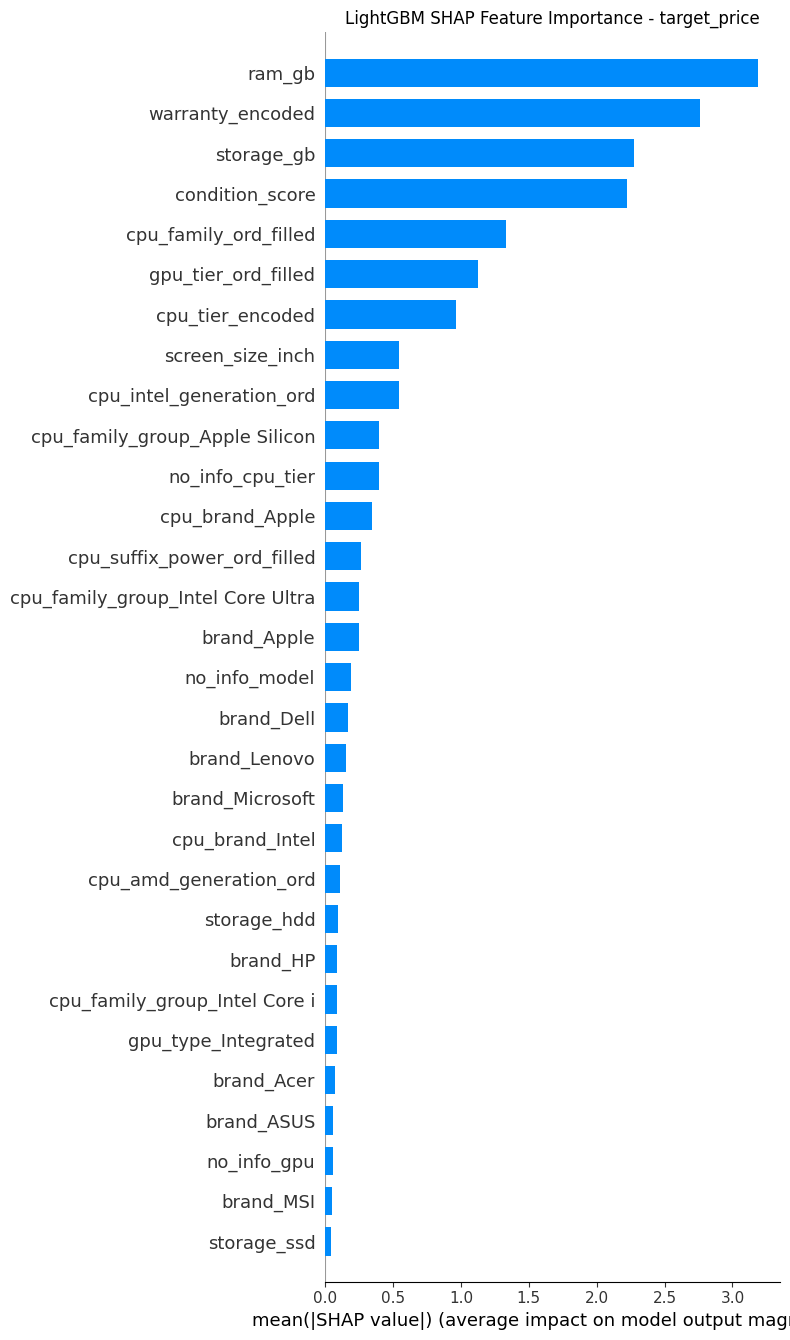

Saved SHAP bar plot: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\feature_selection\shap_summary_bar_target_price.png


In [24]:
if not shap_results:
    print("[SKIP] No SHAP results available for bar plot.")
else:
    for target_name, result in shap_results.items():
        suffix = safe_artifact_name(target_name)
        X_sample = result["X_sample"]
        shap_values = result["shap_values"]

        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=SHAP_TOP_N, show=False)
        plt.title(f"{SHAP_MODEL_NAME} SHAP Feature Importance - {target_name}")
        plt.tight_layout()

        bar_path = FEATURE_SEL_DIR / f"shap_summary_bar_{suffix}.png"
        plt.savefig(bar_path, dpi=160, bbox_inches="tight")
        plt.show()
        print(f"Saved SHAP bar plot: {bar_path}")


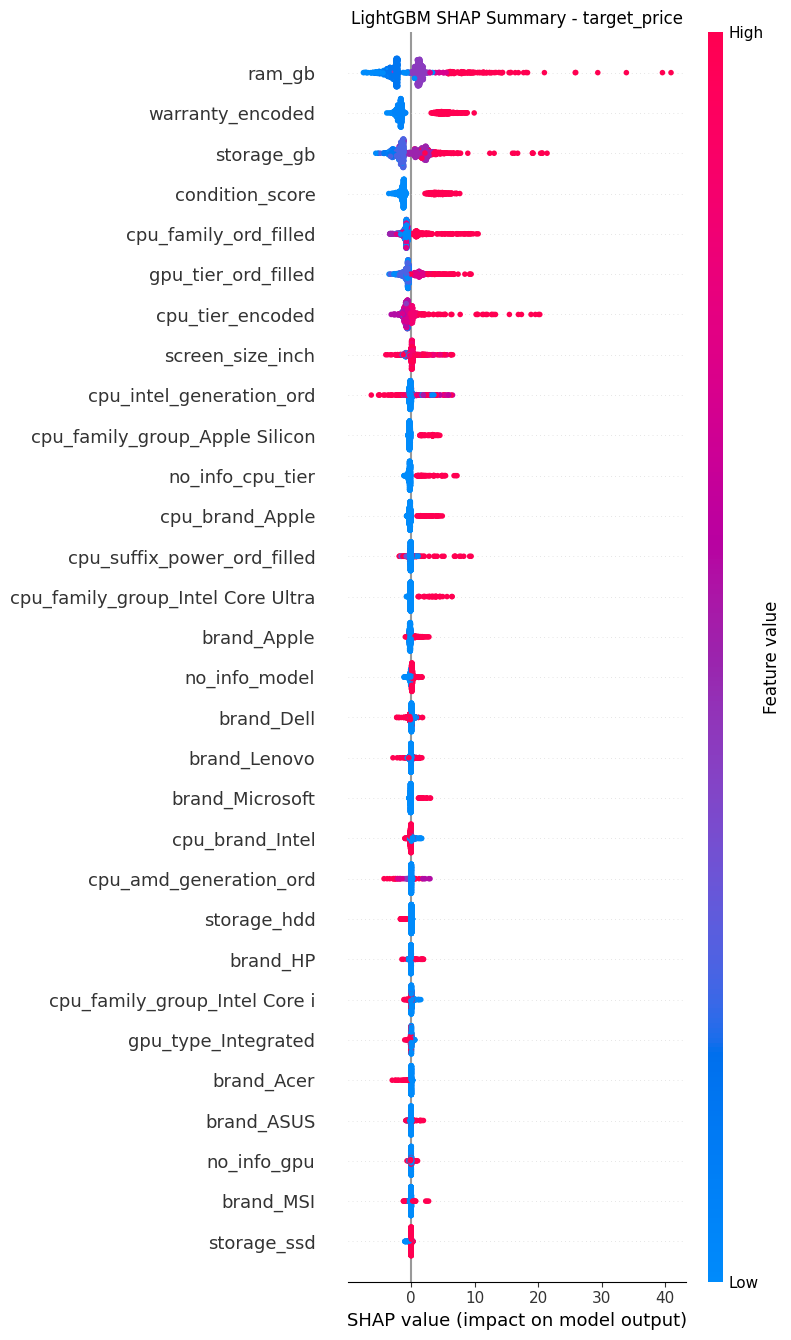

Saved SHAP beeswarm plot: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\feature_selection\shap_summary_beeswarm_target_price.png


In [25]:
if not shap_results:
    print("[SKIP] No SHAP results available for beeswarm plot.")
else:
    for target_name, result in shap_results.items():
        suffix = safe_artifact_name(target_name)
        X_sample = result["X_sample"]
        shap_values = result["shap_values"]

        plt.figure(figsize=(10, 8))
        shap.summary_plot(shap_values, X_sample, max_display=SHAP_TOP_N, show=False)
        plt.title(f"{SHAP_MODEL_NAME} SHAP Summary - {target_name}")
        plt.tight_layout()

        beeswarm_path = FEATURE_SEL_DIR / f"shap_summary_beeswarm_{suffix}.png"
        plt.savefig(beeswarm_path, dpi=160, bbox_inches="tight")
        plt.show()
        print(f"Saved SHAP beeswarm plot: {beeswarm_path}")


## Nhận xét SHAP summary plot cho LightGBM - target_price

Biểu đồ SHAP summary cho thấy mô hình `LightGBM` đang dự đoán `target_price` chủ yếu dựa trên các feature cấu hình, tình trạng máy và bảo hành. Các feature có ảnh hưởng mạnh nhất gồm `ram_gb`, `warranty_encoded`, `storage_gb`, `condition_score`, `cpu_family_ord_filled`, `gpu_tier_ord_filled` và `cpu_tier_encoded`. Đây là các biến nằm ở nhóm đầu về mean absolute SHAP, đồng thời cũng là các biến xuất hiện nhiều trong high-error audit, cho thấy chúng vừa quan trọng với mô hình, vừa là nguồn cần kiểm tra kỹ khi mô hình dự đoán sai ở vùng giá cao.

Feature `ram_gb` có tác động mạnh nhất và có pattern khá rõ: giá trị RAM cao thường kéo dự đoán giá lên mạnh, thể hiện qua các điểm màu đỏ nằm nhiều ở phía SHAP dương. Ngược lại, RAM thấp thường nằm gần 0 hoặc phía âm. Tuy nhiên, phần đuôi SHAP dương của `ram_gb` rất dài, có nhiều điểm vượt xa các feature khác. Điều này cho thấy mô hình đang gán mức premium lớn cho các máy RAM cao, nhưng cũng có rủi ro over-sensitive với RAM nếu RAM cao xuất hiện cùng các mẫu hiếm hoặc bị parse sai.

`warranty_encoded` cũng có tác động rất mạnh. Các giá trị warranty cao tập trung rõ ở phía SHAP dương, nghĩa là mô hình học rằng trạng thái bảo hành tốt hơn sẽ làm tăng giá dự đoán. Đây là tín hiệu hợp lý, nhưng vì feature này có ảnh hưởng lớn thứ hai, cần kiểm tra kỹ encoding của `warranty_encoded`. Nếu đây là biến ordinal, cần đảm bảo thứ tự giá trị thật sự phản ánh đúng mức độ giá trị kinh tế của bảo hành. Có thể nên thử one-hot warranty để tránh mô hình hiểu sai khoảng cách giữa các trạng thái bảo hành.

`storage_gb` có pattern tương tự `ram_gb`, nhưng yếu hơn. Storage cao thường kéo giá dự đoán lên, trong khi storage thấp có xu hướng làm giảm hoặc ít ảnh hưởng đến dự đoán. Phần SHAP dương của `storage_gb` cũng có một số điểm xa, cho thấy các máy storage lớn đang được mô hình xem là dấu hiệu của phân khúc cao cấp. Tuy nhiên, storage có thể chỉ là proxy cho laptop premium, nên cần kết hợp với RAM, GPU, CPU và model để tránh định giá quá cao các máy chỉ có storage lớn nhưng không thật sự cao cấp.

`condition_score` có tác động rất rõ và gần như một chiều: giá trị condition cao làm tăng dự đoán giá. Điều này hợp lý nếu `condition_score` càng cao nghĩa là tình trạng máy càng tốt. Tuy nhiên, vì feature này có SHAP importance rất lớn, cần kiểm tra lại mapping của `condition_score` để đảm bảo không bị ngược chiều. Ngoài ra, nên tạo interaction giữa `condition_score` và `warranty_encoded`, vì tác động của tình trạng máy thường mạnh hơn khi đi kèm bảo hành tốt.

Nhóm CPU có ảnh hưởng đáng kể, đặc biệt là `cpu_family_ord_filled`, `cpu_tier_encoded`, `cpu_intel_generation_ord`, `cpu_family_group_Apple Silicon`, `cpu_suffix_power_ord_filled` và `cpu_family_group_Intel Core Ultra`. Các giá trị CPU cao hoặc thuộc nhóm mới/cao cấp thường có SHAP dương, nghĩa là làm tăng giá dự đoán. Tuy nhiên, một số feature CPU có điểm nằm cả hai phía âm và dương, cho thấy tác động của CPU phụ thuộc vào tổ hợp với các feature khác như RAM, GPU, brand hoặc model. Vì vậy cần kiểm tra kỹ ordinal encoding của CPU family, CPU tier, generation và suffix power.

`gpu_tier_ord_filled` cũng có xu hướng rõ: GPU tier cao thường kéo dự đoán giá lên. Tuy nhiên, mức tác động của GPU thấp hơn RAM, warranty, storage và condition. Điều này có thể cho thấy GPU representation hiện tại chưa đủ chi tiết, hoặc dữ liệu GPU chưa đủ mạnh để mô hình học được chênh lệch lớn giữa GPU phổ thông, gaming GPU và workstation GPU. Với laptop gaming hoặc workstation, nên cải thiện mapping GPU thay vì chỉ dùng một tier tổng quát.

Các feature Apple như `cpu_family_group_Apple Silicon`, `cpu_brand_Apple` và `brand_Apple` đều có điểm SHAP dương rõ ràng ở một số mẫu. Điều này cho thấy mô hình có học được premium effect của hệ sinh thái Apple/MacBook. Tuy nhiên, tác động bị chia nhỏ qua nhiều biến Apple khác nhau, nên nên kiểm tra thêm group-level importance thay vì chỉ nhìn từng one-hot riêng lẻ.

Một điểm quan trọng là các brand riêng lẻ như `brand_Dell`, `brand_Lenovo`, `brand_HP`, `brand_ASUS`, `brand_Acer`, `brand_MSI` có SHAP nhỏ hơn nhiều so với nhóm cấu hình và trạng thái máy. Điều này không nhất thiết có nghĩa brand không quan trọng. Có thể brand effect đang bị phân tán, hoặc giá trị thương hiệu chỉ mạnh khi kết hợp với model cụ thể như XPS, ThinkPad X1 Carbon, ROG, Legion, Precision, ZBook hoặc MacBook Pro. Vì vậy cần cải thiện feature model/series thay vì chỉ dựa vào brand one-hot.

Biểu đồ cũng cho thấy nhiều feature ở nửa dưới có SHAP gần 0, ví dụ `storage_hdd`, `storage_ssd`, `no_info_gpu`, một số brand và một số nhóm CPU/GPU nhỏ. Các feature này không nhất thiết phải loại bỏ ngay, nhưng có thể đưa vào nhóm kiểm tra khi làm feature selection/ablation. Nếu loại bỏ chúng không làm giảm performance, có thể rút gọn feature set để mô hình ổn định hơn.

Nhìn chung, SHAP summary xác nhận rằng mô hình đang học theo hướng hợp lý: RAM cao, storage lớn, bảo hành tốt, condition tốt, CPU/GPU mạnh và Apple/Core Ultra thường làm tăng giá dự đoán. Tuy nhiên, các feature có ảnh hưởng mạnh nhất cũng chính là các feature liên quan đến lỗi lớn trong high-error audit. Vì vậy, vấn đề không phải là mô hình dùng sai feature, mà là các feature này cần được biểu diễn tốt hơn ở vùng cấu hình cao và laptop premium.

Hướng xử lý tiếp theo nên là:
- Kiểm tra lại mapping/encoding của `warranty_encoded`, `condition_score`, `cpu_family_ord_filled`, `cpu_tier_encoded`, `cpu_suffix_power_ord_filled` và `gpu_tier_ord_filled`.
- Thử one-hot hoặc tier hóa các biến ordinal quan trọng nếu khoảng cách giữa các mức không tuyến tính.
- Tạo interaction giữa `ram_gb`, `storage_gb`, `gpu_tier_ord_filled`, `condition_score` và `warranty_encoded`.
- Tạo các feature phân khúc như `is_high_ram`, `is_large_storage`, `is_high_end_gpu`, `is_premium_cpu`, `is_apple_silicon`, `is_core_ultra`, `is_gaming_model`, `is_workstation_model`.
- Cải thiện parsing model/series để giảm `model_Other` và nhận diện tốt hơn các dòng premium.
- Sau khi thêm feature, đánh giá riêng trên nhóm `Premium`, `ram_gb >= 32`, `storage_gb >= 1000`, GPU tier cao, Apple Silicon, Intel Core Ultra và các dòng `model_Other`.

Tóm lại, biểu đồ SHAP này ủng hộ hướng **giữ lại các feature top SHAP nhưng cải thiện representation**, thay vì drop feature. Trọng tâm tiếp theo nên là xử lý vùng laptop cao cấp, feature hiếm/cực trị và interaction giữa cấu hình mạnh với tình trạng máy/bảo hành.

## 10. Data Preparation for Retraining Experiments

Tạo một **single shared 80/20 split** dùng chung cho tất cả experiments ở Section 11.

> **Nguyên tắc:** Mọi experiment phải dùng cùng `train_idx` / `test_idx` để metric có thể so sánh công bằng.
> `df` gốc không được overwrite; mỗi experiment tự tạo bản copy riêng.

In [26]:
# ============================================================
# 10.1  Load & validate data
# ============================================================

TARGET_PRICE_COL     = "target_price"
TARGET_LOG_PRICE_COL = "log_target_price"
SEGMENT_COL          = "price_segment"

PRIMARY_TARGET = TARGET_PRICE_COL

_df_loaded = pd.read_csv(DATA_PATH)
print("Data shape:", _df_loaded.shape)

# Giữ log_target_price nếu cần so sánh phụ, nhưng experiment chính dùng target_price.
if TARGET_LOG_PRICE_COL not in _df_loaded.columns and TARGET_PRICE_COL in _df_loaded.columns:
    _df_loaded[TARGET_LOG_PRICE_COL] = np.log1p(_df_loaded[TARGET_PRICE_COL])
    print("[INFO] log_target_price derived via np.log1p for optional comparison only")

for col in [TARGET_PRICE_COL, TARGET_LOG_PRICE_COL]:
    if col in _df_loaded.columns:
        _df_loaded[col] = pd.to_numeric(_df_loaded[col], errors="coerce")

before = len(_df_loaded)
df = _df_loaded[_df_loaded[TARGET_PRICE_COL].notna() & (_df_loaded[TARGET_PRICE_COL] > 0)].copy()
df = df.reset_index(drop=True)
print(f"Rows removed (invalid target_price): {before - len(df)}  |  Final shape: {df.shape}")


Data shape: (7296, 88)
Rows removed (invalid target_price): 0  |  Final shape: (7296, 88)


In [27]:
# ============================================================
# 10.2  Shared target & price segment
# ============================================================

y_target = df[TARGET_PRICE_COL].reset_index(drop=True)
y_price = y_target.copy()
y_log = df[TARGET_LOG_PRICE_COL].reset_index(drop=True) if TARGET_LOG_PRICE_COL in df.columns else np.log1p(y_price)

# Dùng segment column có sẵn; nếu không có thì tạo từ quantile
if SEGMENT_COL in df.columns:
    price_segment = df[SEGMENT_COL].reset_index(drop=True)
    print(f"Using existing segment column: {SEGMENT_COL}")
else:
    price_segment = pd.qcut(
        y_price, q=4,
        labels=["Low", "Mid", "High", "Premium"],
        duplicates="drop",
    )
    price_segment = pd.Series(price_segment, name=SEGMENT_COL).reset_index(drop=True)
    print("Segment column created from quantile cut")

print("\nSegment distribution:")
print(price_segment.value_counts().sort_index())


Segment column created from quantile cut

Segment distribution:
price_segment
Low        1836
Mid        1867
High       1769
Premium    1824
Name: count, dtype: int64


In [28]:
# ============================================================
# 10.3  Shared 80/20 stratified split  (chỉ tạo 1 lần)
# ============================================================

all_idx = np.arange(len(df))

train_idx, test_idx = train_test_split(
    all_idx,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=price_segment,
)

seg_train = price_segment.iloc[train_idx].reset_index(drop=True)
seg_test  = price_segment.iloc[test_idx].reset_index(drop=True)

print(f"Train: {len(train_idx)}  |  Test: {len(test_idx)}")
print("\nTrain segment counts:")
print(seg_train.value_counts().sort_index())
print("\nTest segment counts:")
print(seg_test.value_counts().sort_index())


Train: 5836  |  Test: 1460

Train segment counts:
price_segment
Low        1469
Mid        1493
High       1415
Premium    1459
Name: count, dtype: int64

Test segment counts:
price_segment
Low        367
Mid        374
High       354
Premium    365
Name: count, dtype: int64


In [29]:
# ============================================================
# 10.4  Baseline feature matrix  (numeric only, targets excluded)
# ============================================================

EXCLUDE_COLS = [TARGET_PRICE_COL, TARGET_LOG_PRICE_COL, SEGMENT_COL]
EXCLUDE_COLS = [c for c in EXCLUDE_COLS if c in df.columns]

X_baseline = (
    df.drop(columns=EXCLUDE_COLS)
      .select_dtypes(include=[np.number])
      .copy()
)

print("X_baseline shape:", X_baseline.shape)
print("Columns:", X_baseline.columns.tolist())


X_baseline shape: (7296, 86)
Columns: ['ram_gb', 'storage_gb', 'screen_size_inch', 'brand_is_rare', 'model_is_rare', 'ram_missing', 'storage_missing', 'screen_missing', 'no_info_brand', 'no_info_model', 'no_info_cpu_brand', 'no_info_cpu_tier', 'no_info_gpu', 'storage_ssd', 'storage_hdd', 'no_info_storage', 'condition_score', 'warranty_encoded', 'cpu_tier_encoded', 'brand_ASUS', 'brand_Acer', 'brand_Apple', 'brand_Dell', 'brand_Gigabyte', 'brand_HP', 'brand_LG', 'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Other', 'brand_Sony', 'brand_Toshiba', 'model_Aspire', 'model_Elitebook', 'model_Elitebook 800', 'model_Gaming Thin GF', 'model_IdeaPad', 'model_Inspiron', 'model_Latitude', 'model_Latitude 14 7000', 'model_Latitude E Series', 'model_Legion', 'model_Legion 5', 'model_MacBook Air', 'model_MacBook Air M1', 'model_MacBook Air M2', 'model_MacBook Pro', 'model_MacBook Pro M1', 'model_MacBook Pro M2', 'model_Macbook air m4', 'model_Nitro 5', 'model_Other', 'model_Pavilion 15', 'mo

In [30]:
# ============================================================
# 10.5  Helper: run one LightGBM experiment with shared split
# ============================================================

def run_experiment(
    X: pd.DataFrame,
    y_target: pd.Series,
    y_price: pd.Series,
    train_idx,
    test_idx,
    seg_test: pd.Series,
    experiment_name: str,
    model_params: dict | None = None,
    sample_weight_train: np.ndarray | None = None,
    early_stopping_rounds: int | None = None,
    plot: bool = True,
    verbose: bool = False,
) -> tuple[dict, pd.DataFrame]:
    """
    Split X/y theo shared indices, train LightGBM trên target_price,
    evaluate trên price scale. Trả về result dict và 1-row metrics DataFrame.
    """
    X_train, X_test, y_train_target, y_test_target = make_train_test_data(
        X=X, y=y_target, train_idx=train_idx, test_idx=test_idx
    )
    _, _, _, y_test_price = make_train_test_data(
        X=X, y=y_price, train_idx=train_idx, test_idx=test_idx
    )

    print(f"[{experiment_name}] X_train={X_train.shape}  X_test={X_test.shape}")

    result = run_lgbm_experiment(
        experiment_name=experiment_name,
        X_train=X_train,
        y_train=y_train_target,
        X_test=X_test,
        y_test=y_test_target,
        y_test_price=y_test_price,
        target_name=TARGET_PRICE_COL,
        log_transform="log1p",
        model_params=model_params,
        segment_labels_test=seg_test,
        early_stopping_rounds=early_stopping_rounds,
        sample_weight=sample_weight_train,
        plot=plot,
        verbose=verbose,
    )

    metrics = pd.DataFrame([result["metrics"]])
    print(metrics[["experiment_name", "target_name", "mae", "rmse", "r2", "mape_pct"]].to_string(index=False))
    return result, metrics


print("Helper run_experiment() ready for LightGBM + target_price.")


Helper run_experiment() ready for LightGBM + target_price.


## 11. Retraining Experiments

Mỗi experiment thay đổi **đúng một yếu tố** (feature engineering, encoding, weighting) so với baseline, dùng cùng split để metric so sánh được.

### 11.0 Baseline

Chạy model với `X_baseline` không thay đổi để làm điểm so sánh.

[baseline] X_train=(5836, 86)  X_test=(1460, 86)


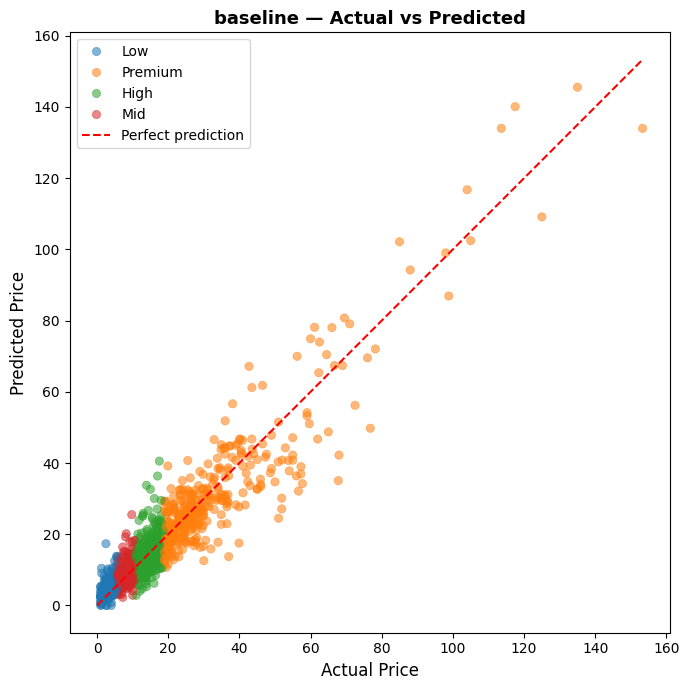

experiment_name  target_name    mae   rmse     r2  mape_pct
       baseline target_price 3.2019 5.0768 0.8874   31.0916


In [31]:
result_baseline, metrics_baseline = run_experiment(
    X=X_baseline,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="baseline",
    plot=True,
)


### 11.1 Warranty Encoding: One-hot vs Ordinal

`warranty_encoded` là biến categorical với 3 trạng thái rời rạc (0=hết BH, 1=còn BH, 2=chưa active BH). One-hot loại bỏ ordering giả tạo mà ordinal encoding ngầm tạo ra.

> **Kiểm tra đúng cách:** so sánh `X_baseline` (giữ ordinal) vs `X_onehot_warranty` (thay bằng 3 dummy). Experiment 11.3 sẽ drop warranty hoàn toàn để đo contribution thực sự.

In [32]:
# ── Tạo X với one-hot warranty ─────────────────────────────
WARRANTY_COL = "warranty_encoded"

df_w = df.copy().reset_index(drop=True)
df_w[WARRANTY_COL] = pd.to_numeric(df_w[WARRANTY_COL], errors="coerce")

# Validate: chỉ 3 giá trị hợp lệ
assert df_w[WARRANTY_COL].isin([0, 1, 2]).all(), "Unexpected warranty values"

df_w["warranty_expired"]       = (df_w[WARRANTY_COL] == 0).astype(int)
df_w["warranty_active"]        = (df_w[WARRANTY_COL] == 1).astype(int)
df_w["warranty_not_activated"] = (df_w[WARRANTY_COL] == 2).astype(int)
df_w = df_w.drop(columns=[WARRANTY_COL])

X_onehot_warranty = (
    df_w.drop(columns=EXCLUDE_COLS, errors="ignore")
        .select_dtypes(include=[np.number])
        .copy()
)

# Kiểm tra warranty columns thay đổi đúng
assert WARRANTY_COL not in X_onehot_warranty.columns, "Original warranty column still present!"
new_w_cols = [c for c in X_onehot_warranty.columns if "warranty" in c]
print("Warranty columns in X_onehot_warranty:", new_w_cols)
print("X_onehot_warranty shape:", X_onehot_warranty.shape)


Warranty columns in X_onehot_warranty: ['warranty_expired', 'warranty_active', 'warranty_not_activated']
X_onehot_warranty shape: (7296, 88)


In [33]:
result_onehot_w, metrics_onehot_w = run_experiment(
    X=X_onehot_warranty,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="warranty_onehot",
    plot=False,
)


[warranty_onehot] X_train=(5836, 88)  X_test=(1460, 88)


experiment_name  target_name    mae   rmse     r2  mape_pct
warranty_onehot target_price 3.1897 5.0627 0.8880   31.0207


Có cải thiện nhẹ so với baseline ở MAE/RMSE, nên `warranty_onehot` là một candidate hợp lý. Tuy nhiên mức cải thiện nhỏ, cần so sánh trong bảng tổng hợp cuối thay vì chọn ngay.


In [34]:
# ============================================================
# Create X with remapped warranty: 0, 1, 2 -> 0, 1, 5
# Do NOT overwrite original df / X_baseline
# ============================================================

WARRANTY_COL = "warranty_encoded"

if WARRANTY_COL not in df.columns:
    raise ValueError(
        f"Column '{WARRANTY_COL}' not found. "
        f"Available columns: {df.columns.tolist()}"
    )

# Work on a copy only
df_w_015 = df.copy().reset_index(drop=True)

# Convert warranty to numeric
df_w_015[WARRANTY_COL] = pd.to_numeric(
    df_w_015[WARRANTY_COL],
    errors="coerce"
)

# Validate: only 0, 1, 2 are allowed
invalid_values = sorted(
    df_w_015.loc[
        ~df_w_015[WARRANTY_COL].isin([0, 1, 2]),
        WARRANTY_COL
    ].dropna().unique()
)

if invalid_values:
    raise ValueError(
        f"Unexpected warranty values found: {invalid_values}"
    )

if df_w_015[WARRANTY_COL].isna().any():
    raise ValueError(
        f"Missing/NaN values found in '{WARRANTY_COL}'"
    )

print("Warranty distribution before remap:")
print(df_w_015[WARRANTY_COL].value_counts().sort_index())

warranty_mapping = {
    0: 0,
    1: 1,
    2: 5,
}

df_w_015[WARRANTY_COL] = df_w_015[WARRANTY_COL].map(warranty_mapping).astype(int)

print("\nWarranty distribution after remap:")
print(df_w_015[WARRANTY_COL].value_counts().sort_index())


X_warranty_015 = (
    df_w_015
    .drop(columns=EXCLUDE_COLS, errors="ignore")
    .select_dtypes(include=[np.number])
    .copy()
)

# ------------------------------------------------------------
# 4. Validate result
# ------------------------------------------------------------

assert WARRANTY_COL in X_warranty_015.columns, "Remapped warranty column missing!"
assert set(X_warranty_015[WARRANTY_COL].unique()).issubset({0, 1, 5}), \
    "Warranty remap failed!"

print("\nWarranty values in X_warranty_015:")
print(sorted(X_warranty_015[WARRANTY_COL].unique()))

print("\nX_warranty_015 shape:", X_warranty_015.shape)

Warranty distribution before remap:
warranty_encoded
0     430
1    5000
2    1866
Name: count, dtype: int64

Warranty distribution after remap:
warranty_encoded
0     430
1    5000
5    1866
Name: count, dtype: int64

Warranty values in X_warranty_015:
[0, 1, 5]

X_warranty_015 shape: (7296, 86)


In [35]:
result_warranty_015, metrics_warranty_015 = run_experiment(
    X=X_warranty_015,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="warranty_015",
    plot=False,
)


[warranty_015] X_train=(5836, 86)  X_test=(1460, 86)
experiment_name  target_name    mae   rmse     r2  mape_pct
   warranty_015 target_price 3.2019 5.0768 0.8874   31.0916


`warranty_015` gần như không khác baseline. Với LightGBM, việc đổi khoảng cách số học từ `0/1/2` sang `0/1/5` không tạo thêm signal rõ ràng; nếu cải thiện warranty encoding thì one-hot đáng giữ hơn.


In [36]:
# Drop tất cả warranty columns
warranty_cols_to_drop = [c for c in X_baseline.columns if "warranty" in c.lower()]
print("Dropping:", warranty_cols_to_drop)

X_no_warranty = X_baseline.drop(columns=warranty_cols_to_drop, errors="ignore").copy()
print("X_no_warranty shape:", X_no_warranty.shape)


Dropping: ['warranty_encoded']
X_no_warranty shape: (7296, 85)


In [37]:
result_no_w, metrics_no_w = run_experiment(
    X=X_no_warranty,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="ablation_drop_warranty",
    plot=False,  # không cần plot cho ablation thuần
)


[ablation_drop_warranty] X_train=(5836, 85)  X_test=(1460, 85)
       experiment_name  target_name    mae   rmse     r2  mape_pct
ablation_drop_warranty target_price 3.2523 5.1203 0.8854   31.4267


**Đọc kết quả ablation warranty:**
- `warranty_onehot` cải thiện nhẹ so với `baseline`, nên encoding dạng one-hot có thể hữu ích.
- `warranty_015` gần như trùng baseline, cho thấy độ lớn numeric của mã warranty không quan trọng bằng cách biểu diễn trạng thái.
- `ablation_drop_warranty` không làm metric xấu đi rõ rệt trong lần chạy này, nên warranty có signal yếu và cần được quyết định bằng comparison cuối.


### 11.2 Condition Score

In [38]:
# ── Tạo X với one-hot condition_score ─────────────────────────────
CONDITION_COL = "condition_score"

df_c = df.copy().reset_index(drop=True)
df_c[CONDITION_COL] = pd.to_numeric(df_c[CONDITION_COL], errors="coerce")

# Validate: chỉ 3 giá trị hợp lệ
assert df_c[CONDITION_COL].isin([1, 2, 3]).all(), "Unexpected condition_score values"

df_c["condition_score_1"] = (df_c[CONDITION_COL] == 1).astype(int)
df_c["condition_score_2"] = (df_c[CONDITION_COL] == 2).astype(int)
df_c["condition_score_3"] = (df_c[CONDITION_COL] == 3).astype(int)

# Drop cột gốc sau khi one-hot
df_c = df_c.drop(columns=[CONDITION_COL])

X_onehot_condition = (
    df_c.drop(columns=EXCLUDE_COLS, errors="ignore")
        .select_dtypes(include=[np.number])
        .copy()
)

# Kiểm tra condition columns thay đổi đúng
assert CONDITION_COL not in X_onehot_condition.columns, "Original condition_score column still present!"

new_c_cols = [c for c in X_onehot_condition.columns if "condition" in c]

print("Condition columns in X_onehot_condition:", new_c_cols)
print("X_onehot_condition shape:", X_onehot_condition.shape)

Condition columns in X_onehot_condition: ['condition_score_1', 'condition_score_2', 'condition_score_3']
X_onehot_condition shape: (7296, 88)


In [39]:
result_onehot_c, metrics_onehot_c = run_experiment(
    X=X_onehot_condition,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="condition_onehot",
    plot=False,
)


[condition_onehot] X_train=(5836, 88)  X_test=(1460, 88)
 experiment_name  target_name    mae   rmse     r2  mape_pct
condition_onehot target_price 3.2141 5.1167 0.8856   31.0781


In [40]:
# Drop tất cả condition columns
condition_cols_to_drop = [
    c for c in X_baseline.columns
    if "condition" in c.lower()
]

print("Dropping:", condition_cols_to_drop)

X_no_condition = X_baseline.drop(
    columns=condition_cols_to_drop,
    errors="ignore"
).copy()

print("X_no_condition shape:", X_no_condition.shape)

Dropping: ['condition_score']
X_no_condition shape: (7296, 85)


In [41]:
result_no_c, metrics_no_c = run_experiment(
    X=X_no_condition,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="ablation_drop_condition",
    plot=False,
)


[ablation_drop_condition] X_train=(5836, 85)  X_test=(1460, 85)
        experiment_name  target_name    mae   rmse     r2  mape_pct
ablation_drop_condition target_price 3.2164 5.1334 0.8849   31.2628


Condition one-hot/drop cho kết quả tương tự nhóm warranty: tác động không lớn và chưa đủ để chọn riêng lẻ. Giữ nhóm này như candidate phụ, ưu tiên quyết định bằng bảng delta so với baseline ở Section 12.


### 11.3 Feature Phi Tuyến từ RAM / Storage

LightGBM là tree-based — **bất biến với monotonic scaling** (`ram_gb / 512` cho kết quả giống hệt `ram_gb`). Các feature thực sự mới cần tạo ra **information chưa có** trong data:

- `ram_storage_ratio`: tỷ lệ RAM/Storage phản ánh cân bằng workload
- `log_ram_gb`, `log_storage_gb`: compress tail distribution của high-end laptops  
- `ram_tier`, `storage_tier`: bucketize theo ngưỡng thị trường thực tế
- `is_high_ram`: binary flag cho laptops ≥32GB (workstation/pro segment)


In [42]:
# ============================================================
# Create X with only high-spec indicator features
# Do NOT overwrite original df / X_baseline
# ============================================================

df_high = df.copy().reset_index(drop=True)

RAM_COL = "ram_gb"
STORAGE_COL = "storage_gb"

# ------------------------------------------------------------
# 1. Validate required columns
# ------------------------------------------------------------

missing_cols = [
    col for col in [RAM_COL, STORAGE_COL]
    if col not in df_high.columns
]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# ------------------------------------------------------------
# 2. Convert to numeric
# ------------------------------------------------------------

df_high[RAM_COL] = pd.to_numeric(df_high[RAM_COL], errors="coerce")
df_high[STORAGE_COL] = pd.to_numeric(df_high[STORAGE_COL], errors="coerce")

# ------------------------------------------------------------
# 3. Create high-spec flags
# ------------------------------------------------------------

df_high["is_high_ram_16"] = (df_high[RAM_COL] >= 16).astype(int)
df_high["is_high_ram_32"] = (df_high[RAM_COL] >= 32).astype(int)

df_high["is_large_storage_512"] = (df_high[STORAGE_COL] >= 512).astype(int)
df_high["is_large_storage_1024"] = (df_high[STORAGE_COL] >= 1024).astype(int)

df_high["is_high_ram_large_storage"] = (
    (df_high[RAM_COL] >= 16) &
    (df_high[STORAGE_COL] >= 512)
).astype(int)

# ------------------------------------------------------------
# 4. Create numeric feature matrix
# ------------------------------------------------------------

X_high_spec = (
    df_high
    .drop(columns=EXCLUDE_COLS, errors="ignore")
    .select_dtypes(include=[np.number])
    .copy()
)

# ------------------------------------------------------------
# 5. Keep baseline + only new high-spec flags
# ------------------------------------------------------------

high_spec_features = [
    "is_high_ram_16",
    "is_high_ram_32",
    "is_large_storage_512",
    "is_large_storage_1024",
    "is_high_ram_large_storage",
]

high_spec_cols = X_baseline.columns.tolist() + high_spec_features
high_spec_cols = [c for c in high_spec_cols if c in X_high_spec.columns]

X_high_spec_only = X_high_spec[high_spec_cols].copy()

print("New high-spec features:", high_spec_features)
print("Actually added:", [c for c in X_high_spec_only.columns if c not in X_baseline.columns])
print("X_high_spec_only shape:", X_high_spec_only.shape)

print("\nHigh-spec feature distribution:")
display(X_high_spec_only[high_spec_features].agg(["mean", "sum"]).T)

New high-spec features: ['is_high_ram_16', 'is_high_ram_32', 'is_large_storage_512', 'is_large_storage_1024', 'is_high_ram_large_storage']
Actually added: ['is_high_ram_16', 'is_high_ram_32', 'is_large_storage_512', 'is_large_storage_1024', 'is_high_ram_large_storage']
X_high_spec_only shape: (7296, 91)

High-spec feature distribution:


,mean,sum
is_high_ram_16,0.4981,"3,634.0000"
is_high_ram_32,0.0902,658.0000
is_large_storage_512,0.4807,"3,507.0000"
is_large_storage_1024,0.1324,966.0000
is_high_ram_large_storage,0.3657,"2,668.0000"


In [43]:
# ============================================================
# Run experiment: high-spec RAM / Storage flags only
# ============================================================

result_high_spec, metrics_high_spec = run_experiment(
    X=X_high_spec_only,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="rs_high_spec_flags",
    plot=False,
)


[rs_high_spec_flags] X_train=(5836, 91)  X_test=(1460, 91)
   experiment_name  target_name    mae   rmse     r2  mape_pct
rs_high_spec_flags target_price 3.2048 5.0681 0.8878   31.2390


In [44]:
df_rs2 = df.copy().reset_index(drop=True)

RAM_COL = "ram_gb"
STORAGE_COL = "storage_gb"

for col in [RAM_COL, STORAGE_COL]:
    if col not in df_rs2.columns:
        raise ValueError(f"Missing required column: {col}")
    df_rs2[col] = pd.to_numeric(df_rs2[col], errors="coerce")

df_rs2["ram_storage_product_scaled"] = (
    df_rs2[RAM_COL] * df_rs2[STORAGE_COL]
) / (16 * 512)

df_rs2["ram_storage_balance"] = np.minimum(
    df_rs2[RAM_COL] / 16,
    df_rs2[STORAGE_COL] / 512
)

df_rs2["memory_storage_score"] = (
    2.0 * np.log1p(df_rs2[RAM_COL]) +
    1.0 * np.log1p(df_rs2[STORAGE_COL])
)

df_rs2["is_entry_memory_storage"] = (
    (df_rs2[RAM_COL] <= 8) &
    (df_rs2[STORAGE_COL] <= 256)
).astype(int)

df_rs2["is_mid_memory_storage"] = (
    (df_rs2[RAM_COL] >= 16) &
    (df_rs2[STORAGE_COL] >= 512)
).astype(int)

df_rs2["is_premium_memory_storage"] = (
    (df_rs2[RAM_COL] >= 32) &
    (df_rs2[STORAGE_COL] >= 1024)
).astype(int)

X_rs2_all = (
    df_rs2
    .drop(columns=EXCLUDE_COLS, errors="ignore")
    .select_dtypes(include=[np.number])
    .copy()
)

rs2_features = [
    "ram_storage_product_scaled",
    "ram_storage_balance",
    "memory_storage_score",
    "is_entry_memory_storage",
    "is_mid_memory_storage",
    "is_premium_memory_storage",
]

# Keep baseline + only new RAM/Storage features
rs2_cols = X_baseline.columns.tolist() + rs2_features
rs2_cols = [c for c in rs2_cols if c in X_rs2_all.columns]

X_rs2 = X_rs2_all[rs2_cols].copy()

print("New RAM/Storage features:", rs2_features)
print("Actually added:", [c for c in X_rs2.columns if c not in X_baseline.columns])
print("X_rs2 shape:", X_rs2.shape)

display(
    X_rs2[rs2_features]
    .describe()
    .T[["mean", "min", "50%", "max"]]
)

New RAM/Storage features: ['ram_storage_product_scaled', 'ram_storage_balance', 'memory_storage_score', 'is_entry_memory_storage', 'is_mid_memory_storage', 'is_premium_memory_storage']
Actually added: ['ram_storage_product_scaled', 'ram_storage_balance', 'memory_storage_score', 'is_entry_memory_storage', 'is_mid_memory_storage', 'is_premium_memory_storage']
X_rs2 shape: (7296, 92)


,mean,min,50%,max
ram_storage_product_scaled,0.9986,0.0000,0.5000,144.0000
ram_storage_balance,0.6797,0.0000,0.5000,12.0000
memory_storage_score,10.5256,0.0000,10.6347,19.2488
is_entry_memory_storage,0.3660,0.0000,0.0000,1.0000
is_mid_memory_storage,0.3657,0.0000,0.0000,1.0000
is_premium_memory_storage,0.0526,0.0000,0.0000,1.0000


In [45]:
result_rs2, metrics_rs2 = run_experiment(
    X=X_rs2,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="rs2_ram_storage_interactions",
    plot=False,
)

[rs2_ram_storage_interactions] X_train=(5836, 92)  X_test=(1460, 92)
             experiment_name  target_name    mae   rmse     r2  mape_pct
rs2_ram_storage_interactions target_price 3.1852 5.0410 0.8890   30.6421


### Observation

Nhóm RAM/Storage engineered features có cải thiện nhưng không đồng đều. `rs2_ram_storage_interactions` là case tốt nhất trong nhóm này theo RMSE, đạt khoảng MAE `3.1852`, RMSE `5.0410`, R² `0.8890`, MAPE `30.6421%`, tốt hơn baseline `5.0768` rõ hơn các biến high-spec flag đơn giản.

`rs_high_spec_flags` chỉ cải thiện nhẹ theo RMSE, còn `rs_relative_brand_ohe` cải thiện nhất quán cả RMSE và MAPE nhưng mức tăng nhỏ hơn `rs2_ram_storage_interactions`. Điều này cho thấy interaction/balance score từ RAM và storage có thêm signal, nhưng không phải mọi biến RAM/Storage thủ công đều đáng giữ.

Kết luận thực dụng: không thêm toàn bộ feature RAM/Storage một cách mặc định. Giữ `rs2_ram_storage_interactions` và `rs_relative_brand_ohe` làm candidate mạnh để đưa vào Section 12, sau đó so sánh trực tiếp với baseline và các nhóm GPU/model-family/CPU bằng cùng split.


In [46]:
# ============================================================
# RAM / Storage relative-to-brand features
# Brand is already one-hot encoded with prefix "brand_"
# Avoid overwriting original df / X_baseline
# ============================================================

df_rel = df.copy().reset_index(drop=True)

RAM_COL = "ram_gb"
STORAGE_COL = "storage_gb"
BRAND_PREFIX = "brand_"

# ------------------------------------------------------------
# 1. Validate required numeric columns
# ------------------------------------------------------------

for col in [RAM_COL, STORAGE_COL]:
    if col not in df_rel.columns:
        raise ValueError(f"Missing required column: {col}")

df_rel[RAM_COL] = pd.to_numeric(df_rel[RAM_COL], errors="coerce")
df_rel[STORAGE_COL] = pd.to_numeric(df_rel[STORAGE_COL], errors="coerce")

# ------------------------------------------------------------
# 2. Detect one-hot brand columns
# ------------------------------------------------------------

brand_cols = [
    c for c in df_rel.columns
    if c.startswith(BRAND_PREFIX)
]

if len(brand_cols) == 0:
    raise ValueError(
        f"No one-hot brand columns found with prefix '{BRAND_PREFIX}'"
    )

print("Detected brand one-hot columns:")
print(brand_cols)

# ------------------------------------------------------------
# 3. Reconstruct temporary brand group from one-hot columns
# ------------------------------------------------------------

brand_ohe = df_rel[brand_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# If one brand column is 1, use that column name as group.
# If all are 0, mark as unknown_brand.
df_rel["_brand_group_tmp"] = brand_ohe.idxmax(axis=1)

no_brand_mask = brand_ohe.sum(axis=1) == 0
df_rel.loc[no_brand_mask, "_brand_group_tmp"] = "unknown_brand"

print("\nTemporary brand group distribution:")
print(df_rel["_brand_group_tmp"].value_counts())

# Optional validation: check rows with more than one active brand
multi_brand_mask = brand_ohe.sum(axis=1) > 1
print("\nRows with multiple active brand columns:", multi_brand_mask.sum())

# ------------------------------------------------------------
# 4. Median RAM / Storage by reconstructed brand group
# ------------------------------------------------------------

brand_ram_median = df_rel.groupby("_brand_group_tmp")[RAM_COL].transform("median")
brand_storage_median = df_rel.groupby("_brand_group_tmp")[STORAGE_COL].transform("median")

df_rel["ram_vs_brand_median"] = (
    df_rel[RAM_COL] / brand_ram_median.replace(0, np.nan)
)

df_rel["storage_vs_brand_median"] = (
    df_rel[STORAGE_COL] / brand_storage_median.replace(0, np.nan)
)

df_rel["ram_minus_brand_median"] = (
    df_rel[RAM_COL] - brand_ram_median
)

df_rel["storage_minus_brand_median"] = (
    df_rel[STORAGE_COL] - brand_storage_median
)

rel_features = [
    "ram_vs_brand_median",
    "storage_vs_brand_median",
    "ram_minus_brand_median",
    "storage_minus_brand_median",
]

# ------------------------------------------------------------
# 5. Create numeric feature matrix
# ------------------------------------------------------------

X_rel_all = (
    df_rel
    .drop(columns=EXCLUDE_COLS + ["_brand_group_tmp"], errors="ignore")
    .select_dtypes(include=[np.number])
    .copy()
)

# Keep baseline + only new relative features
rel_cols = X_baseline.columns.tolist() + rel_features
rel_cols = [c for c in rel_cols if c in X_rel_all.columns]

X_rs_relative_brand = X_rel_all[rel_cols].copy()

print("\nAdded features:", [c for c in X_rs_relative_brand.columns if c not in X_baseline.columns])
print("X_rs_relative_brand shape:", X_rs_relative_brand.shape)

display(
    X_rs_relative_brand[rel_features]
    .describe()
    .T[["mean", "min", "50%", "max"]]
)

Detected brand one-hot columns:
['brand_is_rare', 'brand_ASUS', 'brand_Acer', 'brand_Apple', 'brand_Dell', 'brand_Gigabyte', 'brand_HP', 'brand_LG', 'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Other', 'brand_Sony', 'brand_Toshiba']

Temporary brand group distribution:
_brand_group_tmp
brand_Dell         1983
brand_Lenovo       1075
brand_Apple         993
brand_HP            942
brand_ASUS          867
brand_Acer          486
brand_MSI           308
brand_Other         300
brand_Microsoft     247
brand_is_rare        95
Name: count, dtype: int64

Rows with multiple active brand columns: 95

Added features: ['ram_vs_brand_median', 'storage_vs_brand_median', 'ram_minus_brand_median', 'storage_minus_brand_median']
X_rs_relative_brand shape: (7296, 90)


,mean,min,50%,max
ram_vs_brand_median,1.3287,0.0000,1.0000,24.0000
storage_vs_brand_median,1.3390,0.0000,1.0000,32.0000
ram_minus_brand_median,2.5249,-16.0000,0.0000,184.0000
storage_minus_brand_median,89.4555,-512.0000,0.0000,"7,936.0000"


In [47]:
result_rs_relative_brand, metrics_rs_relative_brand = run_experiment(
    X=X_rs_relative_brand,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="rs_relative_brand_ohe",
    plot=False,
)


[rs_relative_brand_ohe] X_train=(5836, 90)  X_test=(1460, 90)
      experiment_name  target_name    mae   rmse     r2  mape_pct
rs_relative_brand_ohe target_price 3.1918 5.0634 0.8880   30.7965


### Observation

Với `LightGBM + target_price`, nhóm feature RAM/Storage relative-to-brand cải thiện nhẹ nhưng nhất quán so với baseline. Baseline đạt MAE khoảng `3.2019`, RMSE `5.0768`, R² `0.8874`, MAPE `31.0916%`; `rs_relative_brand_ohe` đạt MAE khoảng `3.1915`, RMSE `5.0634`, R² `0.888`, MAPE `30.7965%`.

Điểm đáng chú ý là feature này không chỉ giảm RMSE mà còn giảm MAPE. Việc so sánh RAM và storage của một máy với mặt bằng cùng brand đang bổ sung ngữ cảnh thị trường hữu ích.

Nhóm feature này nên được giữ như một candidate tốt để kiểm tra trong các tổ hợp tiếp theo. Mức cải thiện vẫn nhỏ, nên cần so sánh tiếp với các nhóm GPU/model-family và CPU mở rộng.


### 11.4 GPU 

In [48]:
# ============================================================
# Check duplicated missing-GPU signals
# ============================================================

gpu_missing_cols = ["no_info_gpu", "gpu_type_Missing_Info"]

for c in gpu_missing_cols:
    if c not in X_baseline.columns:
        print(f"Missing column: {c}")

if all(c in X_baseline.columns for c in gpu_missing_cols):
    compare_gpu_missing = pd.crosstab(
        X_baseline["no_info_gpu"],
        X_baseline["gpu_type_Missing_Info"],
        dropna=False
    )
    
    print("Crosstab: no_info_gpu vs gpu_type_Missing_Info")
    display(compare_gpu_missing)
    
    mismatch_mask = (
        X_baseline["no_info_gpu"] != X_baseline["gpu_type_Missing_Info"]
    )
    
    print("Mismatch count:", mismatch_mask.sum())
    print("Mismatch rate:", mismatch_mask.mean())

Crosstab: no_info_gpu vs gpu_type_Missing_Info


gpu_type_Missing_Info,0,1
no_info_gpu,,
0,5405,0
1,0,1891


Mismatch count: 0
Mismatch rate: 0.0


Ta drop `gpu_type_Missing_Info`

In [49]:
# ============================================================
# GPU tier bucket features
# ============================================================

df_gpu_eval = X_baseline.copy().reset_index(drop=True)

GPU_TIER_COL = "gpu_tier_ord_filled"

df_gpu_eval[GPU_TIER_COL] = pd.to_numeric(
    df_gpu_eval[GPU_TIER_COL],
    errors="coerce"
).fillna(0)

df_gpu_eval["gpu_tier_is_0_or_missing"] = (
    df_gpu_eval[GPU_TIER_COL] <= 0
).astype(int)

df_gpu_eval["gpu_tier_low"] = (
    df_gpu_eval[GPU_TIER_COL].between(1, 2)
).astype(int)

df_gpu_eval["gpu_tier_mid"] = (
    df_gpu_eval[GPU_TIER_COL].between(3, 4)
).astype(int)

df_gpu_eval["gpu_tier_high"] = (
    df_gpu_eval[GPU_TIER_COL] >= 5
).astype(int)

gpu_tier_bucket_features = [
    "gpu_tier_is_0_or_missing",
    "gpu_tier_low",
    "gpu_tier_mid",
    "gpu_tier_high",
]

In [50]:
# ============================================================
# Step 1: Drop redundant GPU missing-info feature
# ============================================================

DROP_GPU_COLS = [
    "gpu_type_Missing_Info",
]

X_gpu_base_clean = X_baseline.drop(
    columns=DROP_GPU_COLS,
    errors="ignore"
).copy()

print("Original X_baseline shape:", X_baseline.shape)
print("X_gpu_base_clean shape:", X_gpu_base_clean.shape)

gpu_cols_clean = [c for c in X_gpu_base_clean.columns if "gpu" in c.lower()]
print("GPU features after drop:")
for c in gpu_cols_clean:
    print(" -", c)

Original X_baseline shape: (7296, 86)
X_gpu_base_clean shape: (7296, 85)
GPU features after drop:
 - no_info_gpu
 - gpu_tier_ord_filled
 - gpu_type_Apple SoC
 - gpu_type_Dedicated
 - gpu_type_Integrated


In [51]:

result_gpu_base_clean, metrics_gpu_base_clean = run_experiment(
    X=X_gpu_base_clean,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="gpu_base_drop_missing_info",
    plot=False,
)

[gpu_base_drop_missing_info] X_train=(5836, 85)  X_test=(1460, 85)
           experiment_name  target_name    mae   rmse     r2  mape_pct
gpu_base_drop_missing_info target_price 3.2019 5.0768 0.8874   31.0916


In [52]:
df_gpu = df.copy().reset_index(drop=True)

GPU_TIER_COL = "gpu_tier_ord_filled"

if GPU_TIER_COL not in df_gpu.columns:
    raise ValueError(f"Missing required column: {GPU_TIER_COL}")

df_gpu[GPU_TIER_COL] = pd.to_numeric(
    df_gpu[GPU_TIER_COL],
    errors="coerce"
).fillna(0)

df_gpu["gpu_tier_0_or_missing"] = (
    df_gpu[GPU_TIER_COL] <= 0
).astype(int)

df_gpu["gpu_tier_low"] = (
    df_gpu[GPU_TIER_COL].between(1, 2)
).astype(int)

df_gpu["gpu_tier_mid"] = (
    df_gpu[GPU_TIER_COL].between(3, 4)
).astype(int)

df_gpu["gpu_tier_high"] = (
    df_gpu[GPU_TIER_COL] >= 5
).astype(int)

gpu_tier_bucket_features = [
    "gpu_tier_0_or_missing",
    "gpu_tier_low",
    "gpu_tier_mid",
    "gpu_tier_high",
]

X_gpu_source = df_gpu.select_dtypes(include=[np.number]).copy()

X_gpu_tier_bucket = X_gpu_base_clean.copy()

for c in gpu_tier_bucket_features:
    X_gpu_tier_bucket[c] = X_gpu_source[c].values

print("X_gpu_tier_bucket shape:", X_gpu_tier_bucket.shape)
print("Added features:", gpu_tier_bucket_features)

X_gpu_tier_bucket shape: (7296, 89)
Added features: ['gpu_tier_0_or_missing', 'gpu_tier_low', 'gpu_tier_mid', 'gpu_tier_high']


In [53]:
result_gpu_tier_bucket, metrics_gpu_tier_bucket = run_experiment(
    X=X_gpu_tier_bucket,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="gpu_tier_bucket_after_drop_missing_info",
    plot=False,
)

display(metrics_gpu_tier_bucket)

[gpu_tier_bucket_after_drop_missing_info] X_train=(5836, 89)  X_test=(1460, 89)
                        experiment_name  target_name    mae   rmse     r2  mape_pct
gpu_tier_bucket_after_drop_missing_info target_price 3.2199 5.1157 0.8857   31.0802


,mae,rmse,r2,mape_pct,median_ape_pct,experiment_name,target_name,n_train,n_test,n_features,best_iteration
0,3.2199,5.1157,0.8857,31.0802,18.8602,gpu_tier_bucket_after_drop_missing_info,target_price,5836,1460,89,0


Thấp hơn baselien 1 chút

In [54]:
df_gpu2 = df.copy().reset_index(drop=True)

GPU_TIER_COL = "gpu_tier_ord_filled"
RAM_COL = "ram_gb"
STORAGE_COL = "storage_gb"

for col in [GPU_TIER_COL, RAM_COL, STORAGE_COL]:
    if col not in df_gpu2.columns:
        raise ValueError(f"Missing required column: {col}")
    df_gpu2[col] = pd.to_numeric(df_gpu2[col], errors="coerce").fillna(0)

df_gpu2["gpu_ram_score"] = (
    df_gpu2[GPU_TIER_COL] * df_gpu2[RAM_COL]
)

df_gpu2["gpu_storage_score"] = (
    df_gpu2[GPU_TIER_COL] * df_gpu2[STORAGE_COL] / 512
)

df_gpu2["gpu_config_score"] = (
    df_gpu2[GPU_TIER_COL]
    * np.log1p(df_gpu2[RAM_COL])
    * np.log1p(df_gpu2[STORAGE_COL])
)

df_gpu2["is_high_gpu_with_high_ram"] = (
    (df_gpu2[GPU_TIER_COL] >= 5)
    & (df_gpu2[RAM_COL] >= 16)
).astype(int)

df_gpu2["is_high_gpu_with_large_storage"] = (
    (df_gpu2[GPU_TIER_COL] >= 5)
    & (df_gpu2[STORAGE_COL] >= 512)
).astype(int)

df_gpu2["is_high_gpu_config"] = (
    (df_gpu2[GPU_TIER_COL] >= 5)
    & (df_gpu2[RAM_COL] >= 16)
    & (df_gpu2[STORAGE_COL] >= 512)
).astype(int)

gpu_ram_storage_features = [
    "gpu_ram_score",
    "gpu_storage_score",
    "gpu_config_score",
    "is_high_gpu_with_high_ram",
    "is_high_gpu_with_large_storage",
    "is_high_gpu_config",
]

X_gpu_ram_storage = X_gpu_base_clean.copy()

for c in gpu_ram_storage_features:
    X_gpu_ram_storage[c] = df_gpu2[c].values

print("X_gpu_ram_storage shape:", X_gpu_ram_storage.shape)
print("Added features:", gpu_ram_storage_features)

X_gpu_ram_storage shape: (7296, 91)
Added features: ['gpu_ram_score', 'gpu_storage_score', 'gpu_config_score', 'is_high_gpu_with_high_ram', 'is_high_gpu_with_large_storage', 'is_high_gpu_config']


In [55]:
result_gpu_ram_storage, metrics_gpu_ram_storage = run_experiment(
    X=X_gpu_ram_storage,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="gpu_ram_storage_after_drop_missing_info",
    plot=False,
)

[gpu_ram_storage_after_drop_missing_info] X_train=(5836, 91)  X_test=(1460, 91)
                        experiment_name  target_name    mae   rmse     r2  mape_pct
gpu_ram_storage_after_drop_missing_info target_price 3.2333 5.1004 0.8863   31.4396


Vẫn thấp hơn baselien một chú

In [56]:
GPU_TIER_COL = "gpu_tier_ord_filled"

if GPU_TIER_COL not in X_gpu_base_clean.columns:
    raise ValueError(f"Missing column: {GPU_TIER_COL}")

print("GPU tier distribution:")
display(
    X_gpu_base_clean[GPU_TIER_COL]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis(GPU_TIER_COL)
    .reset_index(name="count")
)

tier_dist = (
    X_gpu_base_clean[GPU_TIER_COL]
    .value_counts(normalize=True, dropna=False)
    .sort_index()
    .mul(100)
    .round(2)
    .rename("pct")
    .reset_index()
    .rename(columns={"index": GPU_TIER_COL})
)

display(tier_dist)

GPU tier distribution:


,gpu_tier_ord_filled,count
0,-1,1891
1,0,3468
2,1,107
3,2,1460
4,3,183
5,4,127
6,5,60


,gpu_tier_ord_filled,pct
0,-1,25.9200
1,0,47.5300
2,1,1.4700
3,2,20.0100
4,3,2.5100
5,4,1.7400
6,5,0.8200


In [57]:
df_gpu = df.copy().reset_index(drop=True)

GPU_TIER_COL = "gpu_tier_ord_filled"

df_gpu[GPU_TIER_COL] = pd.to_numeric(
    df_gpu[GPU_TIER_COL],
    errors="coerce"
).fillna(-1)

df_gpu["gpu_tier_missing"] = (
    df_gpu[GPU_TIER_COL] == -1
).astype(int)

df_gpu["gpu_tier_zero"] = (
    df_gpu[GPU_TIER_COL] == 0
).astype(int)

df_gpu["gpu_tier_mid_2"] = (
    df_gpu[GPU_TIER_COL] == 2
).astype(int)

df_gpu["gpu_tier_high_3plus"] = (
    df_gpu[GPU_TIER_COL] >= 3
).astype(int)

df_gpu["gpu_tier_high_4plus"] = (
    df_gpu[GPU_TIER_COL] >= 4
).astype(int)

gpu_tier_bucket_features = [
    "gpu_tier_missing",
    "gpu_tier_zero",
    "gpu_tier_mid_2",
    "gpu_tier_high_3plus",
]

gpu_tier_high_features = [
    "gpu_tier_high_4plus",
]

X_gpu_source = df_gpu.select_dtypes(include=[np.number]).copy()

X_gpu_tier_bucket = X_gpu_base_clean.copy()
for c in gpu_tier_bucket_features:
    X_gpu_tier_bucket[c] = X_gpu_source[c].values

X_gpu_tier_high = X_gpu_base_clean.copy()
for c in gpu_tier_high_features:
    X_gpu_tier_high[c] = X_gpu_source[c].values

print("X_gpu_tier_bucket:", X_gpu_tier_bucket.shape)
print("X_gpu_tier_high:", X_gpu_tier_high.shape)

display(
    df_gpu[
        [
            GPU_TIER_COL,
            "gpu_tier_missing",
            "gpu_tier_zero",
            "gpu_tier_mid_2",
            "gpu_tier_high_3plus",
            "gpu_tier_high_4plus",
        ]
    ].sum()
)

X_gpu_tier_bucket: (7296, 89)
X_gpu_tier_high: (7296, 86)


gpu_tier_ord_filled    2493
gpu_tier_missing       1891
gpu_tier_zero          3468
gpu_tier_mid_2         1460
gpu_tier_high_3plus     370
gpu_tier_high_4plus     187
dtype: int64

In [58]:
result_gpu_tier_bucket, metrics_gpu_tier_bucket = run_experiment(
    X=X_gpu_tier_bucket,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="gpu_tier_bucket_distribution_based",
    plot=False,
)

result_gpu_tier_high, metrics_gpu_tier_high = run_experiment(
    X=X_gpu_tier_high,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="gpu_tier_high_4plus_only",
    plot=False,
)

[gpu_tier_bucket_distribution_based] X_train=(5836, 89)  X_test=(1460, 89)
                   experiment_name  target_name    mae   rmse     r2  mape_pct
gpu_tier_bucket_distribution_based target_price 3.2151 5.0873 0.8869   31.1925
[gpu_tier_high_4plus_only] X_train=(5836, 86)  X_test=(1460, 86)
         experiment_name  target_name    mae   rmse     r2  mape_pct
gpu_tier_high_4plus_only target_price 3.2019 5.0768 0.8874   31.0916


In [59]:
# ============================================================
# Check consistency between GPU type and GPU tier
# ============================================================

gpu_type_cols = [
    "gpu_type_Apple SoC",
    "gpu_type_Dedicated",
    "gpu_type_Integrated",
]

available_gpu_type_cols = [
    c for c in gpu_type_cols
    if c in X_gpu_base_clean.columns
]

for c in available_gpu_type_cols:
    print("\n" + "=" * 80)
    print(f"{c} vs {GPU_TIER_COL}")
    
    display(
        pd.crosstab(
            X_gpu_base_clean[c],
            X_gpu_base_clean[GPU_TIER_COL],
            dropna=False
        )
    )


gpu_type_Apple SoC vs gpu_tier_ord_filled


gpu_tier_ord_filled,-1,0,1,2,3,4,5
gpu_type_Apple SoC,,,,,,,
0,1891,3468,0,1460,183,127,60
1,0,0,107,0,0,0,0



gpu_type_Dedicated vs gpu_tier_ord_filled


gpu_tier_ord_filled,-1,0,1,2,3,4,5
gpu_type_Dedicated,,,,,,,
0,1891,3468,107,0,0,0,0
1,0,0,0,1460,183,127,60



gpu_type_Integrated vs gpu_tier_ord_filled


gpu_tier_ord_filled,-1,0,1,2,3,4,5
gpu_type_Integrated,,,,,,,
0,1891,0,107,1460,183,127,60
1,0,3468,0,0,0,0,0


gpu_type_* đang gần như encode lại chính gpu_tier_ord_filled, nên các feature này bị redundant khá mạnh.

In [60]:
drop_gpu_type_cols = [
    "gpu_type_Apple SoC",
    "gpu_type_Dedicated",
    "gpu_type_Integrated",
    "gpu_type_Missing_Info",
]

X_gpu_no_type = X_baseline.drop(
    columns=drop_gpu_type_cols,
    errors="ignore"
).copy()

print("X_baseline:", X_baseline.shape)
print("X_gpu_no_type:", X_gpu_no_type.shape)

print("Remaining GPU features:")
for c in [c for c in X_gpu_no_type.columns if "gpu" in c.lower()]:
    print(" -", c)

X_baseline: (7296, 86)
X_gpu_no_type: (7296, 82)
Remaining GPU features:
 - no_info_gpu
 - gpu_tier_ord_filled


In [61]:
result_gpu_no_type, metrics_gpu_no_type = run_experiment(
    X=X_gpu_no_type,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="gpu_drop_all_type_onehot",
    plot=False,
)

[gpu_drop_all_type_onehot] X_train=(5836, 82)  X_test=(1460, 82)
         experiment_name  target_name    mae   rmse     r2  mape_pct
gpu_drop_all_type_onehot target_price 3.2000 5.0736 0.8875   31.0471


In [62]:
df_gpu = df.copy().reset_index(drop=True)

GPU_TIER_COL = "gpu_tier_ord_filled"

df_gpu[GPU_TIER_COL] = pd.to_numeric(
    df_gpu[GPU_TIER_COL],
    errors="coerce"
).fillna(-1)

df_gpu["gpu_tier_missing"] = (
    df_gpu[GPU_TIER_COL] == -1
).astype(int)

df_gpu["gpu_tier_integrated_0"] = (
    df_gpu[GPU_TIER_COL] == 0
).astype(int)

df_gpu["gpu_tier_apple_soc_1"] = (
    df_gpu[GPU_TIER_COL] == 1
).astype(int)

df_gpu["gpu_tier_dedicated_2plus"] = (
    df_gpu[GPU_TIER_COL] >= 2
).astype(int)

df_gpu["gpu_tier_mid_2"] = (
    df_gpu[GPU_TIER_COL] == 2
).astype(int)

df_gpu["gpu_tier_high_3plus"] = (
    df_gpu[GPU_TIER_COL] >= 3
).astype(int)

df_gpu["gpu_tier_high_4plus"] = (
    df_gpu[GPU_TIER_COL] >= 4
).astype(int)

gpu_tier_bucket_features = [
    "gpu_tier_missing",
    "gpu_tier_integrated_0",
    "gpu_tier_apple_soc_1",
    "gpu_tier_dedicated_2plus",
    "gpu_tier_mid_2",
    "gpu_tier_high_3plus",
    "gpu_tier_high_4plus",
]

X_gpu_bucket_clean = X_baseline.drop(
    columns=drop_gpu_type_cols,
    errors="ignore"
).copy()

for c in gpu_tier_bucket_features:
    X_gpu_bucket_clean[c] = df_gpu[c].values

print("X_gpu_bucket_clean:", X_gpu_bucket_clean.shape)

print("GPU features:")
for c in [c for c in X_gpu_bucket_clean.columns if "gpu" in c.lower()]:
    print(" -", c)

X_gpu_bucket_clean: (7296, 89)
GPU features:
 - no_info_gpu
 - gpu_tier_ord_filled
 - gpu_tier_missing
 - gpu_tier_integrated_0
 - gpu_tier_apple_soc_1
 - gpu_tier_dedicated_2plus
 - gpu_tier_mid_2
 - gpu_tier_high_3plus
 - gpu_tier_high_4plus


In [63]:
result_gpu_bucket_clean, metrics_gpu_bucket_clean = run_experiment(
    X=X_gpu_bucket_clean,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="gpu_drop_type_add_tier_buckets",
    plot=False,
)

[gpu_drop_type_add_tier_buckets] X_train=(5836, 89)  X_test=(1460, 89)
               experiment_name  target_name    mae   rmse     r2  mape_pct
gpu_drop_type_add_tier_buckets target_price 3.2151 5.0873 0.8869   31.1925


In [64]:
gpu_price_check = pd.DataFrame({
    "gpu_tier": X_gpu_base_clean[GPU_TIER_COL],
    "target_price": y_price,
})

gpu_price_summary = (
    gpu_price_check
    .groupby("gpu_tier")
    ["target_price"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
)

display(gpu_price_summary)

,gpu_tier,count,mean,median,std,min,max
0,-1,1891,11.9381,8.5000,11.5610,1.0000,110.0000
1,0,3468,12.0101,8.9000,10.1460,1.0000,76.5720
2,1,107,56.4751,46.4900,32.0848,15.0000,179.4000
3,2,1460,14.8487,13.4450,9.7829,1.0000,107.2000
4,3,183,41.2964,36.9000,22.1095,14.9000,132.5800
5,4,127,44.5433,36.9900,24.4438,15.9900,146.9900
6,5,60,65.1089,52.2000,34.7636,27.3000,163.7900


In [65]:
df_gpu = df.copy().reset_index(drop=True)

GPU_TIER_COL = "gpu_tier_ord_filled"

df_gpu[GPU_TIER_COL] = pd.to_numeric(
    df_gpu[GPU_TIER_COL],
    errors="coerce"
).fillna(-1)

df_gpu["gpu_tier_missing_or_integrated"] = (
    df_gpu[GPU_TIER_COL] <= 0
).astype(int)

df_gpu["gpu_tier_apple_soc_1"] = (
    df_gpu[GPU_TIER_COL] == 1
).astype(int)

df_gpu["gpu_tier_dedicated_mid_2"] = (
    df_gpu[GPU_TIER_COL] == 2
).astype(int)

df_gpu["gpu_tier_high_3_4"] = (
    df_gpu[GPU_TIER_COL].isin([3, 4])
).astype(int)

df_gpu["gpu_tier_extreme_5"] = (
    df_gpu[GPU_TIER_COL] == 5
).astype(int)

gpu_price_informed_bucket_features = [
    "gpu_tier_missing_or_integrated",
    "gpu_tier_apple_soc_1",
    "gpu_tier_dedicated_mid_2",
    "gpu_tier_high_3_4",
    "gpu_tier_extreme_5",
]

display(
    df_gpu[gpu_price_informed_bucket_features]
    .sum()
    .rename("count_1")
    .reset_index()
    .rename(columns={"index": "feature"})
)

,feature,count_1
0,gpu_tier_missing_or_integrated,5359
1,gpu_tier_apple_soc_1,107
2,gpu_tier_dedicated_mid_2,1460
3,gpu_tier_high_3_4,310
4,gpu_tier_extreme_5,60


In [66]:
drop_gpu_type_cols = [
    "gpu_type_Apple SoC",
    "gpu_type_Dedicated",
    "gpu_type_Integrated",
    "gpu_type_Missing_Info",
]

X_gpu_price_bucket = X_baseline.drop(
    columns=drop_gpu_type_cols,
    errors="ignore"
).copy()

for c in gpu_price_informed_bucket_features:
    X_gpu_price_bucket[c] = df_gpu[c].values

print("X_baseline:", X_baseline.shape)
print("X_gpu_price_bucket:", X_gpu_price_bucket.shape)

print("GPU features in X_gpu_price_bucket:")
for c in [c for c in X_gpu_price_bucket.columns if "gpu" in c.lower()]:
    print(" -", c)

X_baseline: (7296, 86)
X_gpu_price_bucket: (7296, 87)
GPU features in X_gpu_price_bucket:
 - no_info_gpu
 - gpu_tier_ord_filled
 - gpu_tier_missing_or_integrated
 - gpu_tier_apple_soc_1
 - gpu_tier_dedicated_mid_2
 - gpu_tier_high_3_4
 - gpu_tier_extreme_5


In [67]:
result_gpu_price_bucket, metrics_gpu_price_bucket = run_experiment(
    X=X_gpu_price_bucket,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="gpu_price_informed_tier_bucket",
    plot=False,
)

[gpu_price_informed_tier_bucket] X_train=(5836, 87)  X_test=(1460, 87)
               experiment_name  target_name    mae   rmse     r2  mape_pct
gpu_price_informed_tier_bucket target_price 3.2118 5.1080 0.8860   31.0094


In [68]:
RAM_COL = "ram_gb"
STORAGE_COL = "storage_gb"

for col in [RAM_COL, STORAGE_COL]:
    df_gpu[col] = pd.to_numeric(df_gpu[col], errors="coerce").fillna(0)

df_gpu["apple_soc_ram_score"] = (
    df_gpu["gpu_tier_apple_soc_1"] * df_gpu[RAM_COL]
)

df_gpu["dedicated_mid_ram_score"] = (
    df_gpu["gpu_tier_dedicated_mid_2"] * df_gpu[RAM_COL]
)

df_gpu["high_gpu_ram_score"] = (
    df_gpu["gpu_tier_high_3_4"] * df_gpu[RAM_COL]
)

df_gpu["extreme_gpu_ram_score"] = (
    df_gpu["gpu_tier_extreme_5"] * df_gpu[RAM_COL]
)

df_gpu["high_gpu_storage_score"] = (
    df_gpu["gpu_tier_high_3_4"] * df_gpu[STORAGE_COL] / 512
)

df_gpu["extreme_gpu_storage_score"] = (
    df_gpu["gpu_tier_extreme_5"] * df_gpu[STORAGE_COL] / 512
)

gpu_price_bucket_interaction_features = [
    "apple_soc_ram_score",
    "dedicated_mid_ram_score",
    "high_gpu_ram_score",
    "extreme_gpu_ram_score",
    "high_gpu_storage_score",
    "extreme_gpu_storage_score",
]

In [69]:
X_gpu_price_bucket_interaction = X_gpu_price_bucket.copy()

for c in gpu_price_bucket_interaction_features:
    X_gpu_price_bucket_interaction[c] = df_gpu[c].values

print("X_gpu_price_bucket_interaction:", X_gpu_price_bucket_interaction.shape)

X_gpu_price_bucket_interaction: (7296, 93)


In [70]:
result_gpu_price_bucket_interaction, metrics_gpu_price_bucket_interaction = run_experiment(
    X=X_gpu_price_bucket_interaction,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="gpu_price_bucket_ram_storage_interaction",
    plot=False,
)

[gpu_price_bucket_ram_storage_interaction] X_train=(5836, 93)  X_test=(1460, 93)
                         experiment_name  target_name    mae   rmse     r2  mape_pct
gpu_price_bucket_ram_storage_interaction target_price 3.2380 5.1509 0.8841   30.9863


In [71]:
gpu_compare_df = pd.concat(
    [
        metrics_gpu_base_clean,
        metrics_gpu_no_type,
        metrics_gpu_bucket_clean,
        metrics_gpu_price_bucket,
        metrics_gpu_price_bucket_interaction,
    ],
    ignore_index=True
)

display(
    gpu_compare_df
    .sort_values(["rmse", "mae", "mape_pct"])
    .reset_index(drop=True)
)

,mae,rmse,r2,mape_pct,median_ape_pct,experiment_name,target_name,n_train,n_test,n_features,best_iteration
0,3.2000,5.0736,0.8875,31.0471,18.9768,gpu_drop_all_type_onehot,target_price,5836,1460,82,0
1,3.2019,5.0768,0.8874,31.0916,18.9211,gpu_base_drop_missing_info,target_price,5836,1460,85,0
2,3.2151,5.0873,0.8869,31.1925,19.1013,gpu_drop_type_add_tier_buckets,target_price,5836,1460,89,0
3,3.2118,5.1080,0.8860,31.0094,18.8441,gpu_price_informed_tier_bucket,target_price,5836,1460,87,0
4,3.2380,5.1509,0.8841,30.9863,19.1254,gpu_price_bucket_ram_storage_interaction,target_price,5836,1460,93,0


## GPU Feature Evaluation Summary

Sau khi kiểm tra nhóm feature liên quan đến GPU, ta thấy các biến `gpu_type_*` không bổ sung nhiều thông tin mới so với `gpu_tier_ord_filled`.

Cụ thể, các bảng đối chiếu giữa `gpu_type_*` và `gpu_tier_ord_filled` cho thấy:

- `gpu_type_Apple SoC` gần như tương ứng trực tiếp với `gpu_tier_ord_filled = 1`.
- `gpu_type_Integrated` gần như tương ứng trực tiếp với `gpu_tier_ord_filled = 0`.
- `gpu_type_Dedicated` gần như tương ứng với nhóm `gpu_tier_ord_filled >= 2`.
- `gpu_type_Missing_Info` trùng ý nghĩa với tín hiệu thiếu thông tin GPU, trong khi dataset đã có `no_info_gpu`.

Do đó, các biến `gpu_type_*` có mức độ dư thừa cao. Việc giữ đồng thời cả `gpu_tier_ord_filled` và các one-hot GPU type có thể làm tăng số chiều feature nhưng không cải thiện khả năng dự đoán.

### GPU Tier Distribution

Phân phối của `gpu_tier_ord_filled` cho thấy dữ liệu bị lệch mạnh về nhóm GPU thấp hoặc thiếu thông tin:

- Tier `-1` và `0` chiếm phần lớn dữ liệu.
- Tier `2` là nhóm dedicated GPU phổ biến nhất.
- Tier `3`, `4`, `5` có số lượng ít hơn nhiều.
- Tier `5` chỉ có khoảng 60 dòng, nên các flag quá hẹp như `gpu_tier >= 5` dễ bị sparse.

Tuy nhiên, khi phân tích giá theo từng tier, `gpu_tier_ord_filled` vẫn có tín hiệu giá rõ ràng:

- Tier `-1` và `0` có median price thấp và gần nhau.
- Tier `1` có giá cao bất thường do đại diện cho Apple SoC.
- Tier `2` có giá cao hơn nhóm integrated/missing nhưng vẫn thuộc nhóm phổ thông.
- Tier `3`, `4`, `5` thể hiện nhóm GPU mạnh, với median price cao hơn rõ rệt.

Điều này cho thấy `gpu_tier_ord_filled` là một feature quan trọng, nhưng không nên diễn giải nó như một ordinal tuyến tính hoàn toàn, vì tier `1` có đặc điểm giá khác biệt so với tier `2`.

### Experiment Results

Các experiment GPU cho thấy:

| Experiment | MAE | RMSE | R2 | MAPE | n_features |
|---|---:|---:|---:|---:|---:|
| `gpu_drop_all_type_onehot` | 3.2000 | 5.0736 | 0.8875 | 31.0471 | 82 |
| `gpu_base_drop_missing_info` | 3.2019 | 5.0768 | 0.8874 | 31.0916 | 85 |
| `gpu_drop_type_add_tier_buckets` | 3.2151 | 5.0873 | 0.8869 | 31.1925 | 89 |
| `gpu_price_informed_tier_bucket` | 3.2118 | 5.1080 | 0.8860 | 31.0094 | 87 |
| `gpu_price_bucket_ram_storage_interaction` | 3.2380 | 5.1509 | 0.8841 | 30.9863 | 93 |

Trong các thử nghiệm trên, case tốt nhất là:

`gpu_drop_all_type_onehot`

Case này đạt RMSE thấp nhất, MAE thấp nhất và R2 cao nhất, đồng thời số lượng feature cũng giảm từ 85 xuống 82. Điều này cho thấy việc loại bỏ toàn bộ nhóm `gpu_type_*` giúp mô hình gọn hơn và không làm mất thông tin quan trọng.

### Interpretation

Kết quả này cho thấy CatBoost có thể khai thác trực tiếp thông tin từ `gpu_tier_ord_filled` tốt hơn so với việc bổ sung thêm các biến one-hot GPU type hoặc bucket thủ công.

Các bucket GPU được tạo thêm dựa trên phân phối giá tuy có ý nghĩa giải thích, nhưng không cải thiện metric tổng thể. Điều này có thể do:

- Các bucket bị trùng thông tin với `gpu_tier_ord_filled`.
- Một số nhóm GPU cao cấp có số lượng mẫu nhỏ.
- Interaction giữa GPU với RAM/storage có thể làm tăng nhiễu hoặc overfit.
- `target_price` đã được mô hình cây xử lý tốt thông qua split trực tiếp trên `gpu_tier_ord_filled`.

### Decision

Dựa trên kết quả experiment, nhóm GPU feature nên được xử lý như sau:

**Drop:**

```python
gpu_type_Apple SoC
gpu_type_Dedicated
gpu_type_Integrated
gpu_type_Missing_Info
```

**Keep:**
```
no_info_gpu
gpu_tier_ord_filled
```
Không chọn các feature bucket/interactions sau vào candidate chính tại thời điểm này:
```
gpu_tier_bucket
gpu_price_informed_tier_bucket
gpu_price_bucket_ram_storage_interaction
```
**Next Step**

Sau khi chốt GPU clean baseline, bước tiếp theo là kiểm tra thêm duy nhất một feature interaction đã từng có tín hiệu trong các experiment trước:
```
gpu_cpu_score
```
Mục tiêu là kiểm tra xem việc kết hợp sức mạnh GPU và CPU có cải thiện hơn so với baseline GPU sạch hay không.

Nếu gpu_clean_plus_cpu_score cải thiện RMSE/MAE so với gpu_drop_all_type_onehot, ta sẽ giữ:
```
no_info_gpu
gpu_tier_ord_filled
gpu_cpu_score
```
Nếu không cải thiện, bộ GPU cuối cùng nên giữ ở dạng đơn giản:
```
no_info_gpu
gpu_tier_ord_filled
```

### 11.5 CPU

In [72]:
# ============================================================
# Log GPU features in one selected feature matrix
# ============================================================

X_TO_CHECK_NAME = "X_baseline"   # đổi thành X_best_gpu_cpu, X_all, X_model nếu cần

if X_TO_CHECK_NAME not in globals():
    raise ValueError(f"{X_TO_CHECK_NAME} not found in globals().")

X_check = globals()[X_TO_CHECK_NAME]

gpu_cols = [c for c in X_check.columns if "cpu" in c.lower()]

print(f"{X_TO_CHECK_NAME} shape:", X_check.shape)
print(f"Number of GPU-related features: {len(gpu_cols)}")
print("\nGPU features:")
for c in gpu_cols:
    print(" -", c)

gpu_feature_summary = pd.DataFrame({
    "feature": gpu_cols,
    "dtype": [str(X_check[c].dtype) for c in gpu_cols],
    "missing_count": [X_check[c].isna().sum() for c in gpu_cols],
    "missing_rate": [X_check[c].isna().mean() for c in gpu_cols],
    "n_unique": [X_check[c].nunique(dropna=True) for c in gpu_cols],
    "min": [
        X_check[c].min() if pd.api.types.is_numeric_dtype(X_check[c]) else None
        for c in gpu_cols
    ],
    "max": [
        X_check[c].max() if pd.api.types.is_numeric_dtype(X_check[c]) else None
        for c in gpu_cols
    ],
    "mean": [
        X_check[c].mean() if pd.api.types.is_numeric_dtype(X_check[c]) else None
        for c in gpu_cols
    ],
})

display(gpu_feature_summary)

X_baseline shape: (7296, 86)
Number of GPU-related features: 20

GPU features:
 - no_info_cpu_brand
 - no_info_cpu_tier
 - cpu_tier_encoded
 - cpu_brand_AMD
 - cpu_brand_Apple
 - cpu_brand_Intel
 - cpu_brand_Microsoft SQ
 - cpu_brand_Other
 - cpu_brand_Qualcomm
 - cpu_family_ord_filled
 - cpu_family_group_AMD Ryzen
 - cpu_family_group_Apple Silicon
 - cpu_family_group_Intel Core Ultra
 - cpu_family_group_Intel Core i
 - cpu_family_group_Intel Low End
 - cpu_intel_generation_ord
 - cpu_amd_generation_ord
 - cpu_apple_core_spec
 - cpu_qualcomm_snapdragon_spec
 - cpu_suffix_power_ord_filled


,feature,dtype,missing_count,missing_rate,n_unique,min,max,mean
0,no_info_cpu_brand,int64,0,0.0000,2,0,1,0.0392
1,no_info_cpu_tier,int64,0,0.0000,2,0,1,0.0787
2,cpu_tier_encoded,int64,0,0.0000,9,0,8,4.7706
3,cpu_brand_AMD,int64,0,0.0000,2,0,1,0.1062
4,cpu_brand_Apple,int64,0,0.0000,2,0,1,0.0707
5,cpu_brand_Intel,int64,0,0.0000,2,0,1,0.7802
6,cpu_brand_Microsoft SQ,int64,0,0.0000,2,0,1,0.0003
7,cpu_brand_Other,int64,0,0.0000,2,0,1,0.0392
8,cpu_brand_Qualcomm,int64,0,0.0000,2,0,1,0.0034
9,cpu_family_ord_filled,int64,0,0.0000,6,-1,4,1.0265


In [73]:
cpu_binary_cols = [
    c for c in X_baseline.columns
    if "cpu_" in c.lower() and X_baseline[c].nunique(dropna=False) == 2
]

cpu_binary_support = []

for c in cpu_binary_cols:
    s = X_baseline[c]
    cpu_binary_support.append({
        "feature": c,
        "count_1": int((s == 1).sum()),
        "rate_1_pct": round((s == 1).mean() * 100, 4),
        "n_unique": int(s.nunique(dropna=False)),
    })

cpu_binary_support_df = pd.DataFrame(cpu_binary_support)

display(
    cpu_binary_support_df
    .sort_values("count_1")
    .reset_index(drop=True)
)

,feature,count_1,rate_1_pct,n_unique
0,cpu_brand_Microsoft SQ,2,0.0274,2
1,cpu_qualcomm_snapdragon_spec,13,0.1782,2
2,cpu_brand_Qualcomm,25,0.3427,2
3,cpu_family_group_Intel Low End,91,1.2473,2
4,cpu_apple_core_spec,104,1.4254,2
5,cpu_family_group_Intel Core Ultra,235,3.2209,2
6,no_info_cpu_brand,286,3.9200,2
7,cpu_brand_Other,286,3.9200,2
8,cpu_family_group_Apple Silicon,507,6.9490,2
9,cpu_brand_Apple,516,7.0724,2


In [74]:
DROP_CPU_SPARSE_COLS = [
    "cpu_brand_Microsoft SQ",
    "cpu_brand_Qualcomm",
    "cpu_qualcomm_snapdragon_spec",
]

X_cpu_drop_sparse = X_baseline.drop(
    columns=DROP_CPU_SPARSE_COLS,
    errors="ignore"
).copy()

print("X_baseline:", X_baseline.shape)
print("X_cpu_drop_sparse:", X_cpu_drop_sparse.shape)

print("Remaining CPU features:")
for c in [c for c in X_cpu_drop_sparse.columns if "cpu" in c.lower()]:
    print(" -", c)

X_baseline: (7296, 86)
X_cpu_drop_sparse: (7296, 83)
Remaining CPU features:
 - no_info_cpu_brand
 - no_info_cpu_tier
 - cpu_tier_encoded
 - cpu_brand_AMD
 - cpu_brand_Apple
 - cpu_brand_Intel
 - cpu_brand_Other
 - cpu_family_ord_filled
 - cpu_family_group_AMD Ryzen
 - cpu_family_group_Apple Silicon
 - cpu_family_group_Intel Core Ultra
 - cpu_family_group_Intel Core i
 - cpu_family_group_Intel Low End
 - cpu_intel_generation_ord
 - cpu_amd_generation_ord
 - cpu_apple_core_spec
 - cpu_suffix_power_ord_filled


In [75]:
result_cpu_drop_sparse, metrics_cpu_drop_sparse = run_experiment(
    X=X_cpu_drop_sparse,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="cpu_drop_sparse_brand_spec",
    plot=False,
)

[cpu_drop_sparse_brand_spec] X_train=(5836, 83)  X_test=(1460, 83)
           experiment_name  target_name    mae   rmse     r2  mape_pct
cpu_drop_sparse_brand_spec target_price 3.2034 5.0788 0.8873   31.0305


MAE có dấu hiệu tăng nhẹ

In [76]:
cols_check = ["no_info_cpu_brand", "cpu_brand_Other"]

for c in cols_check:
    if c not in X_baseline.columns:
        raise ValueError(f"Missing column: {c}")

display(
    pd.crosstab(
        X_baseline["no_info_cpu_brand"],
        X_baseline["cpu_brand_Other"],
        dropna=False
    )
)

mismatch_mask = (
    X_baseline["no_info_cpu_brand"] != X_baseline["cpu_brand_Other"]
)

print("Mismatch count:", mismatch_mask.sum())
print("Mismatch rate:", mismatch_mask.mean())

cpu_brand_Other,0,1
no_info_cpu_brand,,
0,7010,0
1,0,286


Mismatch count: 0
Mismatch rate: 0.0


In [77]:
X_cpu_drop_brand_other = X_baseline.drop(
    columns=["cpu_brand_Other"],
    errors="ignore"
).copy()

result_cpu_drop_brand_other, metrics_cpu_drop_brand_other = run_experiment(
    X=X_cpu_drop_brand_other,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="cpu_drop_brand_other",
    plot=False,
)

[cpu_drop_brand_other] X_train=(5836, 85)  X_test=(1460, 85)
     experiment_name  target_name    mae   rmse     r2  mape_pct
cpu_drop_brand_other target_price 3.2019 5.0768 0.8874   31.0916


In [78]:
cpu_sparse_drop_candidates = [
    "cpu_brand_Microsoft SQ",
    "cpu_qualcomm_snapdragon_spec",
    "cpu_brand_Qualcomm",
]

cpu_sparse_ablation_results = []

for col in cpu_sparse_drop_candidates:
    print("\n" + "=" * 100)
    print("Dropping:", col)
    
    X_drop_one = X_baseline.drop(columns=[col], errors="ignore").copy()
    
    result_tmp, metrics_tmp = run_experiment(
        X=X_drop_one,
        y_target=y_target,
        y_price=y_price,
        train_idx=train_idx,
        test_idx=test_idx,
        seg_test=seg_test,
        experiment_name=f"cpu_drop_{col}",
        plot=False,
    )
    
    metrics_tmp = metrics_tmp.copy()
    metrics_tmp["dropped_feature"] = col
    metrics_tmp["n_features"] = X_drop_one.shape[1]
    
    cpu_sparse_ablation_results.append(metrics_tmp)

cpu_sparse_ablation_df = pd.concat(
    cpu_sparse_ablation_results,
    ignore_index=True
)

display(
    cpu_sparse_ablation_df
    .sort_values(["rmse", "mae", "mape_pct"])
    .reset_index(drop=True)
)


Dropping: cpu_brand_Microsoft SQ
[cpu_drop_cpu_brand_Microsoft SQ] X_train=(5836, 85)  X_test=(1460, 85)
                experiment_name  target_name    mae   rmse     r2  mape_pct
cpu_drop_cpu_brand_Microsoft SQ target_price 3.2019 5.0768 0.8874   31.0916

Dropping: cpu_qualcomm_snapdragon_spec
[cpu_drop_cpu_qualcomm_snapdragon_spec] X_train=(5836, 85)  X_test=(1460, 85)
                      experiment_name  target_name    mae   rmse     r2  mape_pct
cpu_drop_cpu_qualcomm_snapdragon_spec target_price 3.2019 5.0768 0.8874   31.0916

Dropping: cpu_brand_Qualcomm
[cpu_drop_cpu_brand_Qualcomm] X_train=(5836, 85)  X_test=(1460, 85)
            experiment_name  target_name    mae   rmse     r2  mape_pct
cpu_drop_cpu_brand_Qualcomm target_price 3.2034 5.0788 0.8873   31.0305


,mae,rmse,r2,mape_pct,median_ape_pct,experiment_name,target_name,n_train,n_test,n_features,best_iteration,dropped_feature
0,3.2019,5.0768,0.8874,31.0916,18.9211,cpu_drop_cpu_brand_Microsoft SQ,target_price,5836,1460,85,0,cpu_brand_Microsoft SQ
1,3.2019,5.0768,0.8874,31.0916,18.9211,cpu_drop_cpu_qualcomm_snapdragon_spec,target_price,5836,1460,85,0,cpu_qualcomm_snapdragon_spec
2,3.2034,5.0788,0.8873,31.0305,18.7911,cpu_drop_cpu_brand_Qualcomm,target_price,5836,1460,85,0,cpu_brand_Qualcomm


In [79]:
# ============================================================
# CPU clean candidate after sparse/redundancy check
# ============================================================

DROP_CPU_REDUNDANT_COLS = [
    "cpu_brand_Other",
    "cpu_brand_Microsoft SQ",
    "cpu_qualcomm_snapdragon_spec",
]

X_cpu_clean_candidate = X_baseline.drop(
    columns=DROP_CPU_REDUNDANT_COLS,
    errors="ignore"
).copy()

print("X_baseline:", X_baseline.shape)
print("X_cpu_clean_candidate:", X_cpu_clean_candidate.shape)

print("Remaining CPU features:")
for c in [c for c in X_cpu_clean_candidate.columns if "cpu" in c.lower()]:
    print(" -", c)

X_baseline: (7296, 86)
X_cpu_clean_candidate: (7296, 83)
Remaining CPU features:
 - no_info_cpu_brand
 - no_info_cpu_tier
 - cpu_tier_encoded
 - cpu_brand_AMD
 - cpu_brand_Apple
 - cpu_brand_Intel
 - cpu_brand_Qualcomm
 - cpu_family_ord_filled
 - cpu_family_group_AMD Ryzen
 - cpu_family_group_Apple Silicon
 - cpu_family_group_Intel Core Ultra
 - cpu_family_group_Intel Core i
 - cpu_family_group_Intel Low End
 - cpu_intel_generation_ord
 - cpu_amd_generation_ord
 - cpu_apple_core_spec
 - cpu_suffix_power_ord_filled


In [80]:
result_cpu_clean_candidate, metrics_cpu_clean_candidate = run_experiment(
    X=X_cpu_clean_candidate,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="cpu_clean_drop_redundant_sparse",
    plot=False,
)

[cpu_clean_drop_redundant_sparse] X_train=(5836, 83)  X_test=(1460, 83)
                experiment_name  target_name    mae   rmse     r2  mape_pct
cpu_clean_drop_redundant_sparse target_price 3.2019 5.0768 0.8874   31.0916


In [81]:
# ============================================================
# Check CPU brand vs CPU family group redundancy
# ============================================================

cpu_overlap_pairs = [
    ("cpu_brand_Apple", "cpu_family_group_Apple Silicon"),
    ("cpu_brand_AMD", "cpu_family_group_AMD Ryzen"),
    ("cpu_brand_Intel", "cpu_family_group_Intel Core i"),
    ("cpu_brand_Intel", "cpu_family_group_Intel Core Ultra"),
    ("cpu_brand_Intel", "cpu_family_group_Intel Low End"),
]

for a, b in cpu_overlap_pairs:
    if a in X_baseline.columns and b in X_baseline.columns:
        print("\n" + "=" * 100)
        print(f"{a} vs {b}")
        
        display(
            pd.crosstab(
                X_baseline[a],
                X_baseline[b],
                dropna=False
            )
        )
        
        both_1 = ((X_baseline[a] == 1) & (X_baseline[b] == 1)).sum()
        only_a = ((X_baseline[a] == 1) & (X_baseline[b] == 0)).sum()
        only_b = ((X_baseline[a] == 0) & (X_baseline[b] == 1)).sum()
        
        print("both_1:", both_1)
        print("only_a:", only_a)
        print("only_b:", only_b)


cpu_brand_Apple vs cpu_family_group_Apple Silicon


cpu_family_group_Apple Silicon,0,1
cpu_brand_Apple,,
0,6779,1
1,10,506


both_1: 506
only_a: 10
only_b: 1

cpu_brand_AMD vs cpu_family_group_AMD Ryzen


cpu_family_group_AMD Ryzen,0,1
cpu_brand_AMD,,
0,6521,0
1,245,530


both_1: 530
only_a: 245
only_b: 0

cpu_brand_Intel vs cpu_family_group_Intel Core i


...

both_1: 2923
only_a: 2769
only_b: 2

cpu_brand_Intel vs cpu_family_group_Intel Core Ultra


cpu_family_group_Intel Core Ultra,0,1
cpu_brand_Intel,,
0,1594,10
1,5467,225


both_1: 225
only_a: 5467
only_b: 10

cpu_brand_Intel vs cpu_family_group_Intel Low End


cpu_family_group_Intel Low End,0,1
cpu_brand_Intel,,
0,1598,6
1,5607,85


both_1: 85
only_a: 5607
only_b: 6


In [82]:
cpu_redundancy_drop_cases = {
    "cpu_drop_brand_apple": [
        "cpu_brand_Apple",
    ],
    
    "cpu_drop_family_apple_silicon": [
        "cpu_family_group_Apple Silicon",
    ],
    
    "cpu_drop_brand_apple_and_other": [
        "cpu_brand_Apple",
        "cpu_brand_Other",
    ],
}

cpu_redundancy_results = []

for exp_name, drop_cols in cpu_redundancy_drop_cases.items():
    print("\n" + "=" * 100)
    print("Experiment:", exp_name)
    print("Dropping:", drop_cols)
    
    X_exp = X_baseline.drop(columns=drop_cols, errors="ignore").copy()
    
    result_tmp, metrics_tmp = run_experiment(
        X=X_exp,
        y_target=y_target,
        y_price=y_price,
        train_idx=train_idx,
        test_idx=test_idx,
        seg_test=seg_test,
        experiment_name=exp_name,
        plot=False,
    )
    
    metrics_tmp = metrics_tmp.copy()
    metrics_tmp["dropped_cols"] = ", ".join(drop_cols)
    metrics_tmp["n_features"] = X_exp.shape[1]
    
    cpu_redundancy_results.append(metrics_tmp)

cpu_redundancy_df = pd.concat(cpu_redundancy_results, ignore_index=True)

display(
    cpu_redundancy_df
    .sort_values(["rmse", "mae", "mape_pct"])
    .reset_index(drop=True)
)


Experiment: cpu_drop_brand_apple
Dropping: ['cpu_brand_Apple']
[cpu_drop_brand_apple] X_train=(5836, 85)  X_test=(1460, 85)
     experiment_name  target_name    mae   rmse     r2  mape_pct
cpu_drop_brand_apple target_price 3.2005 5.0768 0.8874   31.2169

Experiment: cpu_drop_family_apple_silicon
Dropping: ['cpu_family_group_Apple Silicon']
[cpu_drop_family_apple_silicon] X_train=(5836, 85)  X_test=(1460, 85)
              experiment_name  target_name    mae   rmse     r2  mape_pct
cpu_drop_family_apple_silicon target_price 3.2182 5.0903 0.8868   31.2275

Experiment: cpu_drop_brand_apple_and_other
Dropping: ['cpu_brand_Apple', 'cpu_brand_Other']
[cpu_drop_brand_apple_and_other] X_train=(5836, 84)  X_test=(1460, 84)
               experiment_name  target_name    mae   rmse     r2  mape_pct
cpu_drop_brand_apple_and_other target_price 3.2005 5.0768 0.8874   31.2169


,mae,rmse,r2,mape_pct,median_ape_pct,experiment_name,target_name,n_train,n_test,n_features,best_iteration,dropped_cols
0,3.2005,5.0768,0.8874,31.2169,19.3025,cpu_drop_brand_apple,target_price,5836,1460,85,0,cpu_brand_Apple
1,3.2005,5.0768,0.8874,31.2169,19.3025,cpu_drop_brand_apple_and_other,target_price,5836,1460,84,0,"cpu_brand_Apple, cpu_brand_Other"
2,3.2182,5.0903,0.8868,31.2275,18.6879,cpu_drop_family_apple_silicon,target_price,5836,1460,85,0,cpu_family_group_Apple Silicon


## CPU Brand vs Family Group Redundancy Evaluation

Sau khi kiểm tra overlap giữa `cpu_brand_*` và `cpu_family_group_*`, ta thấy một số cặp feature có mức độ trùng lặp cao, đặc biệt là nhóm Apple:

- `cpu_brand_Apple` gần như trùng với `cpu_family_group_Apple Silicon`.
- `cpu_family_group_Apple Silicon` cụ thể hơn `cpu_brand_Apple`, vì nó biểu diễn đúng dòng CPU Apple Silicon thay vì chỉ biểu diễn brand Apple.
- `cpu_brand_Other` trước đó cũng đã được xác nhận trùng với `no_info_cpu_brand`, nên có thể xem là feature redundant.

### Experiment Results

| Experiment | Dropped columns | MAE | RMSE | R2 | MAPE | n_features |
|---|---|---:|---:|---:|---:|---:|
| `cpu_drop_brand_apple` | `cpu_brand_Apple` | 3.2005 | 5.0768 | 0.8874 | 31.2169 | 85 |
| `cpu_drop_brand_apple_and_other` | `cpu_brand_Apple`, `cpu_brand_Other` | 3.2005 | 5.0768 | 0.8874 | 31.2169 | 84 |
| `cpu_drop_family_apple_silicon` | `cpu_family_group_Apple Silicon` | 3.2182 | 5.0903 | 0.8868 | 31.2275 | 85 |

### Interpretation

Kết quả cho thấy việc drop `cpu_family_group_Apple Silicon` làm metric xấu đi rõ ràng hơn:

- MAE tăng lên `3.2182`
- RMSE tăng lên `5.0903`
- R2 giảm xuống `0.8868`

Điều này chứng minh `cpu_family_group_Apple Silicon` là feature quan trọng hơn `cpu_brand_Apple`. Mặc dù hai feature gần như trùng nhau, biến family group giữ được tín hiệu tốt hơn cho mô hình.

Ngược lại, drop `cpu_brand_Apple` gần như không làm xấu RMSE so với baseline CPU clean hiện tại. Khi drop thêm cả `cpu_brand_Other`, metric vẫn không đổi, trong khi số lượng feature giảm thêm từ 85 xuống 84.

Vì vậy, hướng hợp lý là giữ feature cụ thể hơn:

```python
cpu_family_group_Apple Silicon
```

và drop feature brand dư thừa hơn:
```
cpu_brand_Apple
cpu_brand_Other
Current CPU Cleanup Decision
```
Dựa trên các kiểm tra sparse feature, redundancy và metric, nhóm CPU nên được xử lý như sau:

Drop chắc chắn:
```
cpu_brand_Other
cpu_brand_Apple
```
Giữ lại:
```
cpu_family_group_Apple Silicon
cpu_brand_AMD
cpu_brand_Intel
cpu_brand_Qualcomm
cpu_family_group_AMD Ryzen
cpu_family_group_Intel Core i
cpu_family_group_Intel Core Ultra
cpu_family_group_Intel Low End
```
Chưa nên drop:
```
cpu_family_group_Apple Silicon
```
vì khi loại bỏ feature này, RMSE và MAE đều xấu hơn rõ ràng.

In [83]:
DROP_GPU_TYPE_COLS = [
    "gpu_type_Apple SoC",
    "gpu_type_Dedicated",
    "gpu_type_Integrated",
    "gpu_type_Missing_Info",
]

DROP_CPU_CLEAN_COLS = [
    "cpu_brand_Other",
    "cpu_brand_Apple",
]

X_gpu_cpu_clean_candidate = X_baseline.drop(
    columns=DROP_GPU_TYPE_COLS + DROP_CPU_CLEAN_COLS,
    errors="ignore"
).copy()

In [84]:
result_gpu_cpu_clean_candidate, metrics_gpu_cpu_clean_candidate = run_experiment(
    X=X_gpu_cpu_clean_candidate,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="gpu_cpu_clean_drop_redundant_type_brand",
    plot=False,
)

[gpu_cpu_clean_drop_redundant_type_brand] X_train=(5836, 80)  X_test=(1460, 80)
                        experiment_name  target_name    mae   rmse     r2  mape_pct
gpu_cpu_clean_drop_redundant_type_brand target_price 3.2295 5.1114 0.8858   31.3742


In [85]:
DROP_GPU_TYPE_COLS = [
    "gpu_type_Apple SoC",
    "gpu_type_Dedicated",
    "gpu_type_Integrated",
    "gpu_type_Missing_Info",
]

X_gpu_clean_final = X_baseline.drop(
    columns=DROP_GPU_TYPE_COLS,
    errors="ignore"
).copy()

print("X_baseline shape:", X_baseline.shape)
print("X_gpu_clean_final shape:", X_gpu_clean_final.shape)

print("\nDropped GPU columns:")
for c in DROP_GPU_TYPE_COLS:
    print(f" - {c}: {'FOUND & DROPPED' if c in X_baseline.columns else 'NOT FOUND'}")

print("\nRemaining GPU-related features:")
gpu_cols_final = [c for c in X_gpu_clean_final.columns if "gpu" in c.lower()]
for c in gpu_cols_final:
    print(" -", c)

print("\nNumber of remaining GPU features:", len(gpu_cols_final))

cpu_on_gpu_clean_drop_cases = {
    "gpu_clean_only": [],

    "gpu_clean_drop_cpu_brand_other": [
        "cpu_brand_Other",
    ],

    "gpu_clean_drop_cpu_brand_apple": [
        "cpu_brand_Apple",
    ],

    "gpu_clean_drop_cpu_brand_apple_other": [
        "cpu_brand_Apple",
        "cpu_brand_Other",
    ],

    "gpu_clean_drop_cpu_microsoft_sq": [
        "cpu_brand_Microsoft SQ",
    ],

    "gpu_clean_drop_cpu_qualcomm_spec": [
        "cpu_qualcomm_snapdragon_spec",
    ],

    "gpu_clean_drop_cpu_sparse_safe": [
        "cpu_brand_Microsoft SQ",
        "cpu_qualcomm_snapdragon_spec",
    ],
}

cpu_on_gpu_clean_results = []

for exp_name, drop_cols in cpu_on_gpu_clean_drop_cases.items():
    print("\n" + "=" * 100)
    print("Experiment:", exp_name)
    print("Dropping:", drop_cols)

    X_exp = X_gpu_clean_final.drop(
        columns=drop_cols,
        errors="ignore"
    ).copy()

    result_tmp, metrics_tmp = run_experiment(
        X=X_exp,
        y_target=y_target,
        y_price=y_price,
        train_idx=train_idx,
        test_idx=test_idx,
        seg_test=seg_test,
        experiment_name=exp_name,
        plot=False,
    )

    metrics_tmp = metrics_tmp.copy()
    metrics_tmp["dropped_cols"] = ", ".join(drop_cols)
    metrics_tmp["n_features"] = X_exp.shape[1]

    cpu_on_gpu_clean_results.append(metrics_tmp)

cpu_on_gpu_clean_df = pd.concat(
    cpu_on_gpu_clean_results,
    ignore_index=True
)

display(
    cpu_on_gpu_clean_df
    .sort_values(["rmse", "mae", "mape_pct"])
    .reset_index(drop=True)
)

X_baseline shape: (7296, 86)
X_gpu_clean_final shape: (7296, 82)

Dropped GPU columns:
 - gpu_type_Apple SoC: FOUND & DROPPED
 - gpu_type_Dedicated: FOUND & DROPPED
 - gpu_type_Integrated: FOUND & DROPPED
 - gpu_type_Missing_Info: FOUND & DROPPED

Remaining GPU-related features:
 - no_info_gpu
 - gpu_tier_ord_filled

Number of remaining GPU features: 2

Experiment: gpu_clean_only
Dropping: []
[gpu_clean_only] X_train=(5836, 82)  X_test=(1460, 82)
experiment_name  target_name    mae   rmse     r2  mape_pct
 gpu_clean_only target_price 3.2000 5.0736 0.8875   31.0471

Experiment: gpu_clean_drop_cpu_brand_other
Dropping: ['cpu_brand_Other']
[gpu_clean_drop_cpu_brand_other] X_train=(5836, 81)  X_test=(1460, 81)
               experiment_name  target_name    mae   rmse     r2  mape_pct
gpu_clean_drop_cpu_brand_other target_price 3.2000 5.0736 0.8875   31.0471

Experiment: gpu_clean_drop_cpu_brand_apple
Dropping: ['cpu_brand_Apple']
[gpu_clean_drop_cpu_brand_apple] X_train=(5836, 81)  X_test=

,mae,rmse,r2,mape_pct,median_ape_pct,experiment_name,target_name,n_train,n_test,n_features,best_iteration,dropped_cols
0,3.2000,5.0736,0.8875,31.0471,18.9768,gpu_clean_only,target_price,5836,1460,82,0,
1,3.2000,5.0736,0.8875,31.0471,18.9768,gpu_clean_drop_cpu_brand_other,target_price,5836,1460,81,0,cpu_brand_Other
2,3.2000,5.0736,0.8875,31.0471,18.9768,gpu_clean_drop_cpu_microsoft_sq,target_price,5836,1460,81,0,cpu_brand_Microsoft SQ
3,3.2000,5.0736,0.8875,31.0471,18.9768,gpu_clean_drop_cpu_qualcomm_spec,target_price,5836,1460,81,0,cpu_qualcomm_snapdragon_spec
4,3.2000,5.0736,0.8875,31.0471,18.9768,gpu_clean_drop_cpu_sparse_safe,target_price,5836,1460,80,0,"cpu_brand_Microsoft SQ, cpu_qualcomm_snapdrago..."
5,3.2295,5.1114,0.8858,31.3742,19.1625,gpu_clean_drop_cpu_brand_apple,target_price,5836,1460,81,0,cpu_brand_Apple
6,3.2295,5.1114,0.8858,31.3742,19.1625,gpu_clean_drop_cpu_brand_apple_other,target_price,5836,1460,80,0,"cpu_brand_Apple, cpu_brand_Other"


## CPU-on-GPU Clean Ablation

Sau khi chốt `gpu_clean_only` bằng cách loại bỏ toàn bộ nhóm `gpu_type_*`, ta tiếp tục kiểm tra các CPU feature có khả năng dư thừa hoặc quá sparse trên chính nền GPU clean này.

Kết quả cho thấy một số CPU feature có thể được loại bỏ mà không làm thay đổi metric:

- `cpu_brand_Other`
- `cpu_brand_Microsoft SQ`
- `cpu_qualcomm_snapdragon_spec`
- `cpu_brand_Microsoft SQ` + `cpu_qualcomm_snapdragon_spec`

Các case trên đều giữ nguyên MAE, RMSE, R2 và MAPE so với `gpu_clean_only`, trong khi giảm số lượng feature. Điều này cho thấy các feature này không đóng góp đáng kể cho mô hình hiện tại.

Ngược lại, khi loại bỏ `cpu_brand_Apple`, metric xấu đi rõ rệt:

- MAE tăng từ `3.2000` lên `3.2295`
- RMSE tăng từ `5.0736` lên `5.1114`
- R2 giảm từ `0.8875` xuống `0.8858`

Điều này cho thấy `cpu_brand_Apple` vẫn là tín hiệu quan trọng, đặc biệt sau khi đã loại bỏ `gpu_type_Apple SoC`. Vì vậy, không nên drop `cpu_brand_Apple` hoặc `cpu_family_group_Apple Silicon`.

### Decision

Candidate hiện tại là giữ GPU clean và loại bỏ thêm các CPU feature không ảnh hưởng metric:

```python
DROP_GPU_TYPE_COLS = [
    "gpu_type_Apple SoC",
    "gpu_type_Dedicated",
    "gpu_type_Integrated",
    "gpu_type_Missing_Info",
]

DROP_CPU_SAFE_COLS = [
    "cpu_brand_Microsoft SQ",
    "cpu_qualcomm_snapdragon_spec",
]
```

In [86]:
# ============================================================
# Final compact cleanup test
# GPU clean + drop CPU safe sparse + cpu_brand_Other
# ============================================================

DROP_GPU_TYPE_COLS = [
    "gpu_type_Apple SoC",
    "gpu_type_Dedicated",
    "gpu_type_Integrated",
    "gpu_type_Missing_Info",
]

DROP_CPU_COMPACT_SAFE_COLS = [
    "cpu_brand_Other",
    "cpu_brand_Microsoft SQ",
    "cpu_qualcomm_snapdragon_spec",
]

DROP_COMPACT_CLEANUP_COLS = DROP_GPU_TYPE_COLS + DROP_CPU_COMPACT_SAFE_COLS

X_gpu_cpu_compact_safe = X_baseline.drop(
    columns=DROP_COMPACT_CLEANUP_COLS,
    errors="ignore"
).copy()

print("X_baseline shape:", X_baseline.shape)
print("X_gpu_cpu_compact_safe shape:", X_gpu_cpu_compact_safe.shape)

print("\nDropped columns:")
for c in DROP_COMPACT_CLEANUP_COLS:
    print(f" - {c}: {'FOUND & DROPPED' if c in X_baseline.columns else 'NOT FOUND'}")

print("\nRemaining GPU-related features:")
for c in [c for c in X_gpu_cpu_compact_safe.columns if "gpu" in c.lower()]:
    print(" -", c)

print("\nRemaining CPU-related features:")
for c in [c for c in X_gpu_cpu_compact_safe.columns if "cpu" in c.lower()]:
    print(" -", c)

X_baseline shape: (7296, 86)
X_gpu_cpu_compact_safe shape: (7296, 79)

Dropped columns:
 - gpu_type_Apple SoC: FOUND & DROPPED
 - gpu_type_Dedicated: FOUND & DROPPED
 - gpu_type_Integrated: FOUND & DROPPED
 - gpu_type_Missing_Info: FOUND & DROPPED
 - cpu_brand_Other: FOUND & DROPPED
 - cpu_brand_Microsoft SQ: FOUND & DROPPED
 - cpu_qualcomm_snapdragon_spec: FOUND & DROPPED

Remaining GPU-related features:
 - no_info_gpu
 - gpu_tier_ord_filled

Remaining CPU-related features:
 - no_info_cpu_brand
 - no_info_cpu_tier
 - cpu_tier_encoded
 - cpu_brand_AMD
 - cpu_brand_Apple
 - cpu_brand_Intel
 - cpu_brand_Qualcomm
 - cpu_family_ord_filled
 - cpu_family_group_AMD Ryzen
 - cpu_family_group_Apple Silicon
 - cpu_family_group_Intel Core Ultra
 - cpu_family_group_Intel Core i
 - cpu_family_group_Intel Low End
 - cpu_intel_generation_ord
 - cpu_amd_generation_ord
 - cpu_apple_core_spec
 - cpu_suffix_power_ord_filled


In [87]:
result_gpu_cpu_compact_safe, metrics_gpu_cpu_compact_safe = run_experiment(
    X=X_gpu_cpu_compact_safe,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="gpu_clean_drop_cpu_other_sparse_safe",
    plot=False,
)

[gpu_clean_drop_cpu_other_sparse_safe] X_train=(5836, 79)  X_test=(1460, 79)
                     experiment_name  target_name    mae   rmse     r2  mape_pct
gpu_clean_drop_cpu_other_sparse_safe target_price 3.2000 5.0736 0.8875   31.0471


In [88]:
DROP_FINAL_CLEANUP_COLS = [
    "gpu_type_Apple SoC",
    "gpu_type_Dedicated",
    "gpu_type_Integrated",
    "gpu_type_Missing_Info",
    "cpu_brand_Other",
    "cpu_brand_Microsoft SQ",
    "cpu_qualcomm_snapdragon_spec",
]

X_clean_gpu_cpu_v1 = X_baseline.drop(
    columns=DROP_FINAL_CLEANUP_COLS,
    errors="ignore"
).copy()

print("X_baseline shape:", X_baseline.shape)
print("X_clean_gpu_cpu_v1 shape:", X_clean_gpu_cpu_v1.shape)

print("\nDropped columns:")
for c in DROP_FINAL_CLEANUP_COLS:
    print(f" - {c}: {'FOUND & DROPPED' if c in X_baseline.columns else 'NOT FOUND'}")

print("\nRemaining GPU features:")
for c in [c for c in X_clean_gpu_cpu_v1.columns if "gpu" in c.lower()]:
    print(" -", c)

print("\nRemaining CPU features:")
for c in [c for c in X_clean_gpu_cpu_v1.columns if "cpu" in c.lower()]:
    print(" -", c)

X_baseline shape: (7296, 86)
X_clean_gpu_cpu_v1 shape: (7296, 79)

Dropped columns:
 - gpu_type_Apple SoC: FOUND & DROPPED
 - gpu_type_Dedicated: FOUND & DROPPED
 - gpu_type_Integrated: FOUND & DROPPED
 - gpu_type_Missing_Info: FOUND & DROPPED
 - cpu_brand_Other: FOUND & DROPPED
 - cpu_brand_Microsoft SQ: FOUND & DROPPED
 - cpu_qualcomm_snapdragon_spec: FOUND & DROPPED

Remaining GPU features:
 - no_info_gpu
 - gpu_tier_ord_filled

Remaining CPU features:
 - no_info_cpu_brand
 - no_info_cpu_tier
 - cpu_tier_encoded
 - cpu_brand_AMD
 - cpu_brand_Apple
 - cpu_brand_Intel
 - cpu_brand_Qualcomm
 - cpu_family_ord_filled
 - cpu_family_group_AMD Ryzen
 - cpu_family_group_Apple Silicon
 - cpu_family_group_Intel Core Ultra
 - cpu_family_group_Intel Core i
 - cpu_family_group_Intel Low End
 - cpu_intel_generation_ord
 - cpu_amd_generation_ord
 - cpu_apple_core_spec
 - cpu_suffix_power_ord_filled


## Final GPU/CPU Cleanup Decision

Sau các bước kiểm tra feature GPU và CPU, ta chọn case `gpu_clean_drop_cpu_other_sparse_safe` làm clean baseline hiện tại.

### Motivation

Mục tiêu của bước này là loại bỏ các feature dư thừa hoặc quá sparse nhưng không làm giảm chất lượng dự đoán. Trước đó, nhóm GPU cho thấy các biến `gpu_type_*` gần như chỉ encode lại thông tin đã có trong `gpu_tier_ord_filled`. Vì vậy, các biến này được kiểm tra bằng ablation.

Ở phía CPU, một số biến có số lượng mẫu rất thấp hoặc trùng ý nghĩa với feature khác, ví dụ:

- `cpu_brand_Other`
- `cpu_brand_Microsoft SQ`
- `cpu_qualcomm_snapdragon_spec`

Các biến này được kiểm tra lại trên nền GPU clean để đảm bảo việc loại bỏ không làm xấu metric.

### Final Compact Candidate Result

| Experiment | MAE | RMSE | R2 | MAPE | n_features |
|---|---:|---:|---:|---:|---:|
| `gpu_clean_only` | 3.2000 | 5.0736 | 0.8875 | 31.0471 | 82 |
| `gpu_clean_drop_cpu_other_sparse_safe` | 3.2000 | 5.0736 | 0.8875 | 31.0471 | 79 |

Case `gpu_clean_drop_cpu_other_sparse_safe` giữ nguyên toàn bộ metric so với `gpu_clean_only`, nhưng giảm số lượng feature từ `82` xuống `79`.

Theo nguyên tắc lựa chọn model trong notebook này:

> Nếu các metric chính gần như tương đương, ưu tiên feature set gọn hơn và ít redundancy hơn.

Vì vậy, `gpu_clean_drop_cpu_other_sparse_safe` được chọn làm clean feature candidate hiện tại.

### Dropped Features

```python
DROP_FINAL_CLEANUP_COLS = [
    # GPU redundant type one-hot
    "gpu_type_Apple SoC",
    "gpu_type_Dedicated",
    "gpu_type_Integrated",
    "gpu_type_Missing_Info",

    # CPU redundant / sparse safe
    "cpu_brand_Other",
    "cpu_brand_Microsoft SQ",
    "cpu_qualcomm_snapdragon_spec",
]
```
Interpretation

Các feature GPU bị loại bỏ gồm:
```
gpu_type_Apple SoC
gpu_type_Dedicated
gpu_type_Integrated
gpu_type_Missing_Info
```

Các kiểm tra trước đó cho thấy nhóm gpu_type_* có quan hệ gần như trực tiếp với gpu_tier_ord_filled:

- gpu_type_Apple SoC gần tương ứng với GPU tier 1.
- gpu_type_Integrated gần tương ứng với GPU tier 0.
- gpu_type_Dedicated gần tương ứng với GPU tier >= 2.
- gpu_type_Missing_Info trùng ý nghĩa với tín hiệu thiếu thông tin GPU.

Sau khi loại bỏ nhóm này, mô hình vẫn giữ lại thông tin GPU chính thông qua:
```
no_info_gpu
gpu_tier_ord_filled
```
Ở phía CPU, các feature bị loại bỏ gồm:
```
cpu_brand_Other
cpu_brand_Microsoft SQ
cpu_qualcomm_snapdragon_spec
```
Các feature này có support thấp hoặc trùng với tín hiệu khác, và khi loại bỏ trên nền GPU clean thì MAE, RMSE, R2 và MAPE đều không thay đổi.

**Important Note**

Không loại bỏ cpu_brand_Apple.

Khi kiểm tra ablation trên nền GPU clean, việc drop cpu_brand_Apple làm metric xấu đi rõ rệt:

- MAE tăng từ 3.2000 lên 3.2295
- RMSE tăng từ 5.0736 lên 5.1114
- R2 giảm từ 0.8875 xuống 0.8858

Điều này cho thấy tín hiệu Apple vẫn quan trọng, đặc biệt sau khi đã loại bỏ gpu_type_Apple SoC. Vì vậy, các feature Apple CPU như sau vẫn được giữ lại:
```
cpu_brand_Apple
cpu_family_group_Apple Silicon
```
Final Decision

Clean feature set hiện tại được định nghĩa là:
```
X_clean_gpu_cpu_v1 = X_baseline.drop(
    columns=DROP_FINAL_CLEANUP_COLS,
    errors="ignore"
).copy()
```
Feature set này có:
```
n_features = 79
MAE        = 3.2000
RMSE       = 5.0736
R2         = 0.8875
MAPE       = 31.0471
```
Do đó, X_clean_gpu_cpu_v1 sẽ được dùng làm clean baseline mới cho các bước tiếp theo.

### 11.6 Brand Group

In [89]:
# ------------------------------------------------------------
# 1. Detect feature dataframe
# ------------------------------------------------------------

FEATURE_DF_CANDIDATES = [
    "X_test",
    "X_train",
    "X_baseline",
    "X_best_gpu_cpu",
    "X_model",
]

feature_df_name = next(
    (name for name in FEATURE_DF_CANDIDATES if name in globals()),
    None,
)

if feature_df_name is None:
    raise ValueError(
        "No feature dataframe found. Expected one of: "
        f"{FEATURE_DF_CANDIDATES}"
    )

feature_df = globals()[feature_df_name].copy()
feature_names = feature_df.columns.tolist()

print(f"Using feature dataframe: {feature_df_name}, shape={feature_df.shape}")


# ------------------------------------------------------------
# 2. Build importance from SHAP values if available
# ------------------------------------------------------------

SHAP_VALUE_CANDIDATES = [
    "shap_values",
    "shap_vals",
    "shap_values_target_price",
    "shap_values_price",
]

shap_value_name = next(
    (name for name in SHAP_VALUE_CANDIDATES if name in globals()),
    None,
)

if shap_value_name is not None:
    shap_values_arr = globals()[shap_value_name]

    if hasattr(shap_values_arr, "values"):
        shap_values_arr = shap_values_arr.values

    shap_values_arr = np.asarray(shap_values_arr)

    # CatBoost SHAP can include expected value as the last column
    if shap_values_arr.ndim == 2 and shap_values_arr.shape[1] == len(feature_names) + 1:
        shap_values_arr = shap_values_arr[:, :-1]

    if shap_values_arr.ndim != 2:
        raise ValueError(f"Expected 2D SHAP values, got shape={shap_values_arr.shape}")

    if shap_values_arr.shape[1] != len(feature_names):
        raise ValueError(
            f"SHAP shape mismatch: shap_values={shap_values_arr.shape}, "
            f"n_features={len(feature_names)}"
        )

    feature_importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(shap_values_arr).mean(axis=0),
        "importance_type": "mean_abs_shap",
    })

    print(f"Built feature_importance_df from {shap_value_name}")

else:
    # ------------------------------------------------------------
    # 3. Fallback: use model.feature_importances_
    # ------------------------------------------------------------

    MODEL_CANDIDATES = [
        "model",
        "best_model",
        "cat_model",
        "catboost_model",
        "fitted_model",
    ]

    model_name = next(
        (
            name for name in MODEL_CANDIDATES
            if name in globals() and hasattr(globals()[name], "feature_importances_")
        ),
        None,
    )

    if model_name is None:
        raise ValueError(
            "No SHAP values or fitted CatBoost model found. "
            "Run the debug cell to inspect available variable names."
        )

    model_obj = globals()[model_name]
    importances = np.asarray(model_obj.feature_importances_)

    if len(importances) != len(feature_names):
        raise ValueError(
            f"Feature importance length mismatch: importances={len(importances)}, "
            f"n_features={len(feature_names)}"
        )

    feature_importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances,
        "importance_type": "catboost_feature_importance",
    })

    print(f"Built feature_importance_df from {model_name}.feature_importances_")


# ------------------------------------------------------------
# 4. Final importance table
# ------------------------------------------------------------

feature_importance_df = (
    feature_importance_df
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance_df.head(20))

Using feature dataframe: X_baseline, shape=(7296, 86)
Built feature_importance_df from shap_values


,feature,importance,importance_type
0,ram_gb,3.1905,mean_abs_shap
1,warranty_encoded,2.7582,mean_abs_shap
2,storage_gb,2.2768,mean_abs_shap
3,condition_score,2.2236,mean_abs_shap
4,cpu_family_ord_filled,1.3313,mean_abs_shap
5,gpu_tier_ord_filled,1.1239,mean_abs_shap
6,cpu_tier_encoded,0.9633,mean_abs_shap
7,screen_size_inch,0.5419,mean_abs_shap
8,cpu_intel_generation_ord,0.5410,mean_abs_shap
9,cpu_family_group_Apple Silicon,0.3987,mean_abs_shap


In [90]:
BASELINE_DF_CANDIDATES = [
    "X_baseline",
    "X_best_gpu_cpu",
    "X_model",
    "X_train",
]

baseline_df_name = next(
    (name for name in BASELINE_DF_CANDIDATES if name in globals()),
    None,
)

if baseline_df_name is None:
    raise ValueError(
        "No baseline feature dataframe found. Expected one of: "
        f"{BASELINE_DF_CANDIDATES}"
    )

X_base_for_brand_model = globals()[baseline_df_name].copy()

print(f"Using baseline dataframe: {baseline_df_name}, shape={X_base_for_brand_model.shape}")


brand_cols_all = [
    c for c in X_base_for_brand_model.columns
    if (
        c.lower().startswith("brand_")
        or c.lower().startswith("laptop_brand_")
        or "manufacturer" in c.lower()
    )
]

model_cols_all = [
    c for c in X_base_for_brand_model.columns
    if (
        c.lower().startswith("model_")
        or "model_family" in c.lower()
        or "model_group" in c.lower()
        or c.lower().startswith("series_")
    )
]

print("Brand columns:", len(brand_cols_all))
print(brand_cols_all)

print("\nModel columns:", len(model_cols_all))
print(model_cols_all)

Using baseline dataframe: X_baseline, shape=(7296, 86)
Brand columns: 14
['brand_is_rare', 'brand_ASUS', 'brand_Acer', 'brand_Apple', 'brand_Dell', 'brand_Gigabyte', 'brand_HP', 'brand_LG', 'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Other', 'brand_Sony', 'brand_Toshiba']

Model columns: 33
['model_is_rare', 'model_Aspire', 'model_Elitebook', 'model_Elitebook 800', 'model_Gaming Thin GF', 'model_IdeaPad', 'model_Inspiron', 'model_Latitude', 'model_Latitude 14 7000', 'model_Latitude E Series', 'model_Legion', 'model_Legion 5', 'model_MacBook Air', 'model_MacBook Air M1', 'model_MacBook Air M2', 'model_MacBook Pro', 'model_MacBook Pro M1', 'model_MacBook Pro M2', 'model_Macbook air m4', 'model_Nitro 5', 'model_Other', 'model_Pavilion 15', 'model_Precision', 'model_ProBook', 'model_ROG Strix', 'model_TUF Gaming', 'model_TUF Gaming F15', 'model_ThinkPad', 'model_ThinkPad X1 Carbon', 'model_Vivobook 15', 'model_Vostro', 'model_X Series', 'model_XPS 13']


In [91]:
brand_importance = (
    feature_importance_df[
        feature_importance_df["feature"].isin(brand_cols_all)
    ]
    .copy()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Brand features found in importance table:", len(brand_importance))
display(brand_importance)

Brand features found in importance table: 14


,feature,importance,importance_type
0,brand_Apple,0.2468,mean_abs_shap
1,brand_Dell,0.1707,mean_abs_shap
2,brand_Lenovo,0.1512,mean_abs_shap
3,brand_Microsoft,0.1299,mean_abs_shap
4,brand_HP,0.0904,mean_abs_shap
5,brand_Acer,0.0728,mean_abs_shap
6,brand_ASUS,0.0616,mean_abs_shap
7,brand_MSI,0.0527,mean_abs_shap
8,brand_LG,0.0375,mean_abs_shap
9,brand_is_rare,0.0339,mean_abs_shap


In [92]:
brand_support_rows = []

for col in brand_cols_all:
    support = (X_base_for_brand_model[col] != 0).sum()
    support_pct = support / len(X_base_for_brand_model) * 100

    brand_support_rows.append({
        "feature": col,
        "support": support,
        "support_pct": support_pct,
    })

brand_support = pd.DataFrame(brand_support_rows)

brand_signal = brand_importance.merge(
    brand_support,
    on="feature",
    how="left",
)

brand_signal["support"] = brand_signal["support"].fillna(0).astype(int)
brand_signal["support_pct"] = brand_signal["support_pct"].fillna(0)

brand_signal = (
    brand_signal
    .sort_values(["importance", "support"], ascending=[False, False])
    .reset_index(drop=True)
)

display(brand_signal)

,feature,importance,importance_type,support,support_pct
0,brand_Apple,0.2468,mean_abs_shap,993,13.6102
1,brand_Dell,0.1707,mean_abs_shap,1983,27.1793
2,brand_Lenovo,0.1512,mean_abs_shap,1075,14.7341
3,brand_Microsoft,0.1299,mean_abs_shap,247,3.3854
4,brand_HP,0.0904,mean_abs_shap,942,12.9112
5,brand_Acer,0.0728,mean_abs_shap,486,6.6612
6,brand_ASUS,0.0616,mean_abs_shap,867,11.8832
7,brand_MSI,0.0527,mean_abs_shap,308,4.2215
8,brand_LG,0.0375,mean_abs_shap,25,0.3427
9,brand_is_rare,0.0339,mean_abs_shap,95,1.3021


In [93]:
print("Dropping all brand columns:")
print(brand_cols_all)

X_no_brand = X_base_for_brand_model.drop(
    columns=brand_cols_all,
    errors="ignore",
).copy()

print("X_no_brand shape:", X_no_brand.shape)

result_no_brand, metrics_no_brand = run_experiment(
    X=X_no_brand,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="drop_all_brand_features",
    plot=False,
)

metrics_no_brand["n_features"] = X_no_brand.shape[1]
display(metrics_no_brand)

Dropping all brand columns:
['brand_is_rare', 'brand_ASUS', 'brand_Acer', 'brand_Apple', 'brand_Dell', 'brand_Gigabyte', 'brand_HP', 'brand_LG', 'brand_Lenovo', 'brand_MSI', 'brand_Microsoft', 'brand_Other', 'brand_Sony', 'brand_Toshiba']
X_no_brand shape: (7296, 72)
[drop_all_brand_features] X_train=(5836, 72)  X_test=(1460, 72)
        experiment_name  target_name    mae   rmse     r2  mape_pct
drop_all_brand_features target_price 3.3038 5.1057 0.8861   31.8545


,mae,rmse,r2,mape_pct,median_ape_pct,experiment_name,target_name,n_train,n_test,n_features,best_iteration
0,3.3038,5.1057,0.8861,31.8545,19.9744,drop_all_brand_features,target_price,5836,1460,72,0


Kết quả này cho thấy brand có signal thật, không nên drop toàn bộ brand.

In [94]:
zero_importance_brand_cols = brand_signal.loc[
    brand_signal["importance"] <= 0,
    "feature"
].tolist()

print("Dropping zero-importance brand columns:")
print(zero_importance_brand_cols)

X_drop_zero_brand = X_base_for_brand_model.drop(
    columns=zero_importance_brand_cols,
    errors="ignore",
).copy()

print("X_drop_zero_brand shape:", X_drop_zero_brand.shape)

result_drop_zero_brand, metrics_drop_zero_brand = run_experiment(
    X=X_drop_zero_brand,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="drop_zero_importance_brand",
    plot=False,
)

metrics_drop_zero_brand["n_features"] = X_drop_zero_brand.shape[1]

Dropping zero-importance brand columns:
['brand_Other', 'brand_Sony', 'brand_Toshiba', 'brand_Gigabyte']
X_drop_zero_brand shape: (7296, 82)
[drop_zero_importance_brand] X_train=(5836, 82)  X_test=(1460, 82)
           experiment_name  target_name    mae   rmse     r2  mape_pct
drop_zero_importance_brand target_price 3.1863 5.0573 0.8883   30.8751


In [95]:
positive_brand_features = brand_signal.loc[
    brand_signal["importance"] > 0,
    "feature"
].tolist()

drop_non_positive_brand_cols = [
    c for c in brand_cols_all
    if c not in positive_brand_features
]

print("Keep positive brand features:", len(positive_brand_features))
print(positive_brand_features)

print("\nDrop non-positive brand features:", len(drop_non_positive_brand_cols))
print(drop_non_positive_brand_cols)

X_brand_positive = X_base_for_brand_model.drop(
    columns=drop_non_positive_brand_cols,
    errors="ignore",
).copy()

print("X_brand_positive shape:", X_brand_positive.shape)

result_brand_positive, metrics_brand_positive = run_experiment(
    X=X_brand_positive,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="brand_compact_positive_importance",
    plot=False,
)

metrics_brand_positive["n_features"] = X_brand_positive.shape[1]

Keep positive brand features: 10
['brand_Apple', 'brand_Dell', 'brand_Lenovo', 'brand_Microsoft', 'brand_HP', 'brand_Acer', 'brand_ASUS', 'brand_MSI', 'brand_LG', 'brand_is_rare']

Drop non-positive brand features: 4
['brand_Gigabyte', 'brand_Other', 'brand_Sony', 'brand_Toshiba']
X_brand_positive shape: (7296, 82)
[brand_compact_positive_importance] X_train=(5836, 82)  X_test=(1460, 82)
                  experiment_name  target_name    mae   rmse     r2  mape_pct
brand_compact_positive_importance target_price 3.1863 5.0573 0.8883   30.8751


In [96]:
# ============================================================
# Candidate: compact brand with support threshold
# Keep brand if importance > 0 and support >= threshold
# ============================================================

MIN_BRAND_SUPPORT_SAFE = 30

safe_brand_features = brand_signal.loc[
    (brand_signal["importance"] > 0)
    & (brand_signal["support"] >= MIN_BRAND_SUPPORT_SAFE),
    "feature"
].tolist()

drop_unsafe_brand_cols = [
    c for c in brand_cols_all
    if c not in safe_brand_features
]

print("Safe brand features:", len(safe_brand_features))
print(safe_brand_features)

print("\nDropped unsafe/zero brand features:", len(drop_unsafe_brand_cols))
print(drop_unsafe_brand_cols)

X_brand_safe = X_base_for_brand_model.drop(
    columns=drop_unsafe_brand_cols,
    errors="ignore",
).copy()

print("X_brand_safe shape:", X_brand_safe.shape)

result_brand_safe, metrics_brand_safe = run_experiment(
    X=X_brand_safe,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="brand_compact_safe_support",
    plot=False,
)

metrics_brand_safe["n_features"] = X_brand_safe.shape[1]

Safe brand features: 9
['brand_Apple', 'brand_Dell', 'brand_Lenovo', 'brand_Microsoft', 'brand_HP', 'brand_Acer', 'brand_ASUS', 'brand_MSI', 'brand_is_rare']

Dropped unsafe/zero brand features: 5
['brand_Gigabyte', 'brand_LG', 'brand_Other', 'brand_Sony', 'brand_Toshiba']
X_brand_safe shape: (7296, 81)
[brand_compact_safe_support] X_train=(5836, 81)  X_test=(1460, 81)
           experiment_name  target_name    mae   rmse     r2  mape_pct
brand_compact_safe_support target_price 3.2150 5.0874 0.8869   31.0802


In [97]:
brand_metric_objects = [
    metrics_no_brand,
    metrics_drop_zero_brand,
    metrics_brand_positive,
    metrics_brand_safe,
]

brand_compare = pd.concat(
    [
        pd.DataFrame([m]) if isinstance(m, dict) else m
        for m in brand_metric_objects
    ],
    ignore_index=True,
)

brand_compare = (
    brand_compare
    .sort_values("rmse")
    .reset_index(drop=True)
)

display(brand_compare)

,mae,rmse,r2,mape_pct,median_ape_pct,experiment_name,target_name,n_train,n_test,n_features,best_iteration
0,3.1863,5.0573,0.8883,30.8751,18.8620,drop_zero_importance_brand,target_price,5836,1460,82,0
1,3.1863,5.0573,0.8883,30.8751,18.8620,brand_compact_positive_importance,target_price,5836,1460,82,0
2,3.2150,5.0874,0.8869,31.0802,19.1439,brand_compact_safe_support,target_price,5836,1460,81,0
3,3.3038,5.1057,0.8861,31.8545,19.9744,drop_all_brand_features,target_price,5836,1460,72,0


### Brand ablation result

Kết quả ablation cho thấy nhóm `brand` có đóng góp thực sự cho mô hình. Khi loại bỏ toàn bộ brand features, hiệu năng giảm rõ rệt: RMSE tăng lên `5.1057`, MAE tăng lên `3.3038`, R2 giảm còn `0.8861`, và MAPE tăng lên `31.8545%`. Điều này xác nhận rằng brand không phải là nhóm feature nhiễu hoàn toàn, mà đang encode một phần thông tin thị trường như độ premium, định vị sản phẩm, độ phổ biến và khác biệt giá giữa các hãng.

Trong các biến thể compact, `drop_zero_importance_brand` và `brand_compact_positive_importance` cho kết quả giống nhau vì cả hai đều giữ các brand có SHAP importance dương và loại bỏ các brand có importance bằng `0`. Candidate này đạt RMSE `5.0573`, MAE `3.1863`, R2 `0.8883`, MAPE `30.8751%` với `82` features. Đây là kết quả tốt nhất trong nhóm brand ablation, đồng thời gọn hơn so với việc giữ toàn bộ brand one-hot.

Ngược lại, `brand_compact_safe_support` chỉ còn `81` features nhưng metric xấu hơn: RMSE tăng lên `5.0874`, MAE tăng lên `3.2150`, R2 giảm còn `0.8869`, và MAPE tăng lên `31.0802%`. Sự suy giảm này nhiều khả năng đến từ việc loại bỏ `brand_LG`, vì LG có support thấp (`25` dòng) nhưng vẫn có SHAP importance dương (`0.0375`). Điều này cho thấy không nên chỉ dựa vào support threshold để loại brand, vì một số brand hiếm vẫn có tín hiệu giá riêng.

Từ kết quả này, lựa chọn hợp lý nhất cho nhóm brand là `drop_zero_importance_brand` / `brand_compact_positive_importance`. Candidate này loại bỏ các brand không đóng góp như `brand_Gigabyte`, `brand_Other`, `brand_Sony`, `brand_Toshiba`, nhưng vẫn giữ các brand có signal như `brand_Apple`, `brand_Dell`, `brand_Lenovo`, `brand_Microsoft`, `brand_HP`, `brand_Acer`, `brand_ASUS`, `brand_MSI`, `brand_LG` và `brand_is_rare`.

**Conclusion:** Không nên drop toàn bộ brand. Brand có signal thật và nên được giữ ở dạng compact. Phiên bản tốt nhất hiện tại là `brand_compact_positive_importance`, vì nó giữ được các brand có đóng góp theo SHAP, loại bỏ các brand có importance bằng `0`, giảm số feature và cho metric tốt nhất trong nhóm thử nghiệm brand.

In [98]:
# ------------------------------------------------------------
# 1. Resolve feature set
# ------------------------------------------------------------

X_brand_best = X_brand_positive.copy()
X_train_brand_best = X_brand_best.iloc[train_idx].copy()
X_test_brand_best = X_brand_best.iloc[test_idx].copy()

y_test_price = (
    y_price.iloc[test_idx].reset_index(drop=True)
    if hasattr(y_price, "iloc")
    else pd.Series(y_price).iloc[test_idx].reset_index(drop=True)
)

# ------------------------------------------------------------
# 2. Resolve trained model
# ------------------------------------------------------------

model_obj = None

# Case 1: result_brand_positive is a dict containing model
if isinstance(result_brand_positive, dict):
    for key in ["model", "best_model", "estimator", "fitted_model"]:
        if key in result_brand_positive:
            model_obj = result_brand_positive[key]
            print(f"Using model from result_brand_positive['{key}']")
            break

# Case 2: result_brand_positive itself is a fitted model
if model_obj is None and hasattr(result_brand_positive, "predict"):
    model_obj = result_brand_positive
    print("Using result_brand_positive as fitted model")

# Case 3: fallback to common global model names
if model_obj is None:
    MODEL_CANDIDATES = [
        "model",
        "best_model",
        "cat_model",
        "catboost_model",
        "fitted_model",
    ]

    for name in MODEL_CANDIDATES:
        if name in globals() and hasattr(globals()[name], "predict"):
            model_obj = globals()[name]
            print(f"Using global model: {name}")
            break

if model_obj is None:
    raise ValueError(
        "Could not find a fitted model. "
        "Your run_experiment() does not return prediction rows or a model. "
        "Please update run_experiment() to return the fitted model or test predictions."
    )

# ------------------------------------------------------------
# 3. Predict test set
# ------------------------------------------------------------

y_pred_test = model_obj.predict(X_test_brand_best)
y_pred_test = np.asarray(y_pred_test).reshape(-1)

brand_result_df = pd.DataFrame({
    "target_price": y_test_price.values,
    "pred_price": y_pred_test,
})

brand_result_df["residual"] = (
    brand_result_df["target_price"] - brand_result_df["pred_price"]
)
brand_result_df["abs_error"] = brand_result_df["residual"].abs()

display(brand_result_df.head())

# ------------------------------------------------------------
# 4. Residual by brand
# ------------------------------------------------------------

X_test_brand_flags = X_test_brand_best.reset_index(drop=True)

test_brand_cols = [
    c for c in brand_cols_all
    if c in X_test_brand_flags.columns
]

brand_residual_rows = []

for col in test_brand_cols:
    mask = X_test_brand_flags[col] == 1

    if mask.sum() == 0:
        continue

    temp = brand_result_df.loc[mask].copy()

    brand_residual_rows.append({
        "brand_feature": col,
        "n_test": int(mask.sum()),
        "mean_residual": temp["residual"].mean(),
        "median_residual": temp["residual"].median(),
        "mean_abs_error": temp["abs_error"].mean(),
        "rmse": np.sqrt(np.mean(temp["residual"] ** 2)),
    })

brand_residual_summary = (
    pd.DataFrame(brand_residual_rows)
    .sort_values("mean_residual", ascending=False)
    .reset_index(drop=True)
)

display(brand_residual_summary)

Using model from result_brand_positive['model']


,target_price,pred_price,residual,abs_error
0,1.0000,4.7632,-3.7632,3.7632
1,22.9900,24.5716,-1.5816,1.5816
2,10.9000,9.1032,1.7968,1.7968
3,3.5000,1.7209,1.7791,1.7791
4,25.0900,25.7338,-0.6438,0.6438


,brand_feature,n_test,mean_residual,median_residual,mean_abs_error,rmse
0,brand_LG,3,4.9956,2.0452,4.9956,6.8208
1,brand_Microsoft,58,0.7133,0.3351,3.9173,6.0220
2,brand_is_rare,16,0.6261,0.2346,2.0569,3.4631
3,brand_Dell,397,0.2889,-0.0797,2.6177,4.2550
4,brand_HP,184,0.1416,-0.2773,2.8387,4.5324
5,brand_Apple,203,0.1374,-0.2936,3.3320,5.3770
6,brand_Lenovo,223,-0.4987,-0.5045,3.8587,6.1702
7,brand_Acer,103,-0.6532,-0.8207,2.7036,3.6897
8,brand_ASUS,164,-0.7587,-0.5546,3.0949,4.4722
9,brand_MSI,56,-1.2134,-0.9286,5.2384,7.3818


In [99]:
X_brand_segment = X_brand_best.copy()

# Premium / high resale / ecosystem brands
X_brand_segment["brand_segment_premium"] = (
    X_brand_segment.get("brand_Apple", 0)
    + X_brand_segment.get("brand_Microsoft", 0)
    + X_brand_segment.get("brand_LG", 0)
).clip(0, 1)

# Business-heavy brands
X_brand_segment["brand_segment_business"] = (
    X_brand_segment.get("brand_Dell", 0)
    + X_brand_segment.get("brand_HP", 0)
    + X_brand_segment.get("brand_Lenovo", 0)
).clip(0, 1)

# Gaming/value brands
X_brand_segment["brand_segment_gaming_value"] = (
    X_brand_segment.get("brand_ASUS", 0)
    + X_brand_segment.get("brand_MSI", 0)
    + X_brand_segment.get("brand_Acer", 0)
    + X_brand_segment.get("brand_Gigabyte", 0)
).clip(0, 1)

# Rare / other brands
X_brand_segment["brand_segment_rare"] = (
    X_brand_segment.get("brand_is_rare", 0)
    + X_brand_segment.get("brand_Other", 0)
    + X_brand_segment.get("brand_Sony", 0)
    + X_brand_segment.get("brand_Toshiba", 0)
).clip(0, 1)

print("X_brand_segment shape:", X_brand_segment.shape)

result_brand_segment, metrics_brand_segment = run_experiment(
    X=X_brand_segment,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="brand_market_segment_flags",
    plot=False,
)

metrics_brand_segment["n_features"] = X_brand_segment.shape[1]
display(metrics_brand_segment)

X_brand_segment shape: (7296, 86)
[brand_market_segment_flags] X_train=(5836, 86)  X_test=(1460, 86)
           experiment_name  target_name    mae   rmse     r2  mape_pct
brand_market_segment_flags target_price 3.1566 5.0225 0.8898   30.6199


,mae,rmse,r2,mape_pct,median_ape_pct,experiment_name,target_name,n_train,n_test,n_features,best_iteration
0,3.1566,5.0225,0.8898,30.6199,18.7299,brand_market_segment_flags,target_price,5836,1460,86,0


In [100]:
CONDITION_COL = "condition_score"

if CONDITION_COL not in X_base_for_brand_model.columns:
    raise ValueError(f"Missing {CONDITION_COL} in X_base_for_brand_model")

X_brand_condition = X_brand_best.copy()

for col in positive_brand_features:
    if col in X_brand_condition.columns:
        X_brand_condition[f"{col}_x_condition_score"] = (
            X_brand_condition[col] * X_base_for_brand_model[CONDITION_COL]
        )

print("X_brand_condition shape:", X_brand_condition.shape)

result_brand_condition, metrics_brand_condition = run_experiment(
    X=X_brand_condition,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="brand_positive_x_condition",
    plot=False,
)

metrics_brand_condition["n_features"] = X_brand_condition.shape[1]
display(metrics_brand_condition)

X_brand_condition shape: (7296, 92)
[brand_positive_x_condition] X_train=(5836, 92)  X_test=(1460, 92)
           experiment_name  target_name    mae   rmse     r2  mape_pct
brand_positive_x_condition target_price 3.2154 5.0773 0.8874   31.1829


,mae,rmse,r2,mape_pct,median_ape_pct,experiment_name,target_name,n_train,n_test,n_features,best_iteration
0,3.2154,5.0773,0.8874,31.1829,18.8796,brand_positive_x_condition,target_price,5836,1460,92,0


In [101]:
MODEL_GROUP_KEYWORDS = [
    "model_family",
    "model_group",
    "series",
    "line",
]

model_group_features = [
    c for c in feature_importance_df["feature"].tolist()
    if any(k in c.lower() for k in MODEL_GROUP_KEYWORDS)
]

model_group_importance = (
    feature_importance_df[
        feature_importance_df["feature"].isin(model_group_features)
    ]
    .copy()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("Model group features found:", len(model_group_importance))
display(model_group_importance.head(50))

Model group features found: 2


,feature,importance,importance_type
0,model_Latitude E Series,0.0098,mean_abs_shap
1,model_X Series,0.0041,mean_abs_shap


In [102]:
WARRANTY_COL = "warranty_encoded"

if WARRANTY_COL not in X_base_for_brand_model.columns:
    raise ValueError(f"Missing {WARRANTY_COL} in X_base_for_brand_model")

X_brand_warranty = X_brand_best.copy()

for col in positive_brand_features:
    if col in X_brand_warranty.columns:
        X_brand_warranty[f"{col}_x_warranty"] = (
            X_brand_warranty[col] * X_base_for_brand_model[WARRANTY_COL]
        )

print("X_brand_warranty shape:", X_brand_warranty.shape)

result_brand_warranty, metrics_brand_warranty = run_experiment(
    X=X_brand_warranty,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="brand_positive_x_warranty",
    plot=False,
)

metrics_brand_warranty["n_features"] = X_brand_warranty.shape[1]
display(metrics_brand_warranty)

X_brand_warranty shape: (7296, 92)
[brand_positive_x_warranty] X_train=(5836, 92)  X_test=(1460, 92)
          experiment_name  target_name    mae   rmse     r2  mape_pct
brand_positive_x_warranty target_price 3.2170 5.1028 0.8862   31.2073


,mae,rmse,r2,mape_pct,median_ape_pct,experiment_name,target_name,n_train,n_test,n_features,best_iteration
0,3.2170,5.1028,0.8862,31.2073,19.0702,brand_positive_x_warranty,target_price,5836,1460,92,0


In [103]:
WARRANTY_COL = "warranty_encoded"

if WARRANTY_COL not in X_base_for_brand_model.columns:
    raise ValueError(f"Missing {WARRANTY_COL} in X_base_for_brand_model")

brand_segment_cols = [
    "brand_segment_premium",
    "brand_segment_business",
    "brand_segment_gaming_value",
    "brand_segment_rare",
]

X_brand_segment_warranty = X_brand_segment.copy()

for col in brand_segment_cols:
    if col in X_brand_segment_warranty.columns:
        X_brand_segment_warranty[f"{col}_x_warranty"] = (
            X_brand_segment_warranty[col] * X_base_for_brand_model[WARRANTY_COL]
        )

print("X_brand_segment_warranty shape:", X_brand_segment_warranty.shape)

result_brand_segment_warranty, metrics_brand_segment_warranty = run_experiment(
    X=X_brand_segment_warranty,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="brand_segment_x_warranty",
    plot=False,
)

metrics_brand_segment_warranty["n_features"] = X_brand_segment_warranty.shape[1]
display(metrics_brand_segment_warranty)

X_brand_segment_warranty shape: (7296, 90)
[brand_segment_x_warranty] X_train=(5836, 90)  X_test=(1460, 90)
         experiment_name  target_name    mae   rmse     r2  mape_pct
brand_segment_x_warranty target_price 3.1751 5.0392 0.8890   30.8756


,mae,rmse,r2,mape_pct,median_ape_pct,experiment_name,target_name,n_train,n_test,n_features,best_iteration
0,3.1751,5.0392,0.8890,30.8756,18.6213,brand_segment_x_warranty,target_price,5836,1460,90,0


In [104]:
RAM_COL = "ram_gb"
STORAGE_COL = "storage_gb"

for col in [RAM_COL, STORAGE_COL]:
    if col not in X_base_for_brand_model.columns:
        raise ValueError(f"Missing {col}")

brand_segment_cols = [
    "brand_segment_premium",
    "brand_segment_business",
    "brand_segment_gaming_value",
    "brand_segment_rare",
]

X_brand_segment_rs = X_brand_segment.copy()

for seg_col in brand_segment_cols:
    if seg_col in X_brand_segment_rs.columns:
        X_brand_segment_rs[f"{seg_col}_x_ram"] = (
            X_brand_segment_rs[seg_col] * X_base_for_brand_model[RAM_COL]
        )
        X_brand_segment_rs[f"{seg_col}_x_storage"] = (
            X_brand_segment_rs[seg_col] * X_base_for_brand_model[STORAGE_COL]
        )

print("X_brand_segment_rs shape:", X_brand_segment_rs.shape)

result_brand_segment_rs, metrics_brand_segment_rs = run_experiment(
    X=X_brand_segment_rs,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="brand_segment_x_ram_storage",
    plot=False,
)

metrics_brand_segment_rs["n_features"] = X_brand_segment_rs.shape[1]
display(metrics_brand_segment_rs)

X_brand_segment_rs shape: (7296, 94)
[brand_segment_x_ram_storage] X_train=(5836, 94)  X_test=(1460, 94)
            experiment_name  target_name    mae   rmse     r2  mape_pct
brand_segment_x_ram_storage target_price 3.1619 5.0308 0.8894   30.6116


,mae,rmse,r2,mape_pct,median_ape_pct,experiment_name,target_name,n_train,n_test,n_features,best_iteration
0,3.1619,5.0308,0.8894,30.6116,18.9712,brand_segment_x_ram_storage,target_price,5836,1460,94,0


In [105]:
brand_improvement_metric_objects = [
    metrics_brand_positive,
    metrics_brand_segment,
    metrics_brand_condition,
    metrics_brand_warranty,
    metrics_brand_segment_warranty,
    metrics_brand_segment_rs,
]

brand_improvement_compare = pd.concat(
    [
        pd.DataFrame([m]) if isinstance(m, dict) else m
        for m in brand_improvement_metric_objects
        if m is not None
    ],
    ignore_index=True,
)

brand_improvement_compare = (
    brand_improvement_compare
    .sort_values("rmse")
    .reset_index(drop=True)
)

display(brand_improvement_compare)

,mae,rmse,r2,mape_pct,median_ape_pct,experiment_name,target_name,n_train,n_test,n_features,best_iteration
0,3.1566,5.0225,0.8898,30.6199,18.7299,brand_market_segment_flags,target_price,5836,1460,86,0
1,3.1619,5.0308,0.8894,30.6116,18.9712,brand_segment_x_ram_storage,target_price,5836,1460,94,0
2,3.1751,5.0392,0.8890,30.8756,18.6213,brand_segment_x_warranty,target_price,5836,1460,90,0
3,3.1863,5.0573,0.8883,30.8751,18.8620,brand_compact_positive_importance,target_price,5836,1460,82,0
4,3.2154,5.0773,0.8874,31.1829,18.8796,brand_positive_x_condition,target_price,5836,1460,92,0
5,3.2170,5.1028,0.8862,31.2073,19.0702,brand_positive_x_warranty,target_price,5836,1460,92,0


### Brand improvement experiment result

Kết quả cho thấy `brand_market_segment_flags` là candidate tốt nhất trong nhóm brand hiện tại. Candidate này đạt MAE `3.1566`, RMSE `5.0225`, R2 `0.8898`, MAPE `30.6199%` với `86` features. So với `brand_compact_positive_importance`, việc thêm các brand segment flags giúp RMSE giảm từ `5.0573` xuống `5.0225`, MAE giảm từ `3.1863` xuống `3.1566`, và MAPE giảm từ `30.8751%` xuống `30.6199%`. Điều này cho thấy việc gom brand theo nhóm thị trường như premium, business, gaming/value và rare có bổ sung signal thật ngoài one-hot brand riêng lẻ.

Các interaction mở rộng không cải thiện thêm. `brand_segment_x_ram_storage` có MAPE nhỉnh hơn rất nhẹ (`30.6116%` so với `30.6199%`), nhưng RMSE và MAE đều xấu hơn: RMSE tăng từ `5.0225` lên `5.0308`, MAE tăng từ `3.1566` lên `3.1619`, đồng thời số feature tăng từ `86` lên `94`. Vì vậy candidate này không đáng chọn làm hướng chính, trừ khi mục tiêu ưu tiên riêng MAPE.

`brand_segment_x_warranty`, `brand_positive_x_condition`, và `brand_positive_x_warranty` đều làm hiệu năng kém hơn. Đặc biệt, các interaction theo từng brand với condition hoặc warranty làm tăng số feature lên `92` nhưng không tạo ra gain, cho thấy các biến này có thể gây nhiễu hoặc tạo interaction quá sparse. Do đó, không nên tiếp tục mở rộng interaction theo từng brand ở giai đoạn này.

**Conclusion:** Candidate tốt nhất hiện tại là `brand_market_segment_flags`. Nhóm brand nên được giữ theo hướng compact one-hot + market segment flags. Không nên giữ các interaction `brand × condition`, `brand × warranty`, hoặc `brand segment × warranty`. `brand_segment_x_ram_storage` có thể lưu lại như một candidate phụ vì MAPE rất sát, nhưng không nên chọn làm best feature set do RMSE và MAE xấu hơn.

### 11.7 Model Group

In [106]:
BASELINE_DF_CANDIDATES = [
    "X_base_for_brand_model",
    "X_baseline",
    "X_best_gpu_cpu",
    "X_model",
    "X_train",
]

baseline_df_name = next(
    (name for name in BASELINE_DF_CANDIDATES if name in globals()),
    None,
)

if baseline_df_name is None:
    raise ValueError(
        "No baseline feature dataframe found. Expected one of: "
        f"{BASELINE_DF_CANDIDATES}"
    )

X_base_for_model_check = globals()[baseline_df_name].copy()

print(f"Using baseline dataframe: {baseline_df_name}, shape={X_base_for_model_check.shape}")


# ------------------------------------------------------------
# 1. Detect product-model related features
# Avoid CPU/GPU model columns unless they are explicitly product model groups
# ------------------------------------------------------------

MODEL_FEATURE_KEYWORDS = [
    "model_family",
    "model_group",
    "model_line",
    "model_series",
    "series_",
]

model_cols_all = [
    c for c in X_base_for_model_check.columns
    if (
        c.lower().startswith("model_")
        or c.lower().startswith("series_")
        or any(k in c.lower() for k in MODEL_FEATURE_KEYWORDS)
    )
]

# Exclude CPU/GPU model engineering columns if accidentally matched
model_cols_all = [
    c for c in model_cols_all
    if not (
        c.lower().startswith("cpu_")
        or c.lower().startswith("gpu_")
        or "cpu_model" in c.lower()
        or "gpu_model" in c.lower()
    )
]

print("Model-related columns:", len(model_cols_all))
for c in model_cols_all:
    print(" -", c)


# ------------------------------------------------------------
# 2. Importance table for model-related features
# ------------------------------------------------------------

model_importance = (
    feature_importance_df[
        feature_importance_df["feature"].isin(model_cols_all)
    ]
    .copy()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print("\nModel features found in importance table:", len(model_importance))
display(model_importance)


# ------------------------------------------------------------
# 3. Support / sparsity table
# ------------------------------------------------------------

model_support_rows = []

for col in model_cols_all:
    s = X_base_for_model_check[col]

    support = (s != 0).sum()
    support_pct = support / len(X_base_for_model_check) * 100
    n_unique = s.nunique(dropna=False)
    zero_pct = (s == 0).mean() * 100
    missing_pct = s.isna().mean() * 100

    model_support_rows.append({
        "feature": col,
        "support": support,
        "support_pct": support_pct,
        "n_unique": n_unique,
        "zero_pct": zero_pct,
        "missing_pct": missing_pct,
    })

model_support = pd.DataFrame(model_support_rows)

model_signal = model_importance.merge(
    model_support,
    on="feature",
    how="left",
)

model_signal["support"] = model_signal["support"].fillna(0).astype(int)
model_signal["support_pct"] = model_signal["support_pct"].fillna(0)
model_signal["n_unique"] = model_signal["n_unique"].fillna(0).astype(int)
model_signal["zero_pct"] = model_signal["zero_pct"].fillna(100)
model_signal["missing_pct"] = model_signal["missing_pct"].fillna(100)

model_signal = (
    model_signal
    .sort_values(["importance", "support"], ascending=[False, False])
    .reset_index(drop=True)
)

display(model_signal)

Using baseline dataframe: X_base_for_brand_model, shape=(7296, 86)
Model-related columns: 33
 - model_is_rare
 - model_Aspire
 - model_Elitebook
 - model_Elitebook 800
 - model_Gaming Thin GF
 - model_IdeaPad
 - model_Inspiron
 - model_Latitude
 - model_Latitude 14 7000
 - model_Latitude E Series
 - model_Legion
 - model_Legion 5
 - model_MacBook Air
 - model_MacBook Air M1
 - model_MacBook Air M2
 - model_MacBook Pro
 - model_MacBook Pro M1
 - model_MacBook Pro M2
 - model_Macbook air m4
 - model_Nitro 5
 - model_Other
 - model_Pavilion 15
 - model_Precision
 - model_ProBook
 - model_ROG Strix
 - model_TUF Gaming
 - model_TUF Gaming F15
 - model_ThinkPad
 - model_ThinkPad X1 Carbon
 - model_Vivobook 15
 - model_Vostro
 - model_X Series
 - model_XPS 13

Model features found in importance table: 33


,feature,importance,importance_type
0,model_Legion 5,0.0377,mean_abs_shap
1,model_ThinkPad,0.0300,mean_abs_shap
2,model_XPS 13,0.0229,mean_abs_shap
3,model_is_rare,0.0177,mean_abs_shap
4,model_Precision,0.0160,mean_abs_shap
5,model_MacBook Air M1,0.0136,mean_abs_shap
6,model_Elitebook,0.0130,mean_abs_shap
7,model_MacBook Pro,0.0121,mean_abs_shap
8,model_Gaming Thin GF,0.0108,mean_abs_shap
9,model_Latitude E Series,0.0098,mean_abs_shap


,feature,importance,importance_type,support,support_pct,n_unique,zero_pct,missing_pct
0,model_Legion 5,0.0377,mean_abs_shap,57,0.7812,2,99.2188,0.0000
1,model_ThinkPad,0.0300,mean_abs_shap,103,1.4117,2,98.5883,0.0000
2,model_XPS 13,0.0229,mean_abs_shap,41,0.5620,2,99.4380,0.0000
3,model_is_rare,0.0177,mean_abs_shap,833,11.4172,2,88.5828,0.0000
4,model_Precision,0.0160,mean_abs_shap,186,2.5493,2,97.4507,0.0000
5,model_MacBook Air M1,0.0136,mean_abs_shap,76,1.0417,2,98.9583,0.0000
6,model_Elitebook,0.0130,mean_abs_shap,89,1.2198,2,98.7802,0.0000
7,model_MacBook Pro,0.0121,mean_abs_shap,310,4.2489,2,95.7511,0.0000
8,model_Gaming Thin GF,0.0108,mean_abs_shap,39,0.5345,2,99.4655,0.0000
9,model_Latitude E Series,0.0098,mean_abs_shap,48,0.6579,2,99.3421,0.0000


In [107]:
# ============================================================
# Model feature compact ablation tests
# ============================================================

model_zero_cols = model_signal.loc[
    model_signal["importance"] <= 0,
    "feature"
].tolist()

model_low_cols = model_signal.loc[
    model_signal["importance"] < 0.001,
    "feature"
].tolist()

model_other_cols = [
    c for c in model_cols_all
    if c == "model_Other"
]

model_test_sets = {
    "drop_model_other_only": model_other_cols,
    "drop_model_zero_importance": model_zero_cols,
    "drop_model_low_importance_lt_0001": model_low_cols,
}

model_compact_results = []

for exp_name, drop_cols in model_test_sets.items():
    print("=" * 100)
    print(exp_name)
    print("Dropping:", drop_cols)

    X_candidate = X_base_for_model_check.drop(
        columns=drop_cols,
        errors="ignore"
    ).copy()

    result_candidate, metrics_candidate = run_experiment(
        X=X_candidate,
        y_target=y_target,
        y_price=y_price,
        train_idx=train_idx,
        test_idx=test_idx,
        seg_test=seg_test,
        experiment_name=exp_name,
        plot=False,
    )

    if isinstance(metrics_candidate, dict):
        metrics_candidate = pd.DataFrame([metrics_candidate])
    else:
        metrics_candidate = metrics_candidate.copy()

    metrics_candidate["n_features"] = X_candidate.shape[1]
    metrics_candidate["n_dropped"] = len(drop_cols)
    metrics_candidate["dropped_cols"] = ", ".join(drop_cols)

    model_compact_results.append(metrics_candidate)

model_compact_compare = (
    pd.concat(model_compact_results, ignore_index=True)
    .sort_values([c for c in ["rmse", "mae", "mape_pct"] if c in model_compact_results[0].columns])
    .reset_index(drop=True)
)

display(model_compact_compare)

drop_model_other_only
Dropping: ['model_Other']
[drop_model_other_only] X_train=(5836, 85)  X_test=(1460, 85)
      experiment_name  target_name    mae   rmse     r2  mape_pct
drop_model_other_only target_price 3.2019 5.0768 0.8874   31.0916
drop_model_zero_importance
Dropping: ['model_Other', 'model_Latitude 14 7000', 'model_Macbook air m4', 'model_MacBook Air M2', 'model_Pavilion 15', 'model_TUF Gaming', 'model_Vivobook 15', 'model_Legion']
[drop_model_zero_importance] X_train=(5836, 78)  X_test=(1460, 78)
           experiment_name  target_name    mae   rmse     r2  mape_pct
drop_model_zero_importance target_price 3.2245 5.1083 0.8860   31.3317
drop_model_low_importance_lt_0001
Dropping: ['model_Elitebook 800', 'model_Latitude', 'model_Inspiron', 'model_Other', 'model_Latitude 14 7000', 'model_Macbook air m4', 'model_MacBook Air M2', 'model_Pavilion 15', 'model_TUF Gaming', 'model_Vivobook 15', 'model_Legion']
[drop_model_low_importance_lt_0001] X_train=(5836, 75)  X_test=(1460, 75)

,mae,rmse,r2,mape_pct,median_ape_pct,experiment_name,target_name,n_train,n_test,n_features,best_iteration,n_dropped,dropped_cols
0,3.2019,5.0768,0.8874,31.0916,18.9211,drop_model_other_only,target_price,5836,1460,85,0,1,model_Other
1,3.2245,5.1083,0.8860,31.3317,18.9912,drop_model_zero_importance,target_price,5836,1460,78,0,8,"model_Other, model_Latitude 14 7000, model_Mac..."
2,3.2245,5.1083,0.8860,31.3317,18.9912,drop_model_low_importance_lt_0001,target_price,5836,1460,75,0,11,"model_Elitebook 800, model_Latitude, model_Ins..."


In [108]:
MODEL_DROP_FINAL = [
    "model_Other",
]

X_model_compact = X_base_for_model_check.drop(
    columns=MODEL_DROP_FINAL,
    errors="ignore",
).copy()

print("Dropped model columns:", MODEL_DROP_FINAL)
print("X_model_compact shape:", X_model_compact.shape)

Dropped model columns: ['model_Other']
X_model_compact shape: (7296, 85)


In [109]:
# ============================================================
# Combined compact candidate:
# GPU clean + CPU safe cleanup + drop model_Other
# ============================================================

DROP_GPU_TYPE_COLS = [
    "gpu_type_Apple SoC",
    "gpu_type_Dedicated",
    "gpu_type_Integrated",
    "gpu_type_Missing_Info",
]

DROP_CPU_COMPACT_SAFE_COLS = [
    "cpu_brand_Other",
    "cpu_brand_Microsoft SQ",
    "cpu_qualcomm_snapdragon_spec",
]

DROP_MODEL_COMPACT_COLS = [
    "model_Other",
]

DROP_FINAL_COMPACT_COLS = (
    DROP_GPU_TYPE_COLS
    + DROP_CPU_COMPACT_SAFE_COLS
    + DROP_MODEL_COMPACT_COLS
)

X_final_compact_v1 = X_baseline.drop(
    columns=DROP_FINAL_COMPACT_COLS,
    errors="ignore"
).copy()

print("X_baseline shape:", X_baseline.shape)
print("X_final_compact_v1 shape:", X_final_compact_v1.shape)

print("\nDropped columns:")
for c in DROP_FINAL_COMPACT_COLS:
    print(f" - {c}: {'FOUND & DROPPED' if c in X_baseline.columns else 'NOT FOUND'}")

X_baseline shape: (7296, 86)
X_final_compact_v1 shape: (7296, 78)

Dropped columns:
 - gpu_type_Apple SoC: FOUND & DROPPED
 - gpu_type_Dedicated: FOUND & DROPPED
 - gpu_type_Integrated: FOUND & DROPPED
 - gpu_type_Missing_Info: FOUND & DROPPED
 - cpu_brand_Other: FOUND & DROPPED
 - cpu_brand_Microsoft SQ: FOUND & DROPPED
 - cpu_qualcomm_snapdragon_spec: FOUND & DROPPED
 - model_Other: FOUND & DROPPED


In [110]:
result_final_compact_v1, metrics_final_compact_v1 = run_experiment(
    X=X_final_compact_v1,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="gpu_cpu_clean_drop_model_other",
    plot=False,
)

[gpu_cpu_clean_drop_model_other] X_train=(5836, 78)  X_test=(1460, 78)
               experiment_name  target_name    mae   rmse     r2  mape_pct
gpu_cpu_clean_drop_model_other target_price 3.2000 5.0736 0.8875   31.0471


In [111]:
candidate_metric_names = [
    "metrics_baseline",
    "metrics_gpu_cpu_compact_safe",
    "metrics_final_compact_v1",
]

# Optional: include model-only result if it exists
if "model_compact_compare" in globals():
    model_only_best = model_compact_compare.head(1).copy()
    model_only_best["source_table"] = "model_compact_compare"
else:
    model_only_best = None

compact_compare_frames = []

for name in candidate_metric_names:
    if name in globals():
        temp = globals()[name].copy()
        temp["source_table"] = name
        compact_compare_frames.append(temp)
    else:
        print(f"[SKIP] {name} not found")

if model_only_best is not None:
    compact_compare_frames.append(model_only_best)

compact_final_compare = pd.concat(
    compact_compare_frames,
    ignore_index=True,
    sort=False,
)

display(
    compact_final_compare
    .sort_values(["rmse", "mae", "mape_pct"])
    .reset_index(drop=True)
)

,mae,rmse,r2,mape_pct,median_ape_pct,experiment_name,target_name,n_train,n_test,n_features,best_iteration,source_table,n_dropped,dropped_cols
0,3.2000,5.0736,0.8875,31.0471,18.9768,gpu_clean_drop_cpu_other_sparse_safe,target_price,5836,1460,79,0,metrics_gpu_cpu_compact_safe,NaN,NaN
1,3.2000,5.0736,0.8875,31.0471,18.9768,gpu_cpu_clean_drop_model_other,target_price,5836,1460,78,0,metrics_final_compact_v1,NaN,NaN
2,3.2019,5.0768,0.8874,31.0916,18.9211,baseline,target_price,5836,1460,86,0,metrics_baseline,NaN,NaN
3,3.2019,5.0768,0.8874,31.0916,18.9211,drop_model_other_only,target_price,5836,1460,85,0,model_compact_compare,1.0000,model_Other


In [112]:
X_final_compact_brand_segment = X_final_compact_v1.copy()

# Premium / high resale / ecosystem brands
X_final_compact_brand_segment["brand_segment_premium"] = (
    X_final_compact_brand_segment.get("brand_Apple", 0)
    + X_final_compact_brand_segment.get("brand_Microsoft", 0)
    + X_final_compact_brand_segment.get("brand_LG", 0)
).clip(0, 1)

# Business-heavy brands
X_final_compact_brand_segment["brand_segment_business"] = (
    X_final_compact_brand_segment.get("brand_Dell", 0)
    + X_final_compact_brand_segment.get("brand_HP", 0)
    + X_final_compact_brand_segment.get("brand_Lenovo", 0)
).clip(0, 1)

# Gaming / value-performance brands
X_final_compact_brand_segment["brand_segment_gaming_value"] = (
    X_final_compact_brand_segment.get("brand_ASUS", 0)
    + X_final_compact_brand_segment.get("brand_Acer", 0)
    + X_final_compact_brand_segment.get("brand_MSI", 0)
    + X_final_compact_brand_segment.get("brand_Gigabyte", 0)
).clip(0, 1)

# Rare / long-tail brands
major_brand_cols = [
    "brand_Apple",
    "brand_Microsoft",
    "brand_LG",
    "brand_Dell",
    "brand_HP",
    "brand_Lenovo",
    "brand_ASUS",
    "brand_Acer",
    "brand_MSI",
    "brand_Gigabyte",
]

existing_major_brand_cols = [
    c for c in major_brand_cols
    if c in X_final_compact_brand_segment.columns
]

X_final_compact_brand_segment["brand_segment_rare"] = (
    1 - X_final_compact_brand_segment[existing_major_brand_cols].max(axis=1)
).clip(0, 1)

print("X_final_compact_v1 shape:", X_final_compact_v1.shape)
print("X_final_compact_brand_segment shape:", X_final_compact_brand_segment.shape)

print("\nAdded brand segment columns:")
for c in [
    "brand_segment_premium",
    "brand_segment_business",
    "brand_segment_gaming_value",
    "brand_segment_rare",
]:
    print(" -", c, X_final_compact_brand_segment[c].value_counts().to_dict())

X_final_compact_v1 shape: (7296, 78)
X_final_compact_brand_segment shape: (7296, 82)

Added brand segment columns:
 - brand_segment_premium {0: 6031, 1: 1265}
 - brand_segment_business {1: 4000, 0: 3296}
 - brand_segment_gaming_value {0: 5621, 1: 1675}
 - brand_segment_rare {0: 6940, 1: 356}


In [113]:
result_final_compact_brand_segment, metrics_final_compact_brand_segment = run_experiment(
    X=X_final_compact_brand_segment,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="final_compact_plus_brand_segment",
    plot=False,
)

[final_compact_plus_brand_segment] X_train=(5836, 82)  X_test=(1460, 82)
                 experiment_name  target_name    mae   rmse     r2  mape_pct
final_compact_plus_brand_segment target_price 3.1591 5.0218 0.8898   30.6652


In [114]:
# ============================================================
# Compare current best candidates
# ============================================================

compare_metric_names = [
    "metrics_baseline",
    "metrics_gpu_cpu_compact_safe",
    "metrics_final_compact_v1",
    "metrics_brand_segment",
    "metrics_final_compact_brand_segment",
]

compare_frames = []

for name in compare_metric_names:
    if name in globals():
        temp = globals()[name]
        temp = pd.DataFrame([temp]) if isinstance(temp, dict) else temp.copy()
        temp["source_metric"] = name
        compare_frames.append(temp)
    else:
        print(f"[SKIP] {name} not found")

final_candidate_compare = (
    pd.concat(compare_frames, ignore_index=True, sort=False)
    .sort_values(["rmse", "mae", "mape_pct"])
    .reset_index(drop=True)
)

display(final_candidate_compare)

,mae,rmse,r2,mape_pct,median_ape_pct,experiment_name,target_name,n_train,n_test,n_features,best_iteration,source_metric
0,3.1591,5.0218,0.8898,30.6652,18.8147,final_compact_plus_brand_segment,target_price,5836,1460,82,0,metrics_final_compact_brand_segment
1,3.1566,5.0225,0.8898,30.6199,18.7299,brand_market_segment_flags,target_price,5836,1460,86,0,metrics_brand_segment
2,3.2000,5.0736,0.8875,31.0471,18.9768,gpu_clean_drop_cpu_other_sparse_safe,target_price,5836,1460,79,0,metrics_gpu_cpu_compact_safe
3,3.2000,5.0736,0.8875,31.0471,18.9768,gpu_cpu_clean_drop_model_other,target_price,5836,1460,78,0,metrics_final_compact_v1
4,3.2019,5.0768,0.8874,31.0916,18.9211,baseline,target_price,5836,1460,86,0,metrics_baseline


## Final Candidate Comparison

Dựa trên bảng so sánh các candidate, `final_compact_plus_brand_segment` được chọn làm feature set chính cho bước tiếp theo.

Candidate này đạt kết quả tốt nhất theo RMSE, đồng thời giữ số lượng feature tương đối gọn:

| Candidate | MAE | RMSE | R2 | MAPE (%) | n_features |
|---|---:|---:|---:|---:|---:|
| final_compact_plus_brand_segment | 3.1591 | 5.0218 | 0.8898 | 30.6652 | 82 |
| brand_market_segment_flags | 3.1566 | 5.0225 | 0.8898 | 30.6199 | 86 |
| gpu_clean_drop_cpu_other_sparse_safe | 3.2000 | 5.0736 | 0.8875 | 31.0471 | 79 |
| gpu_cpu_clean_drop_model_other | 3.2000 | 5.0736 | 0.8875 | 31.0471 | 78 |
| baseline | 3.2019 | 5.0768 | 0.8874 | 31.0916 | 86 |

## Final Selected Feature Set

Feature set được chọn cuối cùng là:

`X_final_compact_brand_segment`

Experiment tương ứng:

`final_compact_plus_brand_segment`

So với baseline, candidate này cải thiện hầu hết các metric chính:

- MAE giảm từ `3.2019` xuống `3.1591`
- RMSE giảm từ `5.0768` xuống `5.0218`
- R2 tăng từ `0.8874` lên `0.8898`
- MAPE giảm từ `31.0916%` xuống `30.6652%`
- Số lượng feature giảm từ `86` xuống `82`

## Selection Rationale

Mặc dù `brand_market_segment_flags` có MAE và MAPE tốt hơn rất nhẹ, chênh lệch là không đáng kể. Trong khi đó, `final_compact_plus_brand_segment` có RMSE tốt hơn và dùng ít hơn 4 feature.

Vì mục tiêu của notebook này là feature selection/ablation, candidate được ưu tiên không chỉ cần metric tốt mà còn cần feature set gọn và dễ giải thích hơn. Do đó, `final_compact_plus_brand_segment` là lựa chọn hợp lý nhất.

## Final Decision

Chốt `final_compact_plus_brand_segment` làm candidate chính cho các bước sau.

Các bước tiếp theo không nên tiếp tục drop feature một cách mù quáng. Thay vào đó, nên chuyển sang:

- kiểm tra stability qua nhiều random seed hoặc cross-validation nhẹ,
- phân tích lỗi theo price segment,
- tập trung xử lý nhóm Low segment vì MAPE của nhóm này còn cao.

In [115]:
X_final_selected = X_final_compact_brand_segment.copy()
metrics_final_selected = metrics_final_compact_brand_segment.copy()

FINAL_FEATURE_SET_NAME = "X_final_compact_brand_segment"
FINAL_EXPERIMENT_NAME = "final_compact_plus_brand_segment"

print("Final selected feature set:", FINAL_FEATURE_SET_NAME)
print("Final experiment:", FINAL_EXPERIMENT_NAME)
print("Shape:", X_final_selected.shape)

display(metrics_final_selected)

Final selected feature set: X_final_compact_brand_segment
Final experiment: final_compact_plus_brand_segment
Shape: (7296, 82)


,mae,rmse,r2,mape_pct,median_ape_pct,experiment_name,target_name,n_train,n_test,n_features,best_iteration
0,3.1591,5.0218,0.8898,30.6652,18.8147,final_compact_plus_brand_segment,target_price,5836,1460,82,0


### 11.8 Config core

In [116]:
df_config = df.copy().reset_index(drop=True)

required_cols = [
    "ram_gb",
    "storage_gb",
    "cpu_tier_encoded",
    "gpu_tier_ord_filled",
    "condition_score",
    "warranty_encoded",
]

missing_cols = [c for c in required_cols if c not in df_config.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

for col in required_cols:
    df_config[col] = pd.to_numeric(df_config[col], errors="coerce").fillna(0)

RAM_COL = "ram_gb"
STORAGE_COL = "storage_gb"
CPU_COL = "cpu_tier_encoded"
GPU_COL = "gpu_tier_ord_filled"
CONDITION_COL = "condition_score"
WARRANTY_COL = "warranty_encoded"

In [117]:
df_config["cpu_ram_score"] = (
    df_config[CPU_COL] * np.log1p(df_config[RAM_COL])
)

df_config["gpu_ram_score"] = (
    df_config[GPU_COL] * np.log1p(df_config[RAM_COL])
)

df_config["gpu_storage_score"] = (
    df_config[GPU_COL] * np.log1p(df_config[STORAGE_COL])
)

df_config["cpu_gpu_score"] = (
    df_config[CPU_COL] * df_config[GPU_COL]
)

In [118]:
df_config["core_config_score"] = (
    np.log1p(df_config[RAM_COL])
    + 0.7 * np.log1p(df_config[STORAGE_COL])
    + 1.2 * df_config[CPU_COL]
    + 1.5 * df_config[GPU_COL]
)

In [119]:
df_config["is_strong_cpu_high_ram"] = (
    (df_config[CPU_COL] >= 3)
    & (df_config[RAM_COL] >= 16)
).astype(int)

df_config["is_strong_gpu_high_ram"] = (
    (df_config[GPU_COL] >= 4)
    & (df_config[RAM_COL] >= 16)
).astype(int)

df_config["is_strong_gpu_large_storage"] = (
    (df_config[GPU_COL] >= 4)
    & (df_config[STORAGE_COL] >= 512)
).astype(int)

df_config["is_premium_core_config"] = (
    (df_config[CPU_COL] >= 3)
    & (df_config[GPU_COL] >= 4)
    & (df_config[RAM_COL] >= 16)
    & (df_config[STORAGE_COL] >= 512)
).astype(int)

df_config["is_workstation_like_config"] = (
    (df_config[RAM_COL] >= 32)
    & (df_config[STORAGE_COL] >= 1024)
    & (
        (df_config[CPU_COL] >= 3)
        | (df_config[GPU_COL] >= 4)
    )
).astype(int)

In [120]:
df_config["config_x_condition"] = (
    df_config["core_config_score"] * df_config[CONDITION_COL]
)

df_config["config_x_warranty"] = (
    df_config["core_config_score"] * df_config[WARRANTY_COL]
)

df_config["premium_config_good_condition"] = (
    (df_config["is_premium_core_config"] == 1)
    & (df_config[CONDITION_COL] >= 2)
).astype(int)

df_config["premium_config_active_warranty"] = (
    (df_config["is_premium_core_config"] == 1)
    & (df_config[WARRANTY_COL] >= 1)
).astype(int)

In [121]:
premium_brand_cols = [
    "brand_Apple",
    "brand_Microsoft",
    "brand_LG",
]

gaming_brand_cols = [
    "brand_ASUS",
    "brand_Acer",
    "brand_MSI",
    "brand_Gigabyte",
]

business_brand_cols = [
    "brand_Dell",
    "brand_HP",
    "brand_Lenovo",
]

existing_premium_brand_cols = [
    c for c in premium_brand_cols if c in df_config.columns
]

existing_gaming_brand_cols = [
    c for c in gaming_brand_cols if c in df_config.columns
]

existing_business_brand_cols = [
    c for c in business_brand_cols if c in df_config.columns
]

df_config["brand_segment_premium"] = 0
df_config["brand_segment_gaming"] = 0
df_config["brand_segment_business"] = 0

if existing_premium_brand_cols:
    df_config["brand_segment_premium"] = (
        df_config[existing_premium_brand_cols].max(axis=1)
    )

if existing_gaming_brand_cols:
    df_config["brand_segment_gaming"] = (
        df_config[existing_gaming_brand_cols].max(axis=1)
    )

if existing_business_brand_cols:
    df_config["brand_segment_business"] = (
        df_config[existing_business_brand_cols].max(axis=1)
    )

df_config["premium_brand_x_core_config"] = (
    df_config["brand_segment_premium"] * df_config["core_config_score"]
)

df_config["gaming_brand_x_gpu_ram"] = (
    df_config["brand_segment_gaming"] * df_config["gpu_ram_score"]
)

df_config["business_brand_x_cpu_ram"] = (
    df_config["brand_segment_business"] * df_config["cpu_ram_score"]
)

In [122]:
config_core_features = [
    "cpu_ram_score",
    "gpu_ram_score",
    "gpu_storage_score",
    "cpu_gpu_score",
    "core_config_score",

    "is_strong_cpu_high_ram",
    "is_strong_gpu_high_ram",
    "is_strong_gpu_large_storage",
    "is_premium_core_config",
    "is_workstation_like_config",

    "config_x_condition",
    "config_x_warranty",
    "premium_config_good_condition",
    "premium_config_active_warranty",

    "brand_segment_premium",
    "brand_segment_gaming",
    "brand_segment_business",
    "premium_brand_x_core_config",
    "gaming_brand_x_gpu_ram",
    "business_brand_x_cpu_ram",
]

config_core_features = [
    c for c in config_core_features
    if c in df_config.columns
]

X_config_core = X_baseline.copy()

for c in config_core_features:
    X_config_core[c] = df_config[c].values

print("Added config core features:")
print(config_core_features)

print("X_baseline shape:", X_baseline.shape)
print("X_config_core shape:", X_config_core.shape)

Added config core features:
['cpu_ram_score', 'gpu_ram_score', 'gpu_storage_score', 'cpu_gpu_score', 'core_config_score', 'is_strong_cpu_high_ram', 'is_strong_gpu_high_ram', 'is_strong_gpu_large_storage', 'is_premium_core_config', 'is_workstation_like_config', 'config_x_condition', 'config_x_warranty', 'premium_config_good_condition', 'premium_config_active_warranty', 'brand_segment_premium', 'brand_segment_gaming', 'brand_segment_business', 'premium_brand_x_core_config', 'gaming_brand_x_gpu_ram', 'business_brand_x_cpu_ram']
X_baseline shape: (7296, 86)
X_config_core shape: (7296, 106)


In [123]:
result_config_core, metrics_config_core = run_experiment(
    X=X_config_core,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="config_core_interactions",
    plot=False,
)

metrics_config_core["n_features"] = X_config_core.shape[1]

[config_core_interactions] X_train=(5836, 106)  X_test=(1460, 106)
         experiment_name  target_name    mae   rmse     r2  mape_pct
config_core_interactions target_price 3.2706 5.2180 0.8810   31.8488


In [124]:
config_feature_groups = {
    "config_numeric_interactions_only": [
        "cpu_ram_score",
        "gpu_ram_score",
        "gpu_storage_score",
        "cpu_gpu_score",
    ],

    "config_premium_flags_only": [
        "is_strong_cpu_high_ram",
        "is_strong_gpu_high_ram",
        "is_strong_gpu_large_storage",
        "is_premium_core_config",
        "is_workstation_like_config",
    ],

    "config_condition_warranty_flags_only": [
        "premium_config_good_condition",
        "premium_config_active_warranty",
    ],

    "config_numeric_plus_premium_flags": [
        "cpu_ram_score",
        "gpu_ram_score",
        "gpu_storage_score",
        "cpu_gpu_score",
        "is_strong_cpu_high_ram",
        "is_strong_gpu_high_ram",
        "is_strong_gpu_large_storage",
        "is_premium_core_config",
        "is_workstation_like_config",
    ],
}

config_group_results = []

BASE_X_FOR_CONFIG = X_final_compact_v1.copy()
# hoặc dùng candidate đang tốt nhất hiện tại:
# BASE_X_FOR_CONFIG = X_best_current.copy()

for exp_name, feature_list in config_feature_groups.items():
    valid_features = [c for c in feature_list if c in df_config.columns]

    X_temp = BASE_X_FOR_CONFIG.copy()

    for c in valid_features:
        X_temp[c] = df_config[c].values

    print(f"\n[{exp_name}]")
    print("Added features:", valid_features)
    print("X shape:", X_temp.shape)

    result_temp, metrics_temp = run_experiment(
        X=X_temp,
        y_target=y_target,
        y_price=y_price,
        train_idx=train_idx,
        test_idx=test_idx,
        seg_test=seg_test,
        experiment_name=exp_name,
        plot=False,
    )

    metrics_temp["n_features"] = X_temp.shape[1]
    metrics_temp["added_features"] = len(valid_features)

    config_group_results.append(metrics_temp)

config_group_results_df = (
    pd.concat(config_group_results, ignore_index=True)
    .sort_values(["mae", "rmse", "mape_pct"], ascending=True)
)

display(config_group_results_df)


[config_numeric_interactions_only]
Added features: ['cpu_ram_score', 'gpu_ram_score', 'gpu_storage_score', 'cpu_gpu_score']
X shape: (7296, 82)
[config_numeric_interactions_only] X_train=(5836, 82)  X_test=(1460, 82)
                 experiment_name  target_name    mae   rmse     r2  mape_pct
config_numeric_interactions_only target_price 3.2369 5.1773 0.8829   31.5713

[config_premium_flags_only]
Added features: ['is_strong_cpu_high_ram', 'is_strong_gpu_high_ram', 'is_strong_gpu_large_storage', 'is_premium_core_config', 'is_workstation_like_config']
X shape: (7296, 83)
[config_premium_flags_only] X_train=(5836, 83)  X_test=(1460, 83)
          experiment_name  target_name    mae   rmse     r2  mape_pct
config_premium_flags_only target_price 3.2283 5.1139 0.8857   31.2817

[config_condition_warranty_flags_only]
Added features: ['premium_config_good_condition', 'premium_config_active_warranty']
X shape: (7296, 80)
[config_condition_warranty_flags_only] X_train=(5836, 80)  X_test=(1460, 

,mae,rmse,r2,mape_pct,median_ape_pct,experiment_name,target_name,n_train,n_test,n_features,best_iteration,added_features
2,3.2090,5.0854,0.8870,31.0723,18.7831,config_condition_warranty_flags_only,target_price,5836,1460,80,0,2
1,3.2283,5.1139,0.8857,31.2817,19.0690,config_premium_flags_only,target_price,5836,1460,83,0,5
3,3.2303,5.1617,0.8836,31.5066,19.0099,config_numeric_plus_premium_flags,target_price,5836,1460,87,0,9
0,3.2369,5.1773,0.8829,31.5713,18.6443,config_numeric_interactions_only,target_price,5836,1460,82,0,4


In [125]:
compact_candidates = [
    "result_final_compact_v1",
    "result_gpu_cpu_compact_safe",
    "result_gpu_cpu_clean_candidate",
    "result_cpu_clean_candidate",
]

rows = []

for name in compact_candidates:
    if name not in globals():
        continue

    obj = globals()[name]

    if not isinstance(obj, dict):
        continue

    if "metrics" not in obj:
        continue

    m = obj["metrics"]

    # Convert metrics to plain dict
    if isinstance(m, pd.DataFrame):
        if len(m) == 0:
            continue
        row = m.iloc[0].to_dict()
    elif isinstance(m, pd.Series):
        row = m.to_dict()
    elif isinstance(m, dict):
        row = m.copy()
    else:
        print(f"Skip {name}: unsupported metrics type = {type(m)}")
        continue

    row["result_var"] = name
    row["experiment_name_from_result"] = obj.get("experiment_name", None)
    row["n_features_from_result"] = len(obj.get("feature_names", []))

    rows.append(row)

compact_metrics_df = pd.DataFrame(rows)

display(
    compact_metrics_df.sort_values(["mae", "rmse", "mape_pct"])
)

,mae,rmse,r2,mape_pct,median_ape_pct,experiment_name,target_name,n_train,n_test,n_features,best_iteration,result_var,experiment_name_from_result,n_features_from_result
0,3.2000,5.0736,0.8875,31.0471,18.9768,gpu_cpu_clean_drop_model_other,target_price,5836,1460,78,0,result_final_compact_v1,gpu_cpu_clean_drop_model_other,78
1,3.2000,5.0736,0.8875,31.0471,18.9768,gpu_clean_drop_cpu_other_sparse_safe,target_price,5836,1460,79,0,result_gpu_cpu_compact_safe,gpu_clean_drop_cpu_other_sparse_safe,79
3,3.2019,5.0768,0.8874,31.0916,18.9211,cpu_clean_drop_redundant_sparse,target_price,5836,1460,83,0,result_cpu_clean_candidate,cpu_clean_drop_redundant_sparse,83
2,3.2295,5.1114,0.8858,31.3742,19.1625,gpu_cpu_clean_drop_redundant_type_brand,target_price,5836,1460,80,0,result_gpu_cpu_clean_candidate,gpu_cpu_clean_drop_redundant_type_brand,80


In [126]:
best_config_flag_features = [
    "premium_config_good_condition",
    "premium_config_active_warranty",
]

valid_best_config_flag_features = [
    c for c in best_config_flag_features
    if c in df_config.columns
]

X_config_condition_warranty_flags = X_final_compact_v1.copy()

for c in valid_best_config_flag_features:
    X_config_condition_warranty_flags[c] = df_config[c].values

result_config_condition_warranty_flags_only, metrics_config_condition_warranty_flags_only = run_experiment(
    X=X_config_condition_warranty_flags,
    y_target=y_target,
    y_price=y_price,
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name="config_condition_warranty_flags_only",
    plot=False,
)

metrics_config_condition_warranty_flags_only["n_features"] = X_config_condition_warranty_flags.shape[1]
metrics_config_condition_warranty_flags_only["added_features"] = len(valid_best_config_flag_features)

display(metrics_config_condition_warranty_flags_only)

[config_condition_warranty_flags_only] X_train=(5836, 80)  X_test=(1460, 80)
                     experiment_name  target_name    mae   rmse     r2  mape_pct
config_condition_warranty_flags_only target_price 3.2090 5.0854 0.8870   31.0723


,mae,rmse,r2,mape_pct,median_ape_pct,experiment_name,target_name,n_train,n_test,n_features,best_iteration,added_features
0,3.2090,5.0854,0.8870,31.0723,18.7831,config_condition_warranty_flags_only,target_price,5836,1460,80,0,2


In [127]:
X_final_selected = X_final_compact_v1.copy()
final_selected_result = result_final_compact_v1
final_selected_metrics = result_final_compact_v1["metrics"].copy()

FINAL_SELECTED_EXPERIMENT_NAME = result_final_compact_v1["experiment_name"]

print("Final selected experiment:", FINAL_SELECTED_EXPERIMENT_NAME)
print("X_final_selected shape:", X_final_selected.shape)
print("Number of selected features:", X_final_selected.shape[1])

display(pd.DataFrame([final_selected_metrics]))

Final selected experiment: gpu_cpu_clean_drop_model_other
X_final_selected shape: (7296, 78)
Number of selected features: 78


,mae,rmse,r2,mape_pct,median_ape_pct,experiment_name,target_name,n_train,n_test,n_features,best_iteration
0,3.2000,5.0736,0.8875,31.0471,18.9768,gpu_cpu_clean_drop_model_other,target_price,5836,1460,78,0


In [128]:
final_selected_features = X_final_selected.columns.tolist()

final_feature_inventory = pd.DataFrame({
    "feature": final_selected_features,
    "dtype": [str(X_final_selected[c].dtype) for c in final_selected_features],
    "missing_count": [X_final_selected[c].isna().sum() for c in final_selected_features],
    "missing_rate": [X_final_selected[c].isna().mean() for c in final_selected_features],
    "n_unique": [X_final_selected[c].nunique(dropna=False) for c in final_selected_features],
})

display(final_feature_inventory)

print("Final selected features:")
for i, col in enumerate(final_selected_features, start=1):
    print(f"{i:03d}. {col}")

,feature,dtype,missing_count,missing_rate,n_unique
0,ram_gb,float64,0,0.0000,19
1,storage_gb,float64,0,0.0000,31
2,screen_size_inch,float64,0,0.0000,46
3,brand_is_rare,int64,0,0.0000,2
4,model_is_rare,int64,0,0.0000,2
...,...,...,...,...,...
73,cpu_intel_generation_ord,int64,0,0.0000,16
74,cpu_amd_generation_ord,int64,0,0.0000,9
75,cpu_apple_core_spec,int64,0,0.0000,2
76,cpu_suffix_power_ord_filled,int64,0,0.0000,5


Final selected features:
001. ram_gb
002. storage_gb
003. screen_size_inch
004. brand_is_rare
005. model_is_rare
006. ram_missing
007. storage_missing
008. screen_missing
009. no_info_brand
010. no_info_model
011. no_info_cpu_brand
012. no_info_cpu_tier
013. no_info_gpu
014. storage_ssd
015. storage_hdd
016. no_info_storage
017. condition_score
018. warranty_encoded
019. cpu_tier_encoded
020. brand_ASUS
021. brand_Acer
022. brand_Apple
023. brand_Dell
024. brand_Gigabyte
025. brand_HP
026. brand_LG
027. brand_Lenovo
028. brand_MSI
029. brand_Microsoft
030. brand_Other
031. brand_Sony
032. brand_Toshiba
033. model_Aspire
034. model_Elitebook
035. model_Elitebook 800
036. model_Gaming Thin GF
037. model_IdeaPad
038. model_Inspiron
039. model_Latitude
040. model_Latitude 14 7000
041. model_Latitude E Series
042. model_Legion
043. model_Legion 5
044. model_MacBook Air
045. model_MacBook Air M1
046. model_MacBook Air M2
047. model_MacBook Pro
048. model_MacBook Pro M1
049. model_MacBook Pro

### Config core feature conclusion

Section này kiểm tra xem các feature kết hợp ở mức cấu hình có giúp cải thiện core feature set hay không.

Các feature được sinh ra nhằm biểu diễn tương tác giữa những thông tin quan trọng của laptop như CPU, GPU, RAM, storage, condition, warranty và brand segment. Tuy nhiên, full config interaction set không cải thiện model. Ngược lại, nó làm tăng đáng kể số lượng feature và khiến các metric như MAE, RMSE, R2 và MAPE xấu hơn.

Sau đó, các feature kết hợp được tách thành những nhóm nhỏ hơn để kiểm tra riêng, bao gồm numeric spec interactions, premium configuration flags và condition/warranty flags. Trong các nhóm này, `config_condition_warranty_flags_only` là nhóm có kết quả gần nhất với compact core candidate, nhưng vẫn không vượt qua được candidate compact.

Kết quả này cho thấy phần lớn interaction hữu ích giữa CPU, GPU, RAM, storage, condition và warranty có thể đã được model học từ các feature gốc. Các numeric interaction tự tạo như CPU/RAM, GPU/RAM, GPU/storage và CPU/GPU có xu hướng redundant hoặc tạo thêm noise.

Vì vậy, section này không chọn nhánh config interaction nào làm core candidate tốt hơn. Quyết định final feature set tổng thể sẽ được thực hiện ở section sau.

## 12. Final Fine-Tuning Comparison vs Baseline

Section này gom các kết quả fine-tuning/feature experiment đã chạy trong notebook, chuẩn hóa metric, tính delta so với `baseline`, và đánh dấu case nào tốt hơn baseline. Mục tiêu là tránh chọn nhầm theo tên biến hoặc nhận xét thủ công; quyết định cuối dựa trên số liệu cùng split.


In [129]:
metric_cols = [
    "experiment_name",
    "target_name",
    "mae",
    "rmse",
    "r2",
    "mape_pct",
    "median_ape_pct",
    "n_features",
]

all_metric_frames = []

# ------------------------------------------------------------
# 1. Collect individual metrics_* variables
# ------------------------------------------------------------

for name, obj in globals().items():
    if not name.startswith("metrics_"):
        continue

    if isinstance(obj, pd.DataFrame):
        temp = obj.copy()
    elif isinstance(obj, dict):
        temp = pd.DataFrame([obj])
    else:
        continue

    if "experiment_name" not in temp.columns:
        continue

    temp["source_variable"] = name
    all_metric_frames.append(temp)

# ------------------------------------------------------------
# 2. Collect known comparison tables if available
# ------------------------------------------------------------

known_metric_tables = [
    "cpu_on_gpu_clean_df",
    "model_compact_compare",
    "config_group_results_df",
]

for_name = []

for table_name in known_metric_tables:
    if table_name in globals() and isinstance(globals()[table_name], pd.DataFrame):
        temp = globals()[table_name].copy()

        if "experiment_name" in temp.columns:
            temp["source_variable"] = table_name
            all_metric_frames.append(temp)

if not all_metric_frames:
    raise ValueError("No metric tables found. Please run previous experiment cells first.")

all_experiment_metrics = pd.concat(all_metric_frames, ignore_index=True)

# Keep useful columns only if they exist
existing_cols = [
    c for c in metric_cols + ["source_variable", "added_features", "n_dropped", "dropped_cols"]
    if c in all_experiment_metrics.columns
]

all_experiment_metrics = all_experiment_metrics[existing_cols].copy()

# Clean numeric columns
for col in ["mae", "rmse", "r2", "mape_pct", "median_ape_pct", "n_features"]:
    if col in all_experiment_metrics.columns:
        all_experiment_metrics[col] = pd.to_numeric(
            all_experiment_metrics[col],
            errors="coerce",
        )

# Remove duplicate experiment rows, keep the latest occurrence
all_experiment_metrics = (
    all_experiment_metrics
    .drop_duplicates(subset=["experiment_name", "target_name"], keep="last")
    .reset_index(drop=True)
)

display(
    all_experiment_metrics
    .sort_values(["rmse", "mae", "mape_pct"], ascending=True)
    .reset_index(drop=True)
)

,experiment_name,target_name,mae,rmse,r2,mape_pct,median_ape_pct,n_features,source_variable,added_features,n_dropped,dropped_cols
0,final_compact_plus_brand_segment,target_price,3.1591,5.0218,0.8898,30.6652,18.8147,82,metrics_final_selected,NaN,NaN,NaN
1,brand_market_segment_flags,target_price,3.1566,5.0225,0.8898,30.6199,18.7299,86,metrics_brand_segment,NaN,NaN,NaN
2,brand_segment_x_ram_storage,target_price,3.1619,5.0308,0.8894,30.6116,18.9712,94,metrics_brand_segment_rs,NaN,NaN,NaN
3,brand_segment_x_warranty,target_price,3.1751,5.0392,0.8890,30.8756,18.6213,90,metrics_brand_segment_warranty,NaN,NaN,NaN
4,rs2_ram_storage_interactions,target_price,3.1852,5.0410,0.8890,30.6421,18.8212,92,metrics_rs2,NaN,NaN,NaN
5,drop_zero_importance_brand,target_price,3.1863,5.0573,0.8883,30.8751,18.8620,82,metrics_drop_zero_brand,NaN,NaN,NaN
6,brand_compact_positive_importance,target_price,3.1863,5.0573,0.8883,30.8751,18.8620,82,metrics_brand_positive,NaN,NaN,NaN
7,warranty_onehot,target_price,3.1897,5.0627,0.8880,31.0207,19.0208,88,metrics_onehot_w,NaN,NaN,NaN
8,rs_relative_brand_ohe,target_price,3.1918,5.0634,0.8880,30.7965,18.5584,90,metrics_rs_relative_brand,NaN,NaN,NaN
9,rs_high_spec_flags,target_price,3.2048,5.0681,0.8878,31.2390,18.6551,91,metrics_high_spec,NaN,NaN,NaN


## 13. Final Dataset and One-Run Final Model

Section này không chọn lại theo cảm tính từ tên candidate cuối, mà replay từng quyết định từ Section 11.1 đến 11.8 rồi build một dataset final duy nhất. Mỗi quyết định dưới đây đều tham chiếu lại experiment đã chạy trong Section 11.

| Section | Experiment tham chiếu | Kết quả chính | Quyết định cho final dataset |
|---|---|---|---|
| 11.1 Warranty | `warranty_onehot`, `warranty_015`, `ablation_drop_warranty` | `warranty_onehot` tốt hơn baseline nhẹ: MAE `3.1897`, RMSE `5.0627` vs baseline MAE `3.2019`, RMSE `5.0768`; `warranty_015` gần như trùng baseline. | Drop `warranty_encoded`, thêm `warranty_expired`, `warranty_active`, `warranty_not_activated`. |
| 11.2 Condition | `condition_onehot`, `ablation_drop_condition` | `condition_onehot` xấu hơn baseline: RMSE `5.1167`; drop condition cũng xấu hơn: RMSE `5.1334`. | Giữ `condition_score` ordinal gốc, không one-hot, không drop. |
| 11.3 RAM / Storage | `rs_high_spec_flags`, `rs2_ram_storage_interactions`, `rs_relative_brand_ohe` | `rs2_ram_storage_interactions` tốt nhất nhóm này theo RMSE: MAE `3.1852`, RMSE `5.0410`, R2 `0.8890`, MAPE `30.6421%`. | Thêm nhóm `rs2`: product scaled, balance, memory/storage score và 3 tier flags. Không thêm toàn bộ high-spec/relative features để tránh mở rộng trùng lặp. |
| 11.4 GPU | `gpu_drop_all_type_onehot`, các GPU bucket/interactions | `gpu_drop_all_type_onehot` tốt nhất nhóm GPU: MAE `3.2000`, RMSE `5.0736`, gọn hơn baseline; bucket/interactions xấu hơn. | Drop toàn bộ `gpu_type_*`; giữ `gpu_tier_ord_filled` và `no_info_gpu`. |
| 11.5 CPU | `gpu_clean_drop_cpu_other_sparse_safe`, CPU-on-GPU ablations | Drop `cpu_brand_Other`, `cpu_brand_Microsoft SQ`, `cpu_qualcomm_snapdragon_spec` giữ nguyên metric so với GPU clean; drop `cpu_brand_Apple` làm RMSE xấu lên `5.1114`. | Drop 3 CPU sparse/redundant cols; giữ `cpu_brand_Apple` và `cpu_family_group_Apple Silicon`. |
| 11.6 Brand | `drop_all_brand_features`, `brand_compact_positive_importance`, `brand_market_segment_flags`, brand interactions | Drop all brand làm metric xấu; `brand_market_segment_flags` đạt MAE `3.1566`, RMSE `5.0225`; brand interactions với condition/warranty/ram-storage không đáng chọn. | Drop brand zero-importance (`brand_Gigabyte`, `brand_Other`, `brand_Sony`, `brand_Toshiba`) và thêm brand segment flags. |
| 11.7 Model | `drop_model_other_only`, `drop_model_zero_importance`, `drop_model_low_importance_lt_0001`, `gpu_cpu_clean_drop_model_other` | `model_Other` không giúp metric và làm feature set gọn hơn khi kết hợp GPU/CPU cleanup. | Drop `model_Other`; không drop rộng các model low-importance vì metric xấu hơn. |
| 11.8 Config core | `config_core_interactions`, `config_numeric_interactions_only`, `config_premium_flags_only`, `config_condition_warranty_flags_only` | Config interactions không vượt compact candidate; full config interaction RMSE `5.2180`, các nhóm con vẫn không thắng. | Không thêm config core interactions vào final dataset. |

Mục tiêu của cell kế tiếp là tạo `X_final_section11_decision_dataset` đúng theo các quyết định trên, sau đó train đúng một LightGBM một lần trên shared split để kiểm tra metric.


In [130]:
# ============================================================
# 13.1 Build final dataset by applying every Section 11 decision
# ============================================================

FINAL_MODEL_DIR = FEATURE_SEL_DIR / "final_model"
FINAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)

FINAL_DATASET_NAME = "final_dataset"
FINAL_DATASET_PATH = DATA_DIR / "processed" / f"{FINAL_DATASET_NAME}.csv"
FINAL_MODEL_EXPERIMENT_NAME = "final_model_section11_decisions_one_run"

# Build the final processed dataset from the original processed numeric file.
# This preserves the original DATA_PATH file and keeps target_price/log_target_price in the final CSV.
final_section11_df = pd.read_csv(DATA_PATH).copy()

if TARGET_LOG_PRICE_COL not in final_section11_df.columns and TARGET_PRICE_COL in final_section11_df.columns:
    final_section11_df[TARGET_LOG_PRICE_COL] = np.log1p(
        pd.to_numeric(final_section11_df[TARGET_PRICE_COL], errors="coerce")
    )

final_decision_rows = [
    {
        "section": "11.1 Warranty",
        "reference_experiment": "warranty_onehot vs warranty_015 vs ablation_drop_warranty",
        "decision": "replace warranty_encoded with one-hot warranty status flags",
        "action": "drop warranty_encoded; add warranty_expired, warranty_active, warranty_not_activated",
    },
    {
        "section": "11.2 Condition",
        "reference_experiment": "condition_onehot and ablation_drop_condition",
        "decision": "keep ordinal condition_score",
        "action": "no transform; no drop",
    },
    {
        "section": "11.3 RAM/Storage",
        "reference_experiment": "rs2_ram_storage_interactions",
        "decision": "add best RAM/storage interaction group",
        "action": "add rs2 interaction/balance/score/tier features",
    },
    {
        "section": "11.4 GPU",
        "reference_experiment": "gpu_drop_all_type_onehot",
        "decision": "remove redundant GPU type one-hot columns",
        "action": "drop gpu_type_Apple SoC, gpu_type_Dedicated, gpu_type_Integrated, gpu_type_Missing_Info",
    },
    {
        "section": "11.5 CPU",
        "reference_experiment": "gpu_clean_drop_cpu_other_sparse_safe",
        "decision": "remove safe sparse/redundant CPU columns, keep Apple CPU signal",
        "action": "drop cpu_brand_Other, cpu_brand_Microsoft SQ, cpu_qualcomm_snapdragon_spec",
    },
    {
        "section": "11.6 Brand",
        "reference_experiment": "brand_compact_positive_importance and brand_market_segment_flags",
        "decision": "use compact positive brand signals plus market segment flags",
        "action": "drop zero-importance brand columns; add premium/business/gaming_value/rare flags",
    },
    {
        "section": "11.7 Model",
        "reference_experiment": "drop_model_other_only and gpu_cpu_clean_drop_model_other",
        "decision": "drop only model_Other",
        "action": "drop model_Other",
    },
    {
        "section": "11.8 Config core",
        "reference_experiment": "config_core_interactions and config_group_results_df",
        "decision": "do not add config core interactions",
        "action": "skip config interaction features",
    },
]

# 11.1 Warranty: one-hot is better than ordinal/remapped in Section 11.1.
WARRANTY_COL = "warranty_encoded"
if WARRANTY_COL in final_section11_df.columns:
    warranty_values = pd.to_numeric(final_section11_df[WARRANTY_COL], errors="coerce")

    invalid_warranty_values = sorted(
        warranty_values.loc[~warranty_values.isin([0, 1, 2])].dropna().unique()
    )
    if invalid_warranty_values:
        raise ValueError(f"Unexpected warranty values: {invalid_warranty_values}")

    final_section11_df["warranty_expired"] = (warranty_values == 0).astype(int)
    final_section11_df["warranty_active"] = (warranty_values == 1).astype(int)
    final_section11_df["warranty_not_activated"] = (warranty_values == 2).astype(int)
    final_section11_df = final_section11_df.drop(columns=[WARRANTY_COL])

# 11.2 Condition: keep condition_score as-is. No code change needed.

# 11.3 RAM/Storage: add the best interaction group from rs2_ram_storage_interactions.
RAM_COL = "ram_gb"
STORAGE_COL = "storage_gb"
for required_col in [RAM_COL, STORAGE_COL]:
    if required_col not in final_section11_df.columns:
        raise ValueError(f"Missing required column for RAM/storage features: {required_col}")

ram = pd.to_numeric(final_section11_df[RAM_COL], errors="coerce")
storage = pd.to_numeric(final_section11_df[STORAGE_COL], errors="coerce")

final_section11_df["ram_storage_product_scaled"] = (ram * storage) / (16 * 512)
final_section11_df["ram_storage_balance"] = np.minimum(ram / 16, storage / 512)
final_section11_df["memory_storage_score"] = 2.0 * np.log1p(ram) + np.log1p(storage)
final_section11_df["is_entry_memory_storage"] = ((ram <= 8) & (storage <= 256)).astype(int)
final_section11_df["is_mid_memory_storage"] = ((ram >= 16) & (storage >= 512)).astype(int)
final_section11_df["is_premium_memory_storage"] = ((ram >= 32) & (storage >= 1024)).astype(int)

# 11.4 / 11.5 / 11.6 / 11.7 direct drops.
DROP_GPU_TYPE_COLS_FINAL = [
    "gpu_type_Apple SoC",
    "gpu_type_Dedicated",
    "gpu_type_Integrated",
    "gpu_type_Missing_Info",
]

DROP_CPU_SAFE_COLS_FINAL = [
    "cpu_brand_Other",
    "cpu_brand_Microsoft SQ",
    "cpu_qualcomm_snapdragon_spec",
]

DROP_ZERO_IMPORTANCE_BRAND_COLS_FINAL = [
    "brand_Gigabyte",
    "brand_Other",
    "brand_Sony",
    "brand_Toshiba",
]

DROP_MODEL_COLS_FINAL = ["model_Other"]

DROP_FINAL_SECTION11_COLS = (
    DROP_GPU_TYPE_COLS_FINAL
    + DROP_CPU_SAFE_COLS_FINAL
    + DROP_ZERO_IMPORTANCE_BRAND_COLS_FINAL
    + DROP_MODEL_COLS_FINAL
)

applied_drop_cols = [c for c in DROP_FINAL_SECTION11_COLS if c in final_section11_df.columns]
missing_drop_cols = [c for c in DROP_FINAL_SECTION11_COLS if c not in final_section11_df.columns]

final_section11_df = final_section11_df.drop(
    columns=DROP_FINAL_SECTION11_COLS,
    errors="ignore",
)

# 11.6 Brand segment flags. These are derived after compact brand drops.
def feature_or_zero(frame: pd.DataFrame, col: str) -> pd.Series:
    if col in frame.columns:
        return pd.to_numeric(frame[col], errors="coerce").fillna(0)
    return pd.Series(0, index=frame.index, dtype="int64")

final_section11_df["brand_segment_premium"] = (
    feature_or_zero(final_section11_df, "brand_Apple")
    + feature_or_zero(final_section11_df, "brand_Microsoft")
    + feature_or_zero(final_section11_df, "brand_LG")
).clip(0, 1)

final_section11_df["brand_segment_business"] = (
    feature_or_zero(final_section11_df, "brand_Dell")
    + feature_or_zero(final_section11_df, "brand_HP")
    + feature_or_zero(final_section11_df, "brand_Lenovo")
).clip(0, 1)

final_section11_df["brand_segment_gaming_value"] = (
    feature_or_zero(final_section11_df, "brand_ASUS")
    + feature_or_zero(final_section11_df, "brand_Acer")
    + feature_or_zero(final_section11_df, "brand_MSI")
    + feature_or_zero(final_section11_df, "brand_Gigabyte")
).clip(0, 1)

final_section11_df["brand_segment_rare"] = (
    feature_or_zero(final_section11_df, "brand_is_rare")
    + feature_or_zero(final_section11_df, "brand_Other")
    + feature_or_zero(final_section11_df, "brand_Sony")
    + feature_or_zero(final_section11_df, "brand_Toshiba")
).clip(0, 1)

# 11.8 Config core: explicitly skipped because experiments did not beat compact candidate.

# Final validation before saving and training.
for target_col in [TARGET_PRICE_COL, TARGET_LOG_PRICE_COL]:
    if target_col not in final_section11_df.columns:
        raise ValueError(f"Missing target column after final transform: {target_col}")

if len(final_section11_df) != len(pd.read_csv(DATA_PATH)):
    raise ValueError("Final dataset row count changed unexpectedly.")

if final_section11_df.isna().any().any():
    na_counts = final_section11_df.isna().sum()
    raise ValueError(
        "Final Section 11 dataset contains missing values: "
        f"{na_counts[na_counts > 0].to_dict()}"
    )

feature_exclude_cols = [
    c for c in [TARGET_PRICE_COL, TARGET_LOG_PRICE_COL, SEGMENT_COL]
    if c in final_section11_df.columns
]

X_final_section11_decision_dataset = (
    final_section11_df
    .drop(columns=feature_exclude_cols, errors="ignore")
    .select_dtypes(include=[np.number])
    .copy()
)

final_section11_decision_table = pd.DataFrame(final_decision_rows)
final_section11_decision_table.to_csv(FINAL_MODEL_DIR / "final_section11_decision_table.csv", index=False)

final_section11_df.to_csv(FINAL_DATASET_PATH, index=False)
final_section11_df.to_csv(FINAL_MODEL_DIR / "final_section11_decision_dataset_with_targets.csv", index=False)

pd.Series(X_final_section11_decision_dataset.columns, name="feature").to_csv(
    FINAL_MODEL_DIR / "final_section11_decision_feature_columns.csv",
    index=False,
)

pd.Series(final_section11_df.columns, name="column").to_csv(
    FINAL_MODEL_DIR / "final_section11_decision_all_columns.csv",
    index=False,
)

print("Original DATA_PATH:", DATA_PATH)
print("Saved final processed dataset:", FINAL_DATASET_PATH)
print("Final dataframe shape:", final_section11_df.shape)
print("Final feature matrix shape:", X_final_section11_decision_dataset.shape)
print("Targets kept:", [TARGET_PRICE_COL, TARGET_LOG_PRICE_COL])
print("Applied drops:", applied_drop_cols)
print("Missing drop columns:", missing_drop_cols)

display(final_section11_decision_table)


Original DATA_PATH: Y:\Python\Laptop-Price-Prediction\data\processed\laptop_processed_numeric.csv
Saved final processed dataset: Y:\Python\Laptop-Price-Prediction\data\processed\final_dataset.csv
Final dataframe shape: (7296, 88)
Final feature matrix shape: (7296, 86)
Targets kept: ['target_price', 'log_target_price']
Applied drops: ['gpu_type_Apple SoC', 'gpu_type_Dedicated', 'gpu_type_Integrated', 'gpu_type_Missing_Info', 'cpu_brand_Other', 'cpu_brand_Microsoft SQ', 'cpu_qualcomm_snapdragon_spec', 'brand_Gigabyte', 'brand_Other', 'brand_Sony', 'brand_Toshiba', 'model_Other']
Missing drop columns: []


,section,reference_experiment,decision,action
0,11.1 Warranty,warranty_onehot vs warranty_015 vs ablation_dr...,replace warranty_encoded with one-hot warranty...,"drop warranty_encoded; add warranty_expired, w..."
1,11.2 Condition,condition_onehot and ablation_drop_condition,keep ordinal condition_score,no transform; no drop
2,11.3 RAM/Storage,rs2_ram_storage_interactions,add best RAM/storage interaction group,add rs2 interaction/balance/score/tier features
3,11.4 GPU,gpu_drop_all_type_onehot,remove redundant GPU type one-hot columns,"drop gpu_type_Apple SoC, gpu_type_Dedicated, g..."
4,11.5 CPU,gpu_clean_drop_cpu_other_sparse_safe,"remove safe sparse/redundant CPU columns, keep...","drop cpu_brand_Other, cpu_brand_Microsoft SQ, ..."
5,11.6 Brand,brand_compact_positive_importance and brand_ma...,use compact positive brand signals plus market...,drop zero-importance brand columns; add premiu...
6,11.7 Model,drop_model_other_only and gpu_cpu_clean_drop_m...,drop only model_Other,drop model_Other
7,11.8 Config core,config_core_interactions and config_group_resu...,do not add config core interactions,skip config interaction features


In [131]:
# ============================================================
# 13.2 Train final model once and compare with baseline
# ============================================================

result_final_section11_model, metrics_final_section11_model = run_experiment(
    X=X_final_section11_decision_dataset,
    y_target=final_section11_df[TARGET_PRICE_COL].reset_index(drop=True),
    y_price=final_section11_df[TARGET_PRICE_COL].reset_index(drop=True),
    train_idx=train_idx,
    test_idx=test_idx,
    seg_test=seg_test,
    experiment_name=FINAL_MODEL_EXPERIMENT_NAME,
    plot=False,
)

metrics_final_section11_model = metrics_final_section11_model.copy()
metrics_final_section11_model["dataset_name"] = FINAL_DATASET_NAME
metrics_final_section11_model["dataset_path"] = str(FINAL_DATASET_PATH)
metrics_final_section11_model["rule_source"] = "section11_1_to_11_8_decisions"
metrics_final_section11_model["n_features"] = X_final_section11_decision_dataset.shape[1]

metrics_final_section11_model.to_csv(
    FINAL_MODEL_DIR / "final_section11_decision_metrics.csv",
    index=False,
)

if result_final_section11_model.get("segment_metrics") is not None:
    result_final_section11_model["segment_metrics"].to_csv(
        FINAL_MODEL_DIR / "final_section11_decision_segment_metrics.csv",
        index=False,
    )

if result_final_section11_model.get("pred_df") is not None:
    result_final_section11_model["pred_df"].to_csv(
        FINAL_MODEL_DIR / "final_section11_decision_predictions.csv",
        index=False,
    )

if HAS_JOBLIB:
    joblib.dump(
        result_final_section11_model["model"],
        FINAL_MODEL_DIR / "final_section11_decision_lgbm_model.joblib",
    )

baseline_metrics_for_delta = metrics_baseline.copy()
if isinstance(baseline_metrics_for_delta, dict):
    baseline_metrics_for_delta = pd.DataFrame([baseline_metrics_for_delta])

base = baseline_metrics_for_delta.iloc[0]
final = metrics_final_section11_model.iloc[0]

final_section11_vs_baseline_delta = pd.DataFrame([
    {"metric": "mae", "baseline": base["mae"], "final": final["mae"], "delta_final_minus_baseline": final["mae"] - base["mae"]},
    {"metric": "rmse", "baseline": base["rmse"], "final": final["rmse"], "delta_final_minus_baseline": final["rmse"] - base["rmse"]},
    {"metric": "r2", "baseline": base["r2"], "final": final["r2"], "delta_final_minus_baseline": final["r2"] - base["r2"]},
    {"metric": "mape_pct", "baseline": base["mape_pct"], "final": final["mape_pct"], "delta_final_minus_baseline": final["mape_pct"] - base["mape_pct"]},
    {"metric": "n_features", "baseline": base["n_features"], "final": final["n_features"], "delta_final_minus_baseline": final["n_features"] - base["n_features"]},
])

final_section11_vs_baseline_delta.to_csv(
    FINAL_MODEL_DIR / "final_section11_decision_vs_baseline_delta.csv",
    index=False,
)

print("Saved final Section 11 processed dataset to:", FINAL_DATASET_PATH)
print("Saved final Section 11 decision artifacts to:", FINAL_MODEL_DIR)
display(metrics_final_section11_model)
display(final_section11_vs_baseline_delta)


[final_model_section11_decisions_one_run] X_train=(5836, 86)  X_test=(1460, 86)
                        experiment_name  target_name    mae   rmse     r2  mape_pct
final_model_section11_decisions_one_run target_price 3.1651 4.9909 0.8912   30.5534
Saved final Section 11 processed dataset to: Y:\Python\Laptop-Price-Prediction\data\processed\final_dataset.csv
Saved final Section 11 decision artifacts to: Y:\Python\Laptop-Price-Prediction\artifacts\modeling_numeric\feature_selection\final_model


,mae,rmse,r2,mape_pct,median_ape_pct,experiment_name,target_name,n_train,n_test,n_features,best_iteration,dataset_name,dataset_path,rule_source
0,3.1651,4.9909,0.8912,30.5534,18.9244,final_model_section11_decisions_one_run,target_price,5836,1460,86,0,final_dataset,Y:\Python\Laptop-Price-Prediction\data\process...,section11_1_to_11_8_decisions


,metric,baseline,final,delta_final_minus_baseline
0,mae,3.2019,3.1651,-0.0369
1,rmse,5.0768,4.9909,-0.0859
2,r2,0.8874,0.8912,0.0038
3,mape_pct,31.0916,30.5534,-0.5382
4,n_features,86.0000,86.0000,0.0000
